# DQN with ALE/MsPacman-v5

This notebook loads [config.yaml](config.yaml) and trains the `QAgent` on `ALE/MsPacman-v5` using the Gymnasium ALE API.

Ms. Pac-Man is a pixel-based Atari env: the observation is a `(210, 160, 3)` RGB frame and the action space is `Discrete(9)`. We apply the same Mnih et al. (2015) preprocessing pipeline as `dqn_enduro` — grayscale, 84×84, 4-frame skip, 4-frame stack — giving a `(4, 84, 84)` uint8 input to the same Nature DQN CNN.

The one meaningful difference from Enduro is `terminal_on_life_loss=True`: Ms. Pac-Man has 3 lives and treating each ghost-death as a terminal signal is standard practice (Mnih et al. 2015 Appendix) — it gives the agent a clear negative signal for dying rather than letting it coast through lost lives mid-episode.

## Imports

In [1]:
import sys, pathlib, yaml
from functools import partial
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import ale_py
import gymnasium as gym
gym.register_envs(ale_py)

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from environments.base_env import make_environment
from agents.q_agent import QAgent
from training import dqn_training_loop
from analysis.low_rank.hankel_policy import hankel_rollout
from analysis.low_rank.rank import plot_matrix_spectra, row_rank_property_check
from analysis.visualisations.heatmaps import plot_matrix_heatmap

## Reading the config file

In [ ]:
with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

dev = cfg["experiment"]["device"]
if dev == "cuda":
    device = "cuda" if torch.cuda.is_available() else "cpu"
elif dev == "mps":
    device = "mps" if torch.backends.mps.is_available() else "cpu"
else:
    device = dev

seed = cfg["experiment"]["seed"]
torch.manual_seed(seed)
np.random.seed(seed)

print("device:", device)
cfg

## Creating the Environment

The `atari` block triggers the Atari branch of `make_environment`, wiring `AtariPreprocessing` followed by `FrameStackObservation`. Resulting `observation_space` is `Box(0, 255, (4, 84, 84), uint8)`.

In [3]:
env_cfg = cfg["environment"]
env = make_environment(
    env_cfg["name"],
    render_mode=env_cfg["render_mode"],
    discrete_config=env_cfg["discrete_config"],
    normalise=env_cfg["normalise"],
    clip=env_cfg["clip"],
    atari=env_cfg["atari"],
)
obs_shape = env.observation_space.shape   # (4, 84, 84)
n_actions = env.action_space.n
print("obs_shape:", obs_shape, "dtype:", env.observation_space.dtype, "n_actions:", n_actions)

A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[Powered by Stella]


obs_shape: (4, 84, 84) dtype: uint8 n_actions: 9


## CNN Q-network

Same Nature DQN architecture as `dqn_enduro` — no changes needed. The network is game-agnostic: `n_actions` is read from the env at runtime.

| Layer | Spec | Output |
|---|---|---|
| Conv1 | 4 → 32, kernel 8, stride 4 | 32×20×20 |
| Conv2 | 32 → 64, kernel 4, stride 2 | 64×9×9 |
| Conv3 | 64 → 64, kernel 3, stride 1 | 64×7×7 |
| FC1   | 3136 → 512 | 512 |
| FC2   | 512 → n_actions | Q-values |

In [4]:
class NatureCNN(nn.Module):
    """Maps a (C, 84, 84) frame stack to Q-values of shape (n_actions,)."""
    def __init__(self, in_channels, n_actions, fc_hidden=512):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),          nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),          nn.ReLU(),
            nn.Flatten(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 84, 84)
            flat_dim = self.features(dummy).shape[1]
        self.head = nn.Sequential(
            nn.Linear(flat_dim, fc_hidden), nn.ReLU(),
            nn.Linear(fc_hidden, n_actions),
        )

    def forward(self, x):
        x = x.float() / 255.0
        return self.head(self.features(x))

## Creating the Agent

In [5]:
a = cfg["agent"]
nn_extra_kwargs = {
    "in_channels": obs_shape[0],
    "n_actions": n_actions,
    "fc_hidden": cfg["network"]["fc_hidden"],
}
agent = QAgent(
    replay_buffer_capacity=a["replay_buffer_capacity"],
    q_network=NatureCNN,
    batch_size=a["batch_size"],
    nn_learning_rate=a["nn_learning_rate"],
    nn_extra_kwargs=nn_extra_kwargs,
    env=env,
    eps_start=a["eps_start"],
    eps_min=a["eps_min"],
    decay_rate=a["decay_rate"],
    discount_factor=a["discount_factor"],
    device=device,
    TD_LR=a["TD_LR"],
    buffer_util=a["buffer_util"],
    gd_steps_ceil=a["gd_steps_ceil"],
    grad_clip_norm=a["grad_clip_norm"],
    double=a["double"]
)

## Analysis (Low Rank)

Only `hankel_rollout` is wired here — `q_matrix_dqn` discretises each observation dimension into bins, which is meaningless for `(4, 84, 84)` pixel stacks.

In [ ]:
analysis = cfg["analysis"]

analysis_methods = {
    "hankel_rollout": hankel_rollout,
}

analysis["methods"] = [
    (partial(analysis_methods[m["name"]], **m.get("kwargs", {})), m["outputs"])
    for m in analysis["methods"]
]
analysis

{'ep_freq': 100,
 'methods': [(functools.partial(<function hankel_rollout at 0x151266512660>, seed=52),
   ['Hankel Q', 'Hankel V'])]}

: 

## Agent Training

Ms. Pac-Man episodes are shorter than Enduro on average (3 lives, quicker deaths early on), but the maze structure means the agent needs many episodes to explore effectively. Expect reward to climb slowly past the random baseline (~200) before showing consistent improvement.

  0%|          | 0/15000 [00:00<?, ?it/s]

episode 0 avg_rewarg: 110.0
****************************Hankel Q****************************


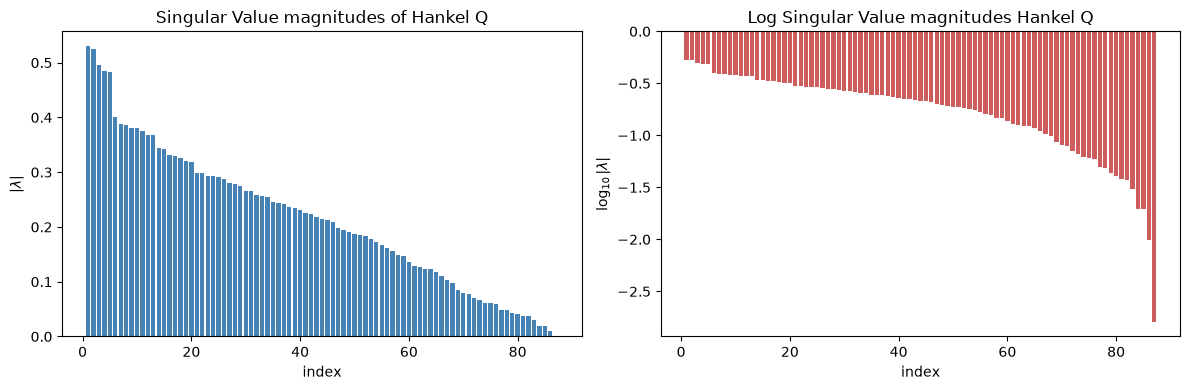

eff_rank: 47, stable_rank: 19.51, spikiness: 1.69, shape: (87, 87), non-zero rows :87, non-zero cols:87
top-r leverage spread: row min=0.009173 max=0.01391 (uniform 0.01149) | col min=0.009173 max=0.01391 (uniform 0.01149)
coherence score: row=1.21 col=1.21
****************************Hankel V****************************


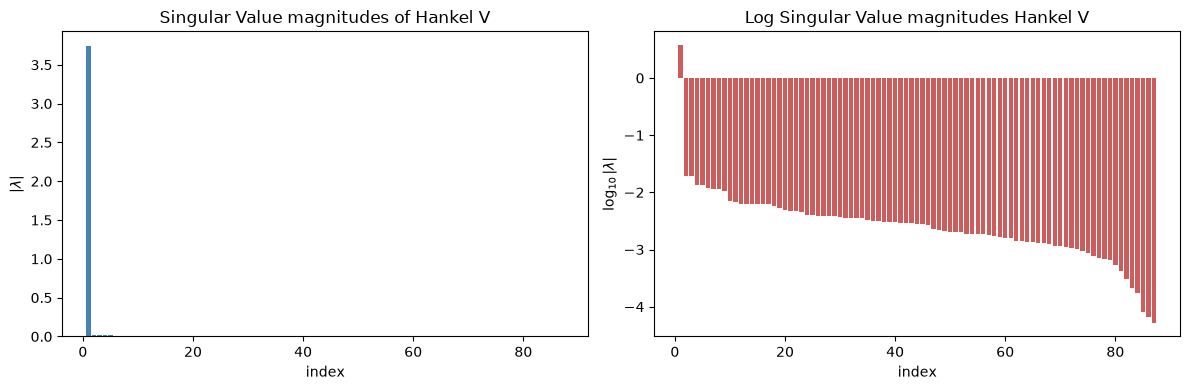

  0%|          | 2/15000 [00:04<7:39:52,  1.84s/it] 

eff_rank: 1, stable_rank: 1.00, spikiness: 1.04, shape: (87, 87), non-zero rows :87, non-zero cols:87
top-r leverage spread: row min=0.01122 max=0.01181 (uniform 0.01149) | col min=0.01122 max=0.01181 (uniform 0.01149)
coherence score: row=1.028 col=1.028


  0%|          | 12/15000 [00:06<51:06,  4.89it/s] 

episode 10 avg_rewarg: 94.0


  0%|          | 22/15000 [00:07<41:52,  5.96it/s]

...

episode 80 avg_rewarg: 117.0


  1%|          | 92/15000 [00:18<41:14,  6.03it/s]

episode 90 avg_rewarg: 109.0


  1%|          | 100/15000 [00:20<39:58,  6.21it/s]

episode 100 avg_rewarg: 122.0
****************************Hankel Q****************************


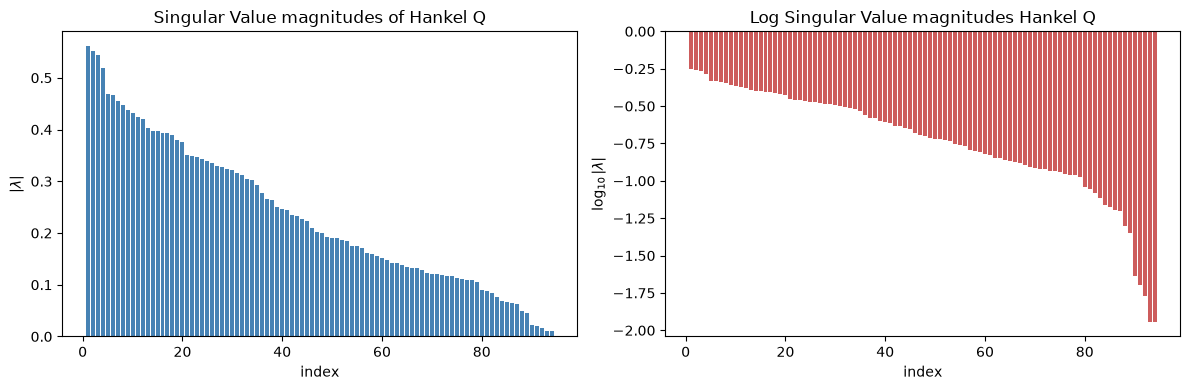

eff_rank: 49, stable_rank: 22.33, spikiness: 1.63, shape: (94, 94), non-zero rows :94, non-zero cols:94
top-r leverage spread: row min=0.008932 max=0.01197 (uniform 0.01064) | col min=0.008932 max=0.01197 (uniform 0.01064)
coherence score: row=1.125 col=1.125
****************************Hankel V****************************


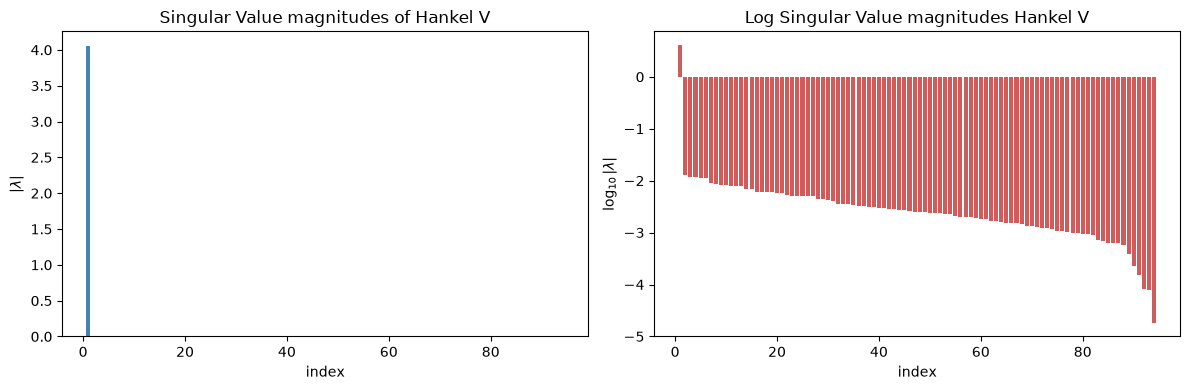

  1%|          | 102/15000 [00:21<1:33:29,  2.66it/s]

eff_rank: 1, stable_rank: 1.00, spikiness: 1.04, shape: (94, 94), non-zero rows :94, non-zero cols:94
top-r leverage spread: row min=0.01037 max=0.01088 (uniform 0.01064) | col min=0.01037 max=0.01088 (uniform 0.01064)
coherence score: row=1.023 col=1.023


  1%|          | 112/15000 [00:22<42:03,  5.90it/s]  

episode 110 avg_rewarg: 130.0


  1%|          | 122/15000 [00:24<39:55,  6.21it/s]

...

episode 180 avg_rewarg: 108.0


  1%|▏         | 192/15000 [00:35<41:00,  6.02it/s]

episode 190 avg_rewarg: 113.0


  1%|▏         | 200/15000 [00:36<38:55,  6.34it/s]

episode 200 avg_rewarg: 107.0
****************************Hankel Q****************************


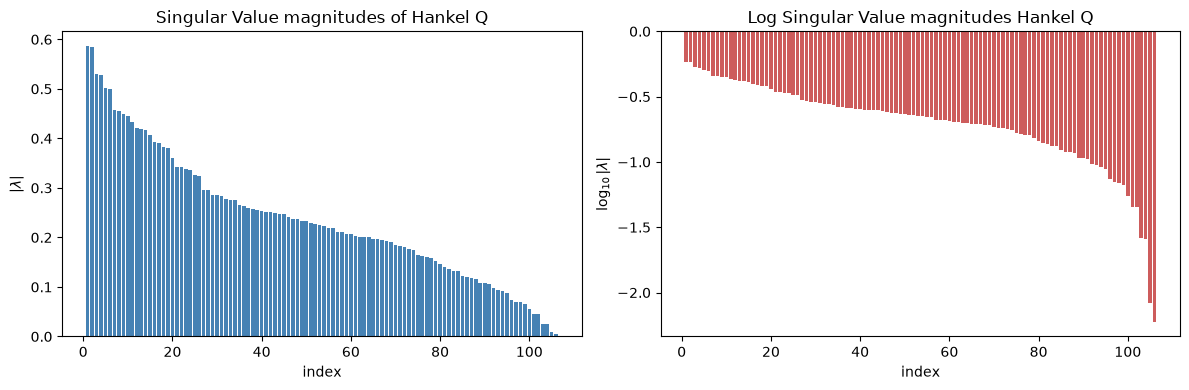

eff_rank: 63, stable_rank: 22.80, spikiness: 1.75, shape: (106, 106), non-zero rows :106, non-zero cols:106
top-r leverage spread: row min=0.00663 max=0.01109 (uniform 0.009434) | col min=0.00663 max=0.01109 (uniform 0.009434)
coherence score: row=1.175 col=1.175
****************************Hankel V****************************


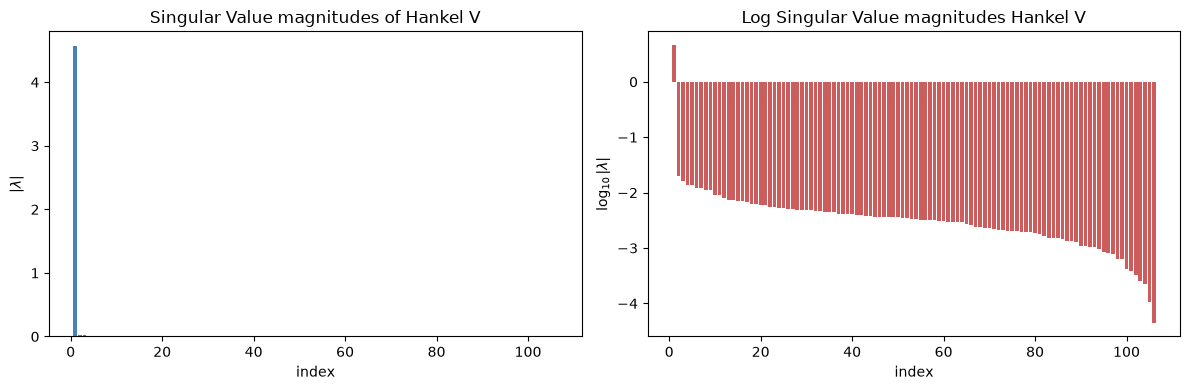

  1%|▏         | 202/15000 [00:38<1:36:05,  2.57it/s]

eff_rank: 1, stable_rank: 1.00, spikiness: 1.03, shape: (106, 106), non-zero rows :106, non-zero cols:106
top-r leverage spread: row min=0.009223 max=0.009645 (uniform 0.009434) | col min=0.009223 max=0.009645 (uniform 0.009434)
coherence score: row=1.022 col=1.022


  1%|▏         | 212/15000 [00:39<43:00,  5.73it/s]  

episode 210 avg_rewarg: 107.0


  1%|▏         | 222/15000 [00:41<38:06,  6.46it/s]

...

episode 280 avg_rewarg: 111.0


  2%|▏         | 291/15000 [00:53<1:04:17,  3.81it/s]

episode 290 avg_rewarg: 104.0


  2%|▏         | 300/15000 [00:56<1:14:13,  3.30it/s]

episode 300 avg_rewarg: 111.0
****************************Hankel Q****************************


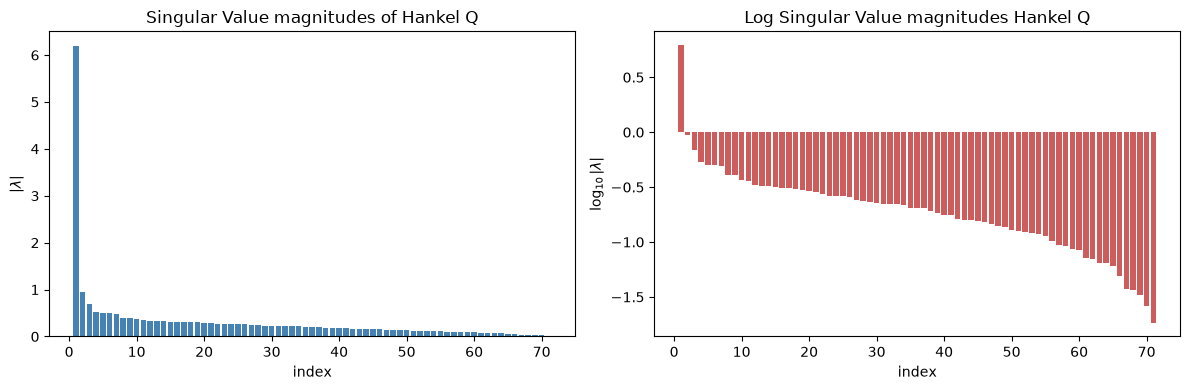

eff_rank: 3, stable_rank: 1.14, spikiness: 1.89, shape: (71, 71), non-zero rows :71, non-zero cols:71
top-r leverage spread: row min=0.002483 max=0.02616 (uniform 0.01408) | col min=0.002483 max=0.02616 (uniform 0.01408)
coherence score: row=1.857 col=1.857
****************************Hankel V****************************


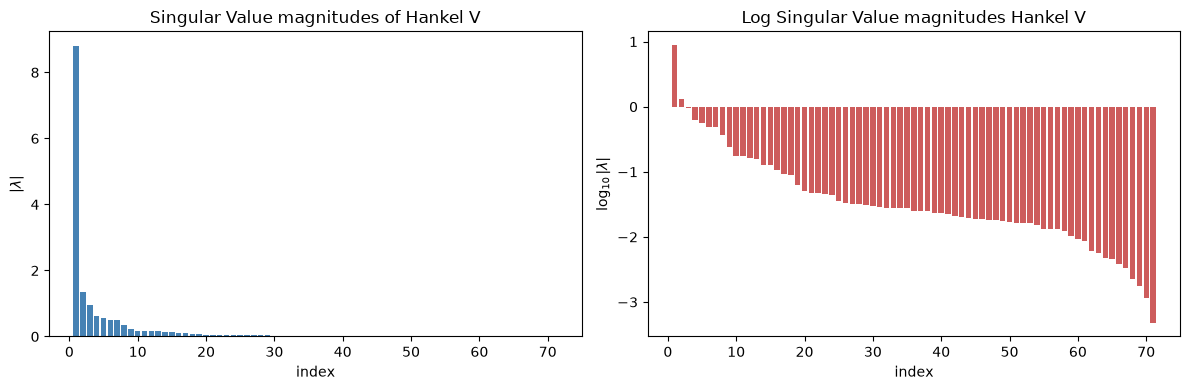

  2%|▏         | 301/15000 [00:57<2:18:04,  1.77it/s]

eff_rank: 1, stable_rank: 1.06, spikiness: 1.38, shape: (71, 71), non-zero rows :71, non-zero cols:71
top-r leverage spread: row min=0.004827 max=0.02193 (uniform 0.01408) | col min=0.004827 max=0.02193 (uniform 0.01408)
coherence score: row=1.557 col=1.557


  2%|▏         | 311/15000 [01:00<1:16:00,  3.22it/s]

episode 310 avg_rewarg: 118.0


  2%|▏         | 322/15000 [01:04<1:05:08,  3.76it/s]

...

episode 380 avg_rewarg: 112.0


  3%|▎         | 391/15000 [01:25<1:19:27,  3.06it/s]

episode 390 avg_rewarg: 122.0


  3%|▎         | 400/15000 [01:28<1:00:41,  4.01it/s]

episode 400 avg_rewarg: 143.0
****************************Hankel Q****************************


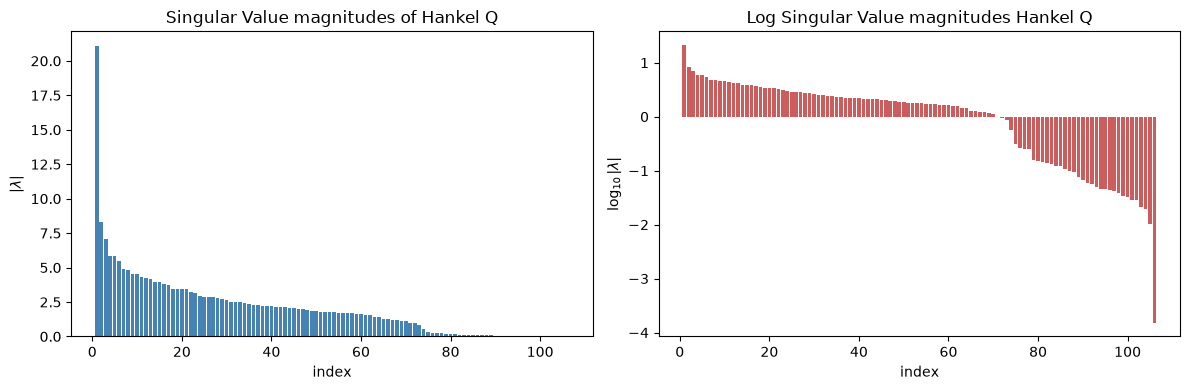

eff_rank: 36, stable_rank: 2.55, spikiness: 5.65, shape: (106, 106), non-zero rows :106, non-zero cols:106
top-r leverage spread: row min=0.0001379 max=0.01706 (uniform 0.009434) | col min=0.0001379 max=0.01706 (uniform 0.009434)
coherence score: row=1.809 col=1.809
****************************Hankel V****************************


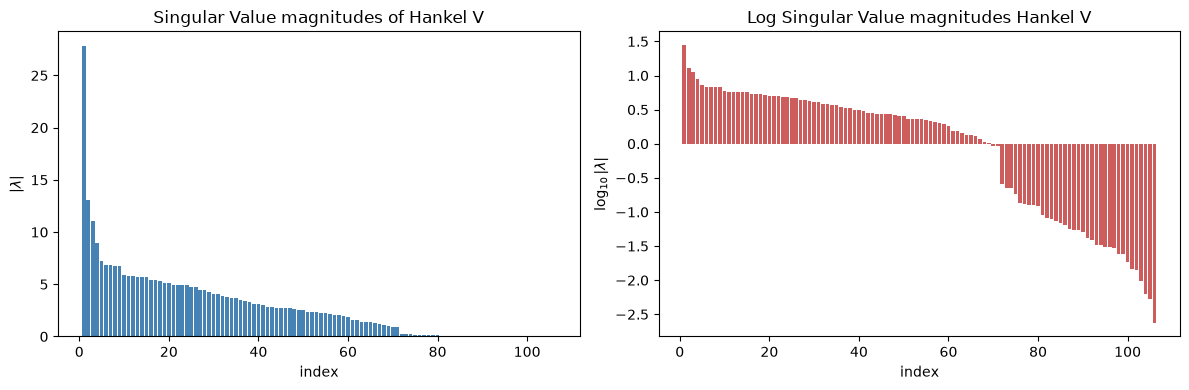

  3%|▎         | 401/15000 [01:29<2:51:00,  1.42it/s]

eff_rank: 33, stable_rank: 2.85, spikiness: 5.62, shape: (106, 106), non-zero rows :106, non-zero cols:106
top-r leverage spread: row min=9.762e-05 max=0.01662 (uniform 0.009434) | col min=9.762e-05 max=0.01662 (uniform 0.009434)
coherence score: row=1.761 col=1.761


  3%|▎         | 411/15000 [01:32<1:13:55,  3.29it/s]

episode 410 avg_rewarg: 104.0


  3%|▎         | 422/15000 [01:36<1:06:54,  3.63it/s]

...

episode 480 avg_rewarg: 159.0


  3%|▎         | 491/15000 [01:58<1:11:46,  3.37it/s]

episode 490 avg_rewarg: 106.0


  3%|▎         | 500/15000 [02:01<1:19:04,  3.06it/s]

episode 500 avg_rewarg: 142.0
****************************Hankel Q****************************


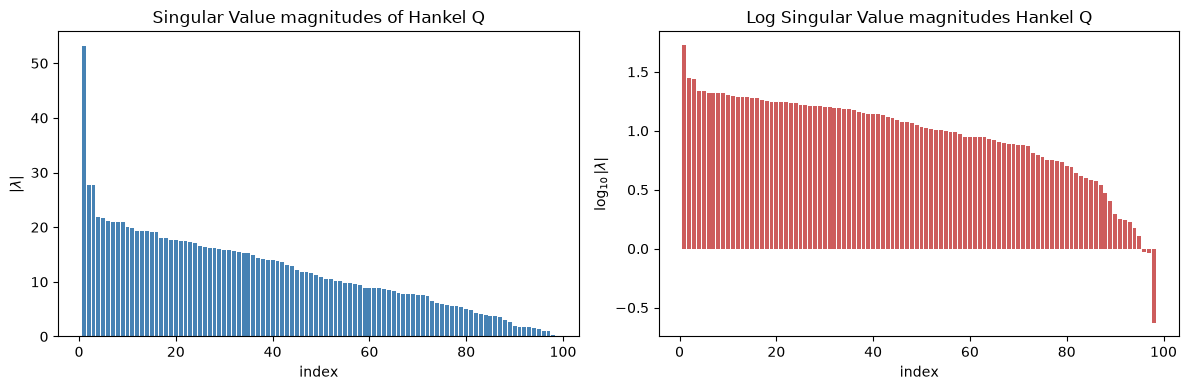

eff_rank: 52, stable_rank: 6.96, spikiness: 5.47, shape: (98, 98), non-zero rows :98, non-zero cols:98
top-r leverage spread: row min=0.004441 max=0.01377 (uniform 0.0102) | col min=0.004441 max=0.01377 (uniform 0.0102)
coherence score: row=1.349 col=1.349
****************************Hankel V****************************


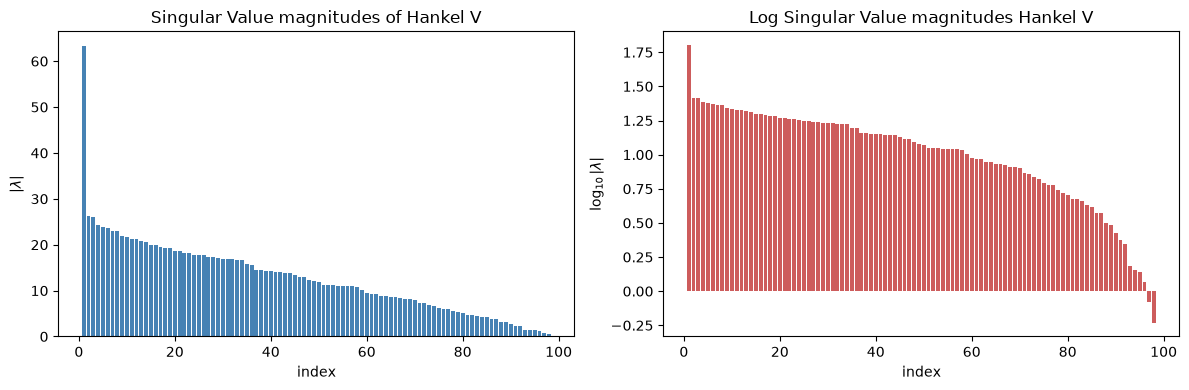

  3%|▎         | 502/15000 [02:02<1:57:53,  2.05it/s]

eff_rank: 52, stable_rank: 5.72, spikiness: 5.07, shape: (98, 98), non-zero rows :98, non-zero cols:98
top-r leverage spread: row min=0.004484 max=0.01427 (uniform 0.0102) | col min=0.004484 max=0.01427 (uniform 0.0102)
coherence score: row=1.399 col=1.399


  3%|▎         | 511/15000 [02:06<1:28:06,  2.74it/s]

episode 510 avg_rewarg: 130.0


  3%|▎         | 521/15000 [02:09<1:30:54,  2.65it/s]

...

episode 580 avg_rewarg: 134.0


  4%|▍         | 591/15000 [02:33<1:17:33,  3.10it/s]

episode 590 avg_rewarg: 125.0


  4%|▍         | 600/15000 [02:36<1:20:26,  2.98it/s]

episode 600 avg_rewarg: 117.0
****************************Hankel Q****************************


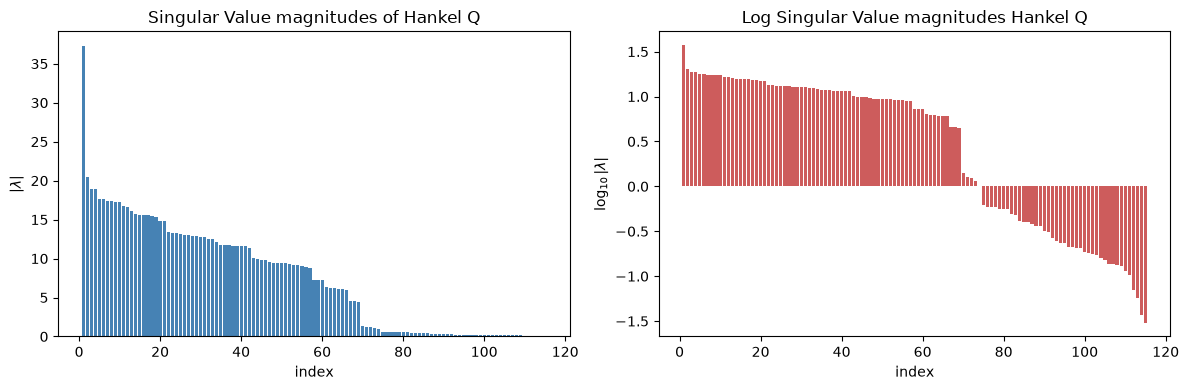

eff_rank: 49, stable_rank: 8.69, spikiness: 11.06, shape: (115, 115), non-zero rows :115, non-zero cols:115
top-r leverage spread: row min=9.123e-05 max=0.01566 (uniform 0.008696) | col min=9.123e-05 max=0.01566 (uniform 0.008696)
coherence score: row=1.801 col=1.801
****************************Hankel V****************************


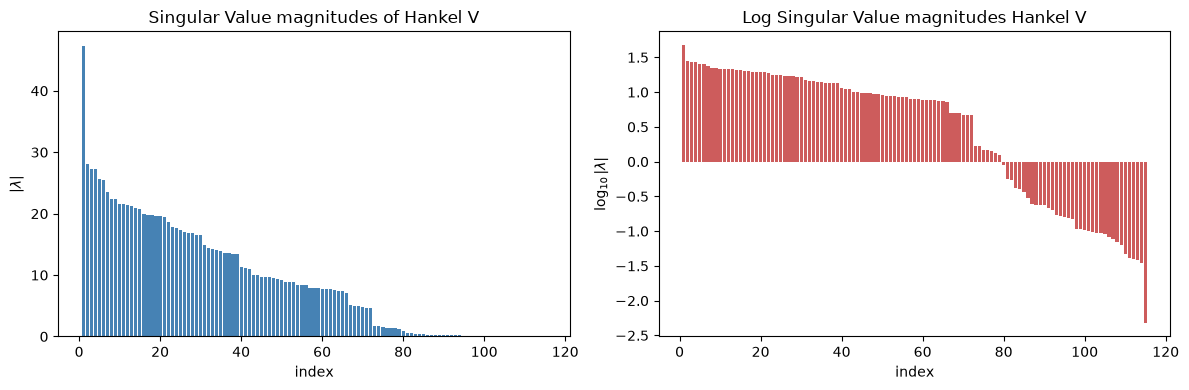

  4%|▍         | 601/15000 [02:37<3:18:02,  1.21it/s]

eff_rank: 43, stable_rank: 8.56, spikiness: 8.79, shape: (115, 115), non-zero rows :115, non-zero cols:115
top-r leverage spread: row min=8.146e-05 max=0.01913 (uniform 0.008696) | col min=8.146e-05 max=0.01913 (uniform 0.008696)
coherence score: row=2.199 col=2.199


  4%|▍         | 611/15000 [02:41<1:25:51,  2.79it/s]

episode 610 avg_rewarg: 176.0


  4%|▍         | 621/15000 [02:44<1:21:31,  2.94it/s]

...

episode 680 avg_rewarg: 219.0


  5%|▍         | 691/15000 [03:12<1:21:17,  2.93it/s]

episode 690 avg_rewarg: 284.0


  5%|▍         | 700/15000 [03:16<1:53:04,  2.11it/s]

episode 700 avg_rewarg: 183.0
****************************Hankel Q****************************


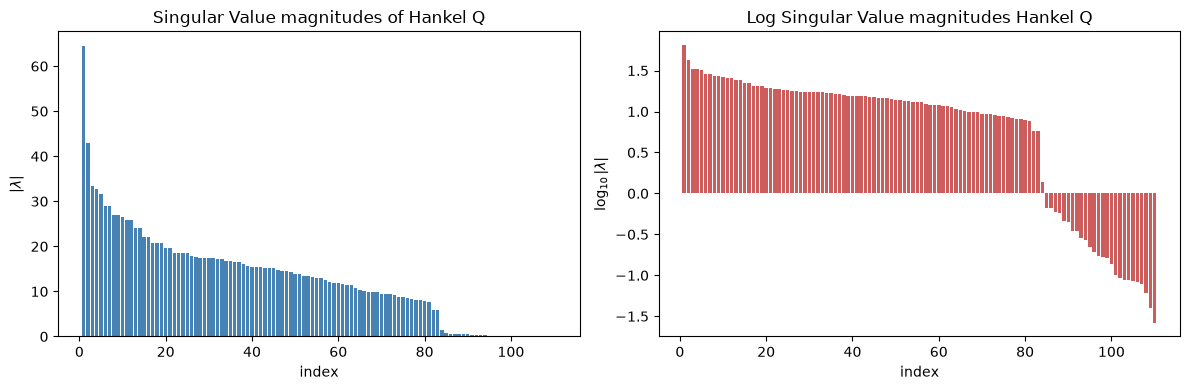

eff_rank: 54, stable_rank: 7.23, spikiness: 9.38, shape: (110, 110), non-zero rows :110, non-zero cols:110
top-r leverage spread: row min=0.0002593 max=0.01396 (uniform 0.009091) | col min=0.0002593 max=0.01396 (uniform 0.009091)
coherence score: row=1.535 col=1.535
****************************Hankel V****************************


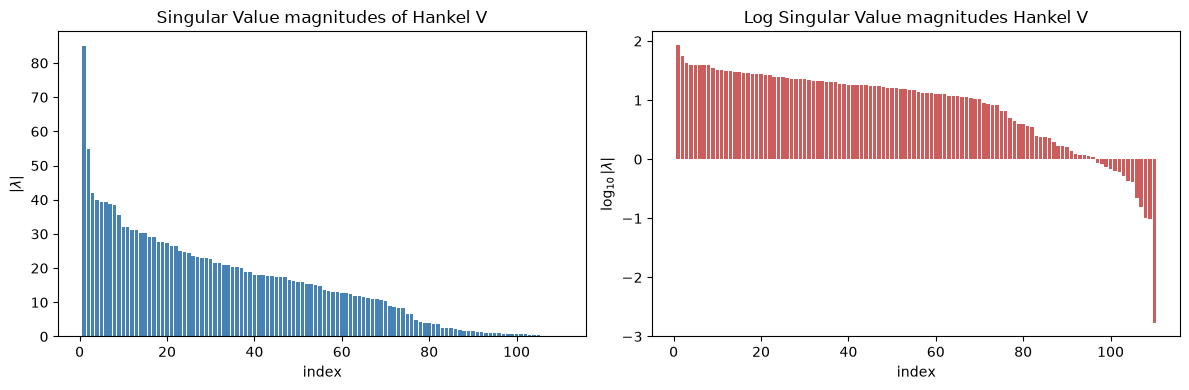

  5%|▍         | 701/15000 [03:17<3:06:15,  1.28it/s]

eff_rank: 47, stable_rank: 6.58, spikiness: 7.46, shape: (110, 110), non-zero rows :110, non-zero cols:110
top-r leverage spread: row min=0.000608 max=0.015 (uniform 0.009091) | col min=0.000608 max=0.015 (uniform 0.009091)
coherence score: row=1.65 col=1.65


  5%|▍         | 711/15000 [03:21<1:20:39,  2.95it/s]

episode 710 avg_rewarg: 121.0


  5%|▍         | 721/15000 [03:25<1:28:27,  2.69it/s]

...

episode 780 avg_rewarg: 285.0


  5%|▌         | 791/15000 [03:53<1:46:30,  2.22it/s]

episode 790 avg_rewarg: 287.0


  5%|▌         | 800/15000 [03:57<1:48:18,  2.19it/s]

episode 800 avg_rewarg: 179.0
****************************Hankel Q****************************


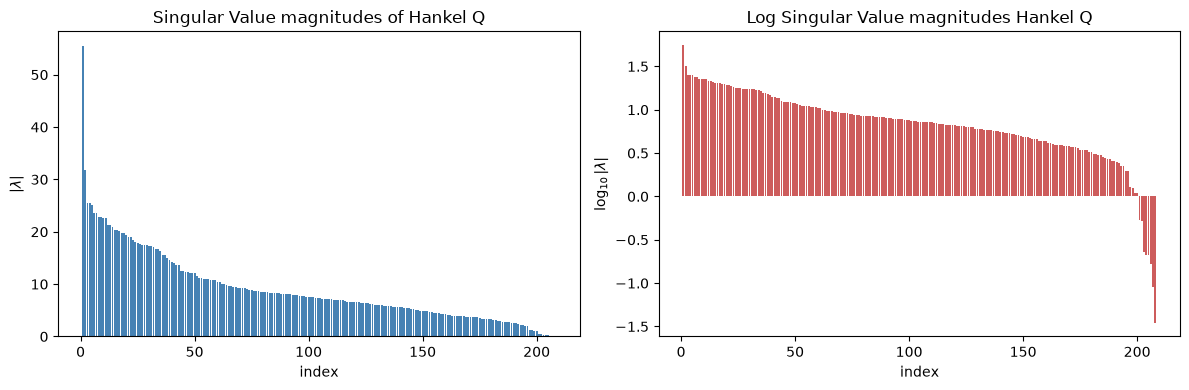

eff_rank: 99, stable_rank: 8.82, spikiness: 13.91, shape: (208, 208), non-zero rows :208, non-zero cols:208
top-r leverage spread: row min=0.00148 max=0.008147 (uniform 0.004808) | col min=0.00148 max=0.008147 (uniform 0.004808)
coherence score: row=1.695 col=1.695
****************************Hankel V****************************


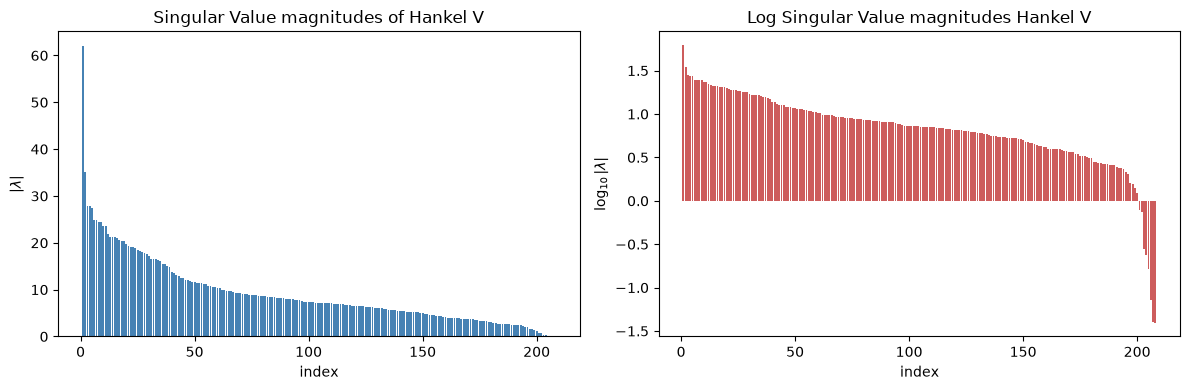

  5%|▌         | 801/15000 [03:59<3:49:12,  1.03it/s]

eff_rank: 94, stable_rank: 7.53, spikiness: 13.47, shape: (208, 208), non-zero rows :208, non-zero cols:208
top-r leverage spread: row min=0.001626 max=0.008316 (uniform 0.004808) | col min=0.001626 max=0.008316 (uniform 0.004808)
coherence score: row=1.73 col=1.73


  5%|▌         | 811/15000 [04:02<1:29:08,  2.65it/s]

episode 810 avg_rewarg: 137.0


  5%|▌         | 821/15000 [04:07<1:52:40,  2.10it/s]

...

episode 880 avg_rewarg: 189.0


  6%|▌         | 891/15000 [04:35<1:35:10,  2.47it/s]

episode 890 avg_rewarg: 186.0


  6%|▌         | 900/15000 [04:38<1:47:19,  2.19it/s]

episode 900 avg_rewarg: 216.0
****************************Hankel Q****************************


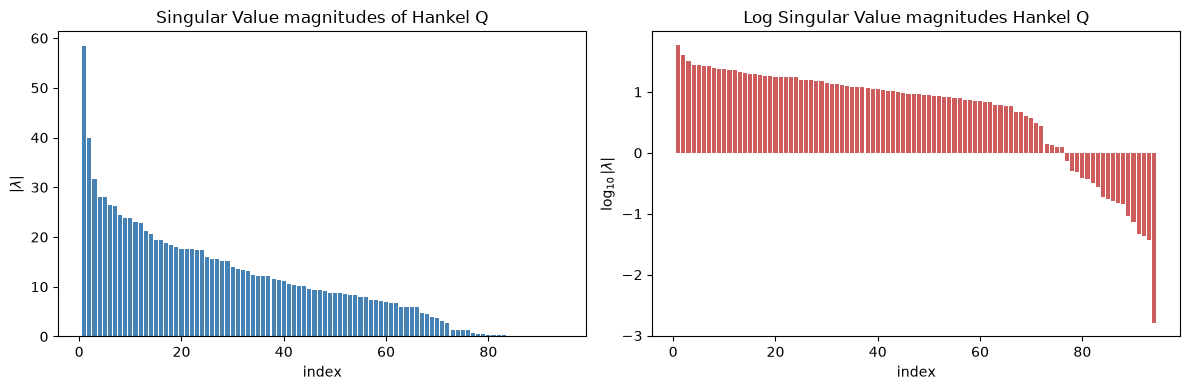

eff_rank: 39, stable_rank: 6.07, spikiness: 5.89, shape: (94, 94), non-zero rows :94, non-zero cols:94
top-r leverage spread: row min=8.628e-05 max=0.01729 (uniform 0.01064) | col min=8.628e-05 max=0.01729 (uniform 0.01064)
coherence score: row=1.625 col=1.625
****************************Hankel V****************************


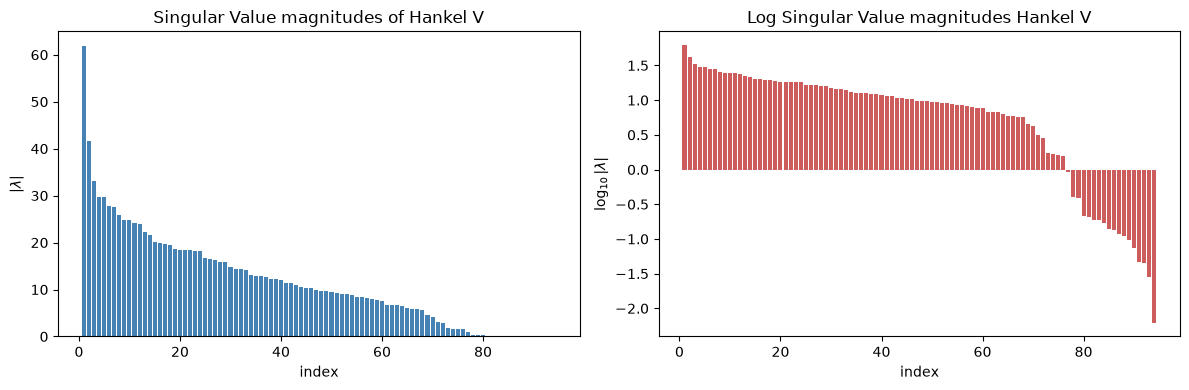

  6%|▌         | 901/15000 [04:40<3:14:54,  1.21it/s]

eff_rank: 40, stable_rank: 6.01, spikiness: 6.25, shape: (94, 94), non-zero rows :94, non-zero cols:94
top-r leverage spread: row min=8.819e-05 max=0.017 (uniform 0.01064) | col min=8.819e-05 max=0.017 (uniform 0.01064)
coherence score: row=1.598 col=1.598


  6%|▌         | 911/15000 [04:45<1:57:20,  2.00it/s]

episode 910 avg_rewarg: 314.0


  6%|▌         | 921/15000 [04:50<1:53:23,  2.07it/s]

...

episode 980 avg_rewarg: 177.0


  7%|▋         | 991/15000 [05:22<1:38:56,  2.36it/s]

episode 990 avg_rewarg: 173.0


  7%|▋         | 1000/15000 [05:26<1:35:55,  2.43it/s]

episode 1000 avg_rewarg: 293.0
****************************Hankel Q****************************


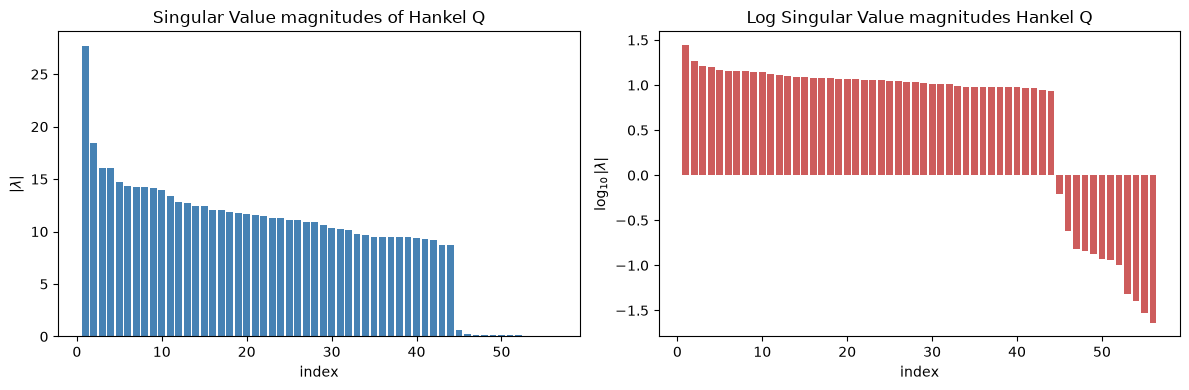

eff_rank: 36, stable_rank: 8.92, spikiness: 7.96, shape: (56, 56), non-zero rows :56, non-zero cols:56
top-r leverage spread: row min=1.377e-05 max=0.02687 (uniform 0.01786) | col min=1.377e-05 max=0.02687 (uniform 0.01786)
coherence score: row=1.505 col=1.505
****************************Hankel V****************************


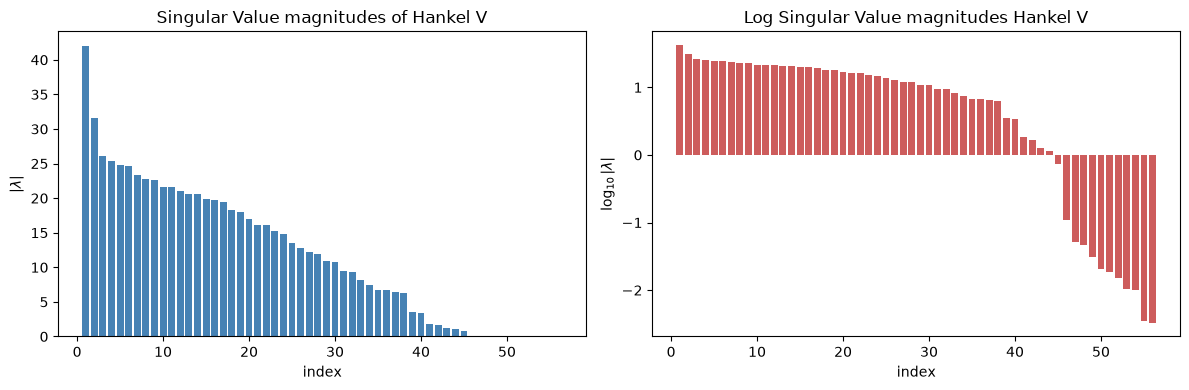

  7%|▋         | 1001/15000 [05:27<2:34:26,  1.51it/s]

eff_rank: 25, stable_rank: 7.69, spikiness: 6.30, shape: (56, 56), non-zero rows :56, non-zero cols:56
top-r leverage spread: row min=5.817e-06 max=0.03039 (uniform 0.01786) | col min=5.817e-06 max=0.03039 (uniform 0.01786)
coherence score: row=1.702 col=1.702


  7%|▋         | 1011/15000 [05:32<1:51:39,  2.09it/s]

episode 1010 avg_rewarg: 236.0


  7%|▋         | 1021/15000 [05:37<1:39:39,  2.34it/s]

...

episode 1080 avg_rewarg: 265.0


  7%|▋         | 1091/15000 [06:10<1:15:08,  3.08it/s]

episode 1090 avg_rewarg: 174.0


  7%|▋         | 1100/15000 [06:14<1:31:32,  2.53it/s]

episode 1100 avg_rewarg: 177.0
****************************Hankel Q****************************


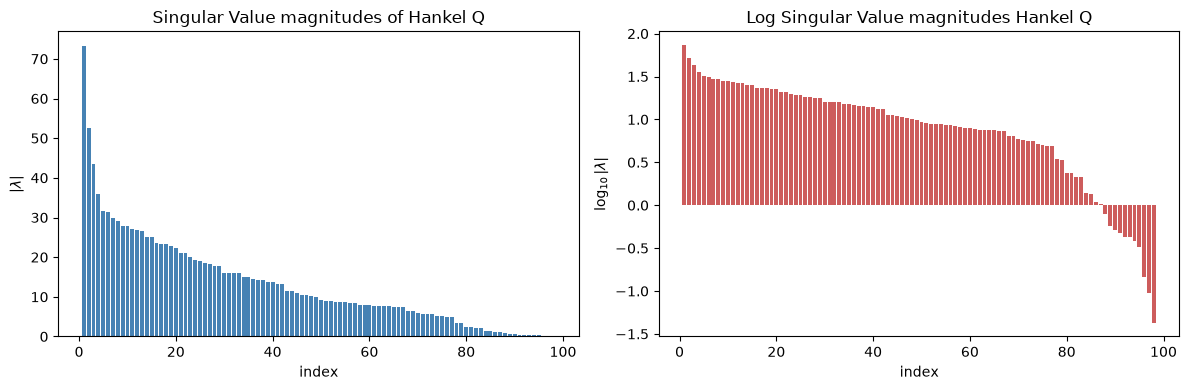

eff_rank: 38, stable_rank: 5.81, spikiness: 5.31, shape: (98, 98), non-zero rows :98, non-zero cols:98
top-r leverage spread: row min=0.0002135 max=0.0166 (uniform 0.0102) | col min=0.0002135 max=0.0166 (uniform 0.0102)
coherence score: row=1.627 col=1.627
****************************Hankel V****************************


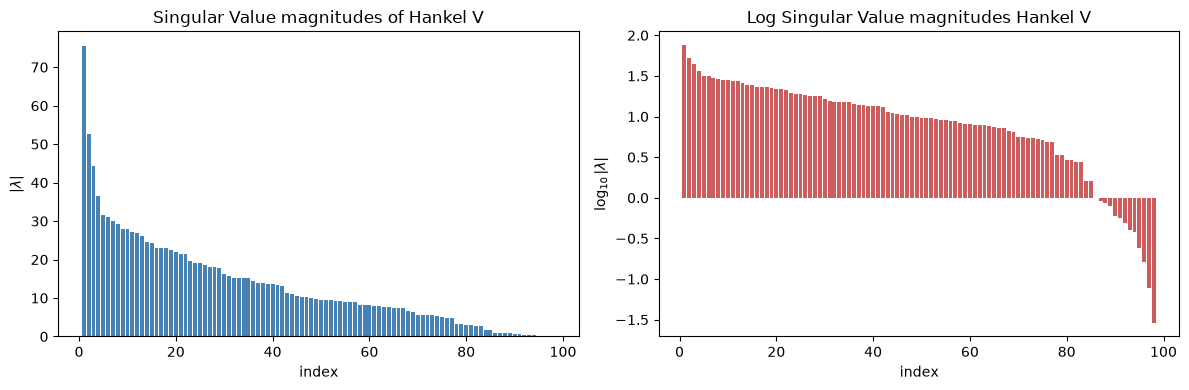

  7%|▋         | 1101/15000 [06:15<2:50:27,  1.36it/s]

eff_rank: 39, stable_rank: 5.53, spikiness: 5.28, shape: (98, 98), non-zero rows :98, non-zero cols:98
top-r leverage spread: row min=0.000293 max=0.0162 (uniform 0.0102) | col min=0.000293 max=0.0162 (uniform 0.0102)
coherence score: row=1.587 col=1.587


  7%|▋         | 1111/15000 [06:20<1:42:21,  2.26it/s]

episode 1110 avg_rewarg: 194.0


  7%|▋         | 1121/15000 [06:25<1:59:22,  1.94it/s]

...

episode 1180 avg_rewarg: 312.0


  8%|▊         | 1191/15000 [07:01<1:48:38,  2.12it/s]

episode 1190 avg_rewarg: 163.0


  8%|▊         | 1200/15000 [07:05<1:45:16,  2.18it/s]

episode 1200 avg_rewarg: 201.0
****************************Hankel Q****************************


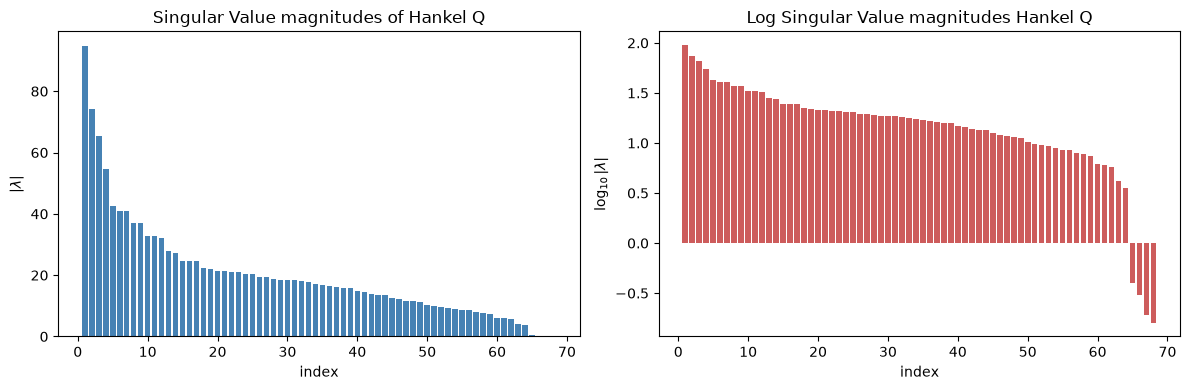

eff_rank: 32, stable_rank: 5.21, spikiness: 3.40, shape: (68, 68), non-zero rows :68, non-zero cols:68
top-r leverage spread: row min=0.006442 max=0.01957 (uniform 0.01471) | col min=0.006442 max=0.01957 (uniform 0.01471)
coherence score: row=1.331 col=1.331
****************************Hankel V****************************


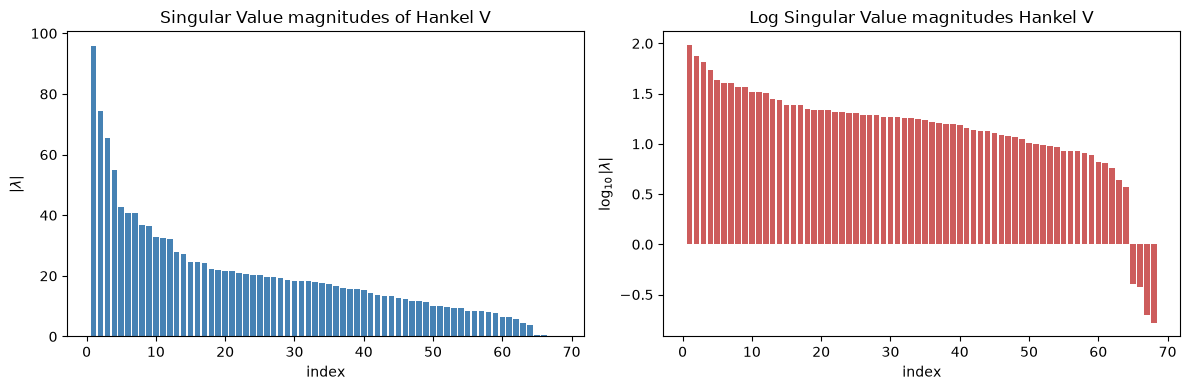

  8%|▊         | 1201/15000 [07:06<2:49:37,  1.36it/s]

eff_rank: 32, stable_rank: 5.12, spikiness: 3.39, shape: (68, 68), non-zero rows :68, non-zero cols:68
top-r leverage spread: row min=0.005567 max=0.01944 (uniform 0.01471) | col min=0.005567 max=0.01944 (uniform 0.01471)
coherence score: row=1.322 col=1.322


  8%|▊         | 1212/15000 [07:12<1:51:17,  2.06it/s]

episode 1210 avg_rewarg: 242.0


  8%|▊         | 1221/15000 [07:18<2:12:23,  1.73it/s]

...

episode 1280 avg_rewarg: 232.0


  9%|▊         | 1291/15000 [07:54<2:53:35,  1.32it/s]

episode 1290 avg_rewarg: 396.0


  9%|▊         | 1300/15000 [07:59<2:02:54,  1.86it/s]

episode 1300 avg_rewarg: 210.0
****************************Hankel Q****************************


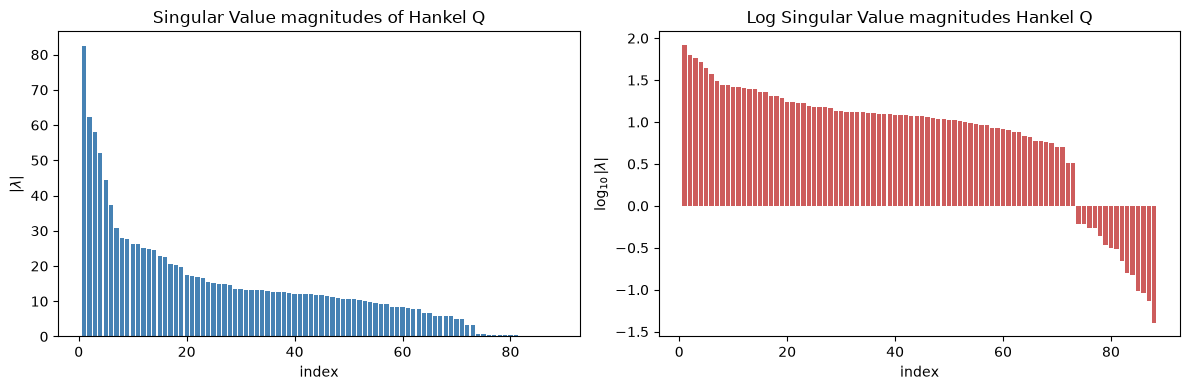

eff_rank: 35, stable_rank: 5.16, spikiness: 5.06, shape: (88, 88), non-zero rows :88, non-zero cols:88
top-r leverage spread: row min=8.193e-05 max=0.0198 (uniform 0.01136) | col min=8.193e-05 max=0.0198 (uniform 0.01136)
coherence score: row=1.742 col=1.742
****************************Hankel V****************************


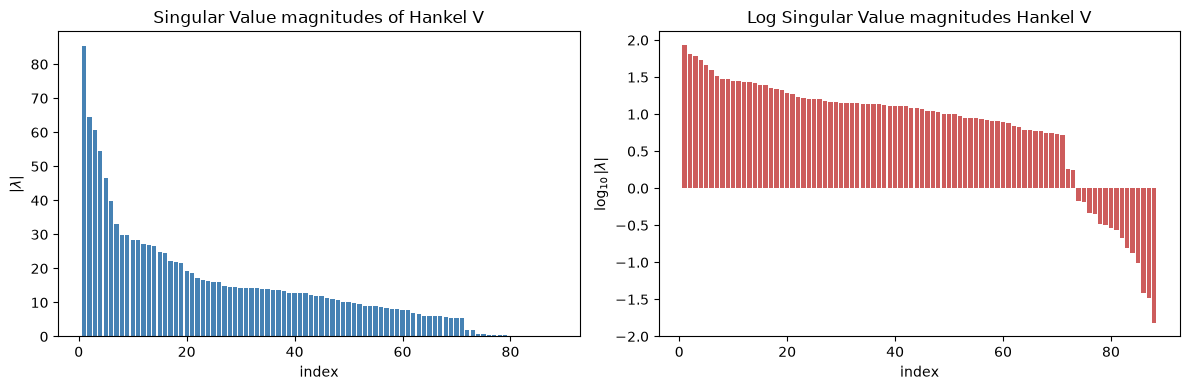

  9%|▊         | 1301/15000 [08:00<3:08:33,  1.21it/s]

eff_rank: 33, stable_rank: 5.28, spikiness: 4.84, shape: (88, 88), non-zero rows :88, non-zero cols:88
top-r leverage spread: row min=6.743e-05 max=0.01888 (uniform 0.01136) | col min=6.743e-05 max=0.01888 (uniform 0.01136)
coherence score: row=1.661 col=1.661


  9%|▊         | 1311/15000 [08:06<1:59:58,  1.90it/s]

episode 1310 avg_rewarg: 209.0


  9%|▉         | 1321/15000 [08:10<1:24:04,  2.71it/s]

...

episode 1380 avg_rewarg: 173.0


  9%|▉         | 1391/15000 [08:50<2:53:06,  1.31it/s]

episode 1390 avg_rewarg: 445.0


  9%|▉         | 1400/15000 [08:54<1:31:13,  2.48it/s]

episode 1400 avg_rewarg: 251.0
****************************Hankel Q****************************


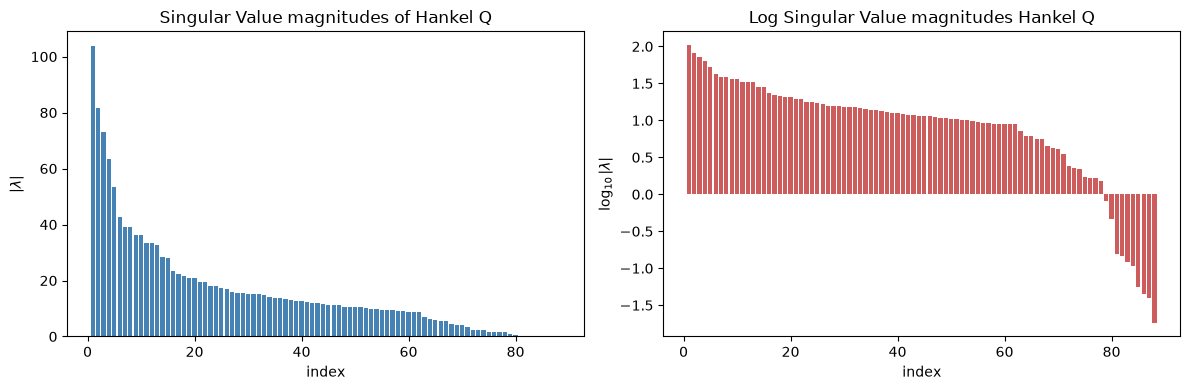

eff_rank: 28, stable_rank: 4.82, spikiness: 4.09, shape: (88, 88), non-zero rows :88, non-zero cols:88
top-r leverage spread: row min=6.79e-05 max=0.01983 (uniform 0.01136) | col min=6.79e-05 max=0.01983 (uniform 0.01136)
coherence score: row=1.745 col=1.745
****************************Hankel V****************************


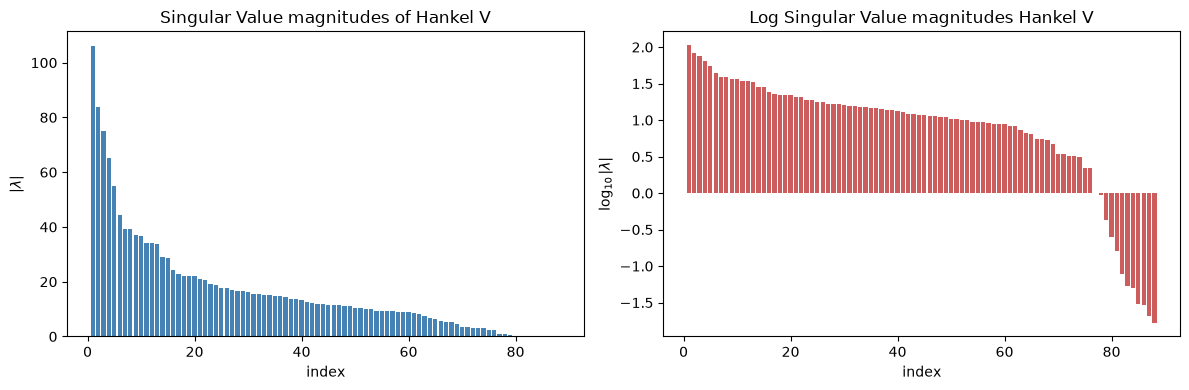

  9%|▉         | 1401/15000 [08:56<3:49:01,  1.01s/it]

eff_rank: 28, stable_rank: 4.86, spikiness: 3.98, shape: (88, 88), non-zero rows :88, non-zero cols:88
top-r leverage spread: row min=6.209e-05 max=0.01973 (uniform 0.01136) | col min=6.209e-05 max=0.01973 (uniform 0.01136)
coherence score: row=1.736 col=1.736


  9%|▉         | 1411/15000 [09:02<2:27:24,  1.54it/s]

episode 1410 avg_rewarg: 434.0


  9%|▉         | 1421/15000 [09:09<2:14:51,  1.68it/s]

...

episode 1480 avg_rewarg: 247.0


 10%|▉         | 1491/15000 [09:48<1:39:26,  2.26it/s]

episode 1490 avg_rewarg: 237.0


 10%|█         | 1500/15000 [09:53<1:43:06,  2.18it/s]

episode 1500 avg_rewarg: 322.0
****************************Hankel Q****************************


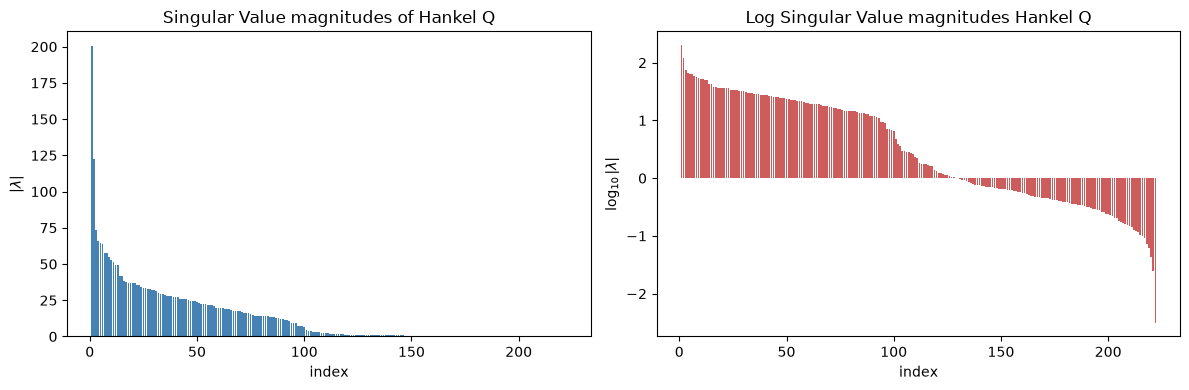

eff_rank: 49, stable_rank: 3.56, spikiness: 7.78, shape: (222, 222), non-zero rows :222, non-zero cols:222
top-r leverage spread: row min=0.0001099 max=0.01203 (uniform 0.004505) | col min=0.0001099 max=0.01203 (uniform 0.004505)
coherence score: row=2.671 col=2.671
****************************Hankel V****************************


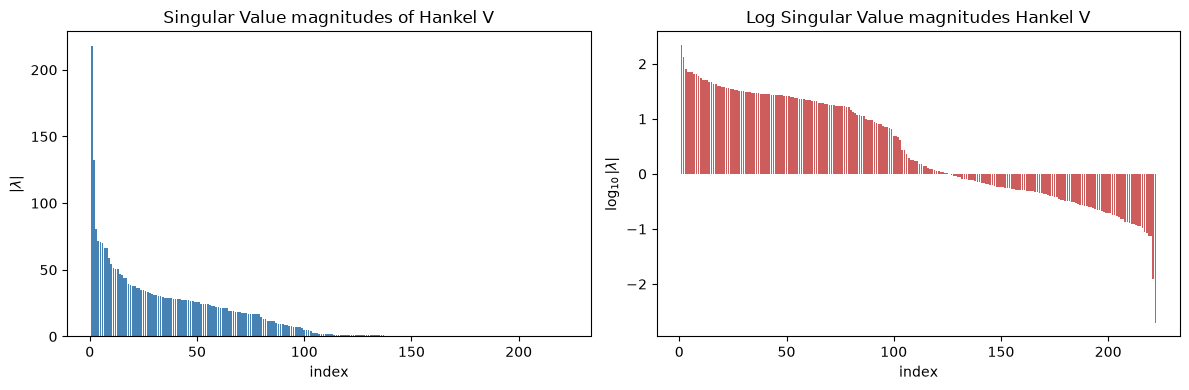

 10%|█         | 1501/15000 [09:56<3:48:27,  1.02s/it]

eff_rank: 47, stable_rank: 3.46, spikiness: 7.26, shape: (222, 222), non-zero rows :222, non-zero cols:222
top-r leverage spread: row min=0.0001225 max=0.01265 (uniform 0.004505) | col min=0.0001225 max=0.01265 (uniform 0.004505)
coherence score: row=2.807 col=2.807


 10%|█         | 1511/15000 [10:01<1:59:14,  1.89it/s]

episode 1510 avg_rewarg: 226.0


 10%|█         | 1521/15000 [10:07<2:04:48,  1.80it/s]

...

episode 1580 avg_rewarg: 261.0


 11%|█         | 1591/15000 [10:49<2:35:03,  1.44it/s]

episode 1590 avg_rewarg: 371.0


 11%|█         | 1600/15000 [10:54<2:11:55,  1.69it/s]

episode 1600 avg_rewarg: 241.0
****************************Hankel Q****************************


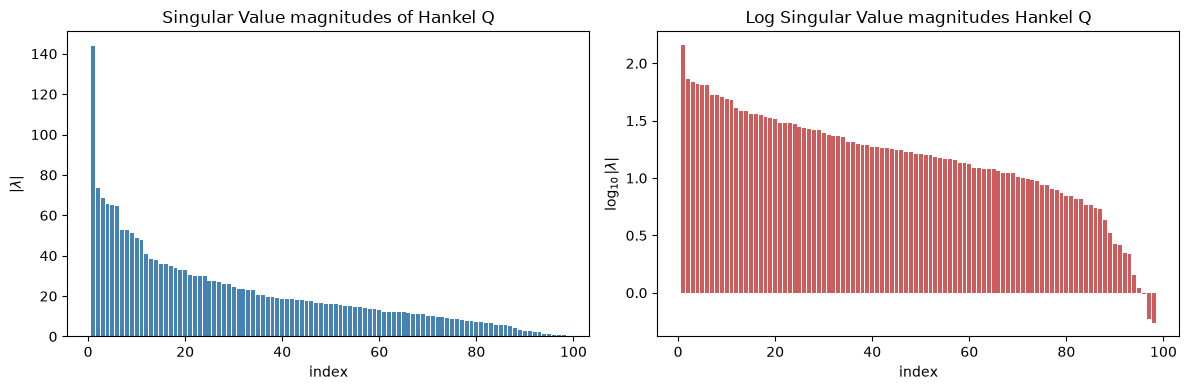

eff_rank: 37, stable_rank: 4.25, spikiness: 3.75, shape: (98, 98), non-zero rows :98, non-zero cols:98
top-r leverage spread: row min=0.00415 max=0.01335 (uniform 0.0102) | col min=0.00415 max=0.01335 (uniform 0.0102)
coherence score: row=1.308 col=1.308
****************************Hankel V****************************


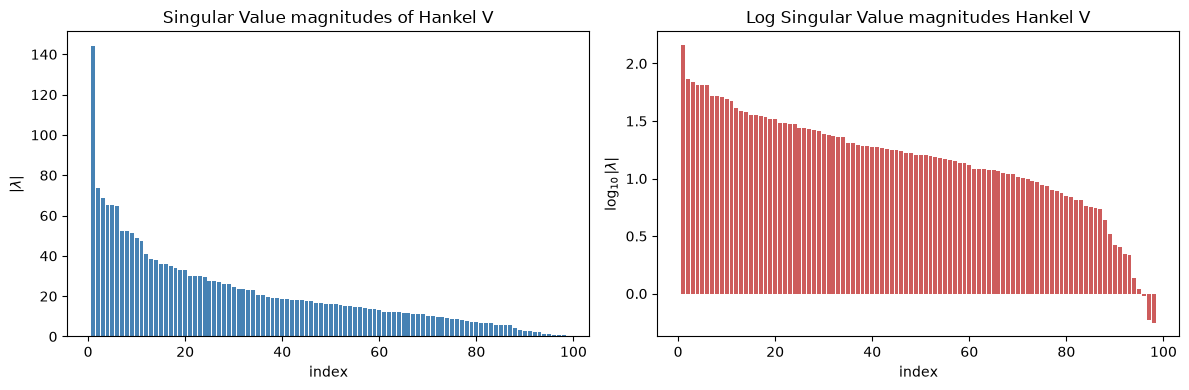

 11%|█         | 1601/15000 [10:56<3:27:10,  1.08it/s]

eff_rank: 37, stable_rank: 4.24, spikiness: 3.75, shape: (98, 98), non-zero rows :98, non-zero cols:98
top-r leverage spread: row min=0.004148 max=0.01338 (uniform 0.0102) | col min=0.004148 max=0.01338 (uniform 0.0102)
coherence score: row=1.311 col=1.311


 11%|█         | 1611/15000 [11:03<2:19:54,  1.60it/s]

episode 1610 avg_rewarg: 423.0


 11%|█         | 1621/15000 [11:09<1:58:32,  1.88it/s]

...

episode 1680 avg_rewarg: 437.0


 11%|█▏        | 1691/15000 [11:53<2:51:15,  1.30it/s]

episode 1690 avg_rewarg: 377.0


 11%|█▏        | 1700/15000 [11:59<2:30:18,  1.47it/s]

episode 1700 avg_rewarg: 263.0
****************************Hankel Q****************************


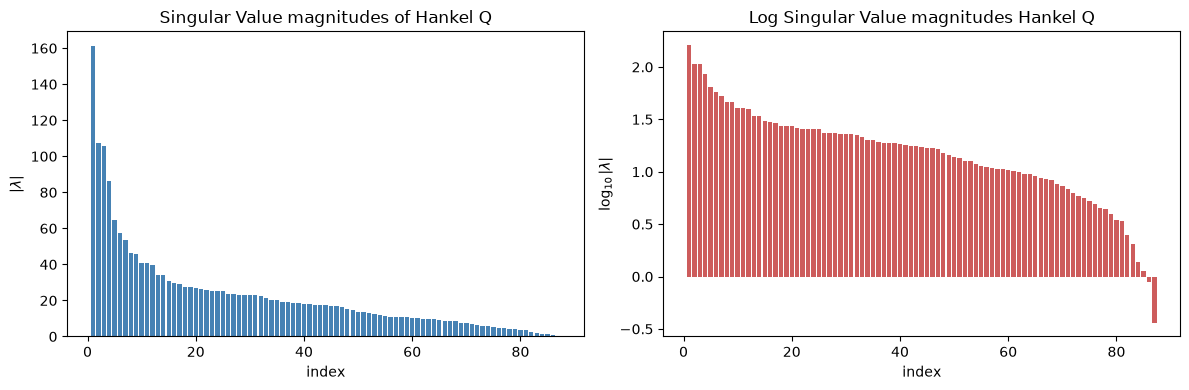

eff_rank: 29, stable_rank: 3.77, spikiness: 3.43, shape: (87, 87), non-zero rows :87, non-zero cols:87
top-r leverage spread: row min=0.004568 max=0.01705 (uniform 0.01149) | col min=0.004568 max=0.01705 (uniform 0.01149)
coherence score: row=1.483 col=1.483
****************************Hankel V****************************


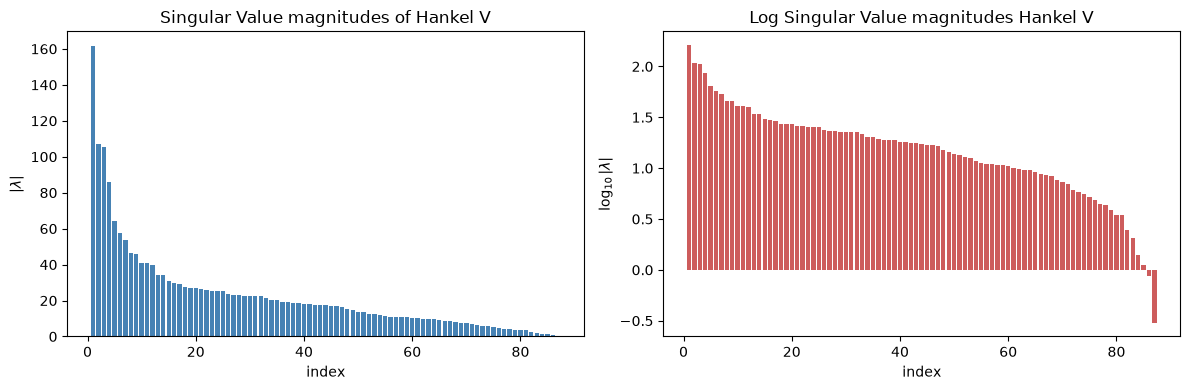

 11%|█▏        | 1701/15000 [12:01<4:41:24,  1.27s/it]

eff_rank: 29, stable_rank: 3.75, spikiness: 3.43, shape: (87, 87), non-zero rows :87, non-zero cols:87
top-r leverage spread: row min=0.00469 max=0.01704 (uniform 0.01149) | col min=0.00469 max=0.01704 (uniform 0.01149)
coherence score: row=1.482 col=1.482


 11%|█▏        | 1711/15000 [12:08<2:46:48,  1.33it/s]

episode 1710 avg_rewarg: 284.0


 11%|█▏        | 1721/15000 [12:14<2:16:13,  1.62it/s]

...

episode 1780 avg_rewarg: 318.0


 12%|█▏        | 1791/15000 [13:08<2:55:40,  1.25it/s]

episode 1790 avg_rewarg: 576.0


 12%|█▏        | 1800/15000 [13:16<2:59:43,  1.22it/s]

episode 1800 avg_rewarg: 779.0
****************************Hankel Q****************************


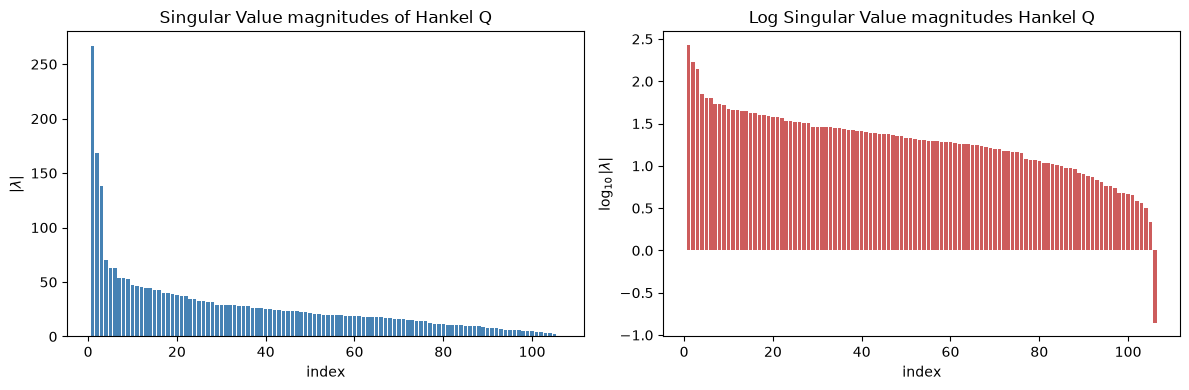

eff_rank: 35, stable_rank: 2.73, spikiness: 3.12, shape: (106, 106), non-zero rows :106, non-zero cols:106
top-r leverage spread: row min=0.005229 max=0.01219 (uniform 0.009434) | col min=0.005229 max=0.01219 (uniform 0.009434)
coherence score: row=1.292 col=1.292
****************************Hankel V****************************


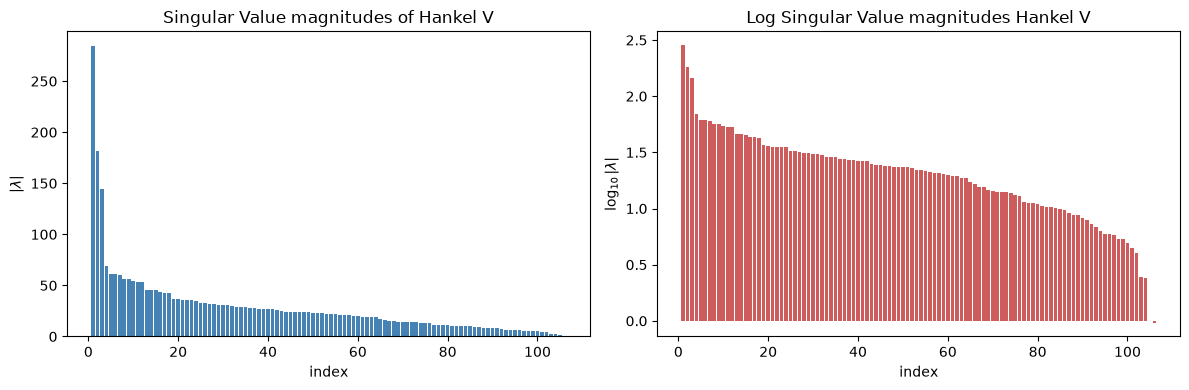

 12%|█▏        | 1801/15000 [13:19<4:33:21,  1.24s/it]

eff_rank: 34, stable_rank: 2.67, spikiness: 2.96, shape: (106, 106), non-zero rows :106, non-zero cols:106
top-r leverage spread: row min=0.005522 max=0.01269 (uniform 0.009434) | col min=0.005522 max=0.01269 (uniform 0.009434)
coherence score: row=1.345 col=1.345


 12%|█▏        | 1811/15000 [13:26<3:02:25,  1.20it/s]

episode 1810 avg_rewarg: 336.0


 12%|█▏        | 1821/15000 [13:35<3:38:41,  1.00it/s]

...

episode 1880 avg_rewarg: 463.0


 13%|█▎        | 1891/15000 [14:32<2:42:24,  1.35it/s]

episode 1890 avg_rewarg: 352.0


 13%|█▎        | 1900/15000 [14:39<2:33:06,  1.43it/s]

episode 1900 avg_rewarg: 508.0
****************************Hankel Q****************************


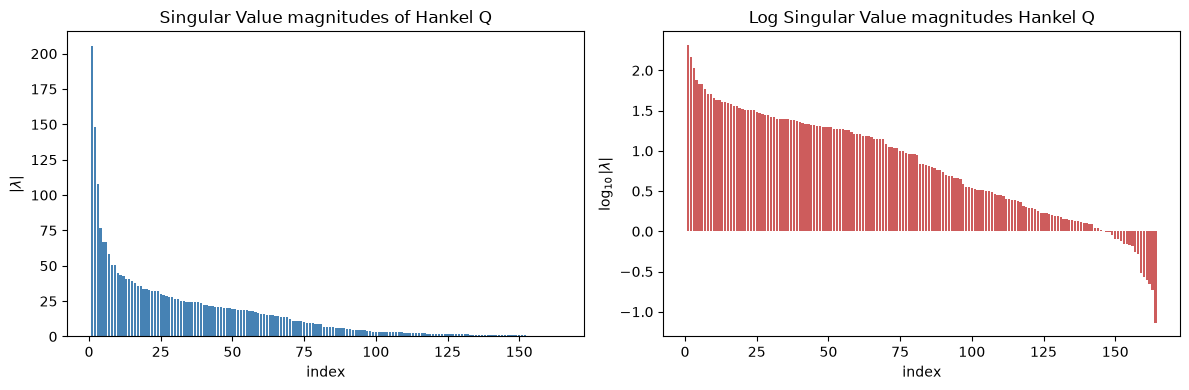

eff_rank: 36, stable_rank: 3.37, spikiness: 6.28, shape: (164, 164), non-zero rows :164, non-zero cols:164
top-r leverage spread: row min=0.0001182 max=0.01675 (uniform 0.006098) | col min=0.0001182 max=0.01675 (uniform 0.006098)
coherence score: row=2.747 col=2.747
****************************Hankel V****************************


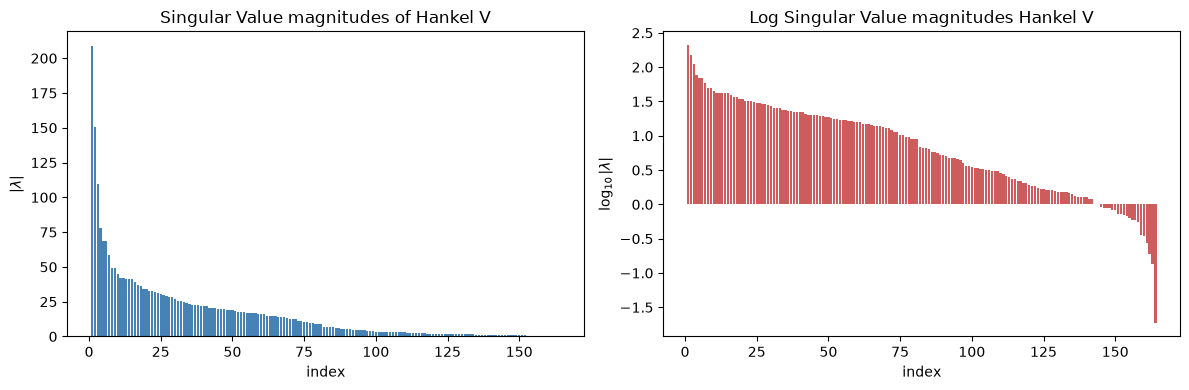

 13%|█▎        | 1901/15000 [14:42<4:41:13,  1.29s/it]

eff_rank: 34, stable_rank: 3.32, spikiness: 6.23, shape: (164, 164), non-zero rows :164, non-zero cols:164
top-r leverage spread: row min=0.0001279 max=0.01734 (uniform 0.006098) | col min=0.0001279 max=0.01734 (uniform 0.006098)
coherence score: row=2.844 col=2.844


 13%|█▎        | 1911/15000 [14:49<2:49:42,  1.29it/s]

episode 1910 avg_rewarg: 373.0


 13%|█▎        | 1921/15000 [14:56<2:50:15,  1.28it/s]

...

episode 1980 avg_rewarg: 625.0


 13%|█▎        | 1991/15000 [15:57<3:08:33,  1.15it/s]

episode 1990 avg_rewarg: 556.0


 13%|█▎        | 2000/15000 [16:07<3:28:42,  1.04it/s]

episode 2000 avg_rewarg: 421.0
****************************Hankel Q****************************


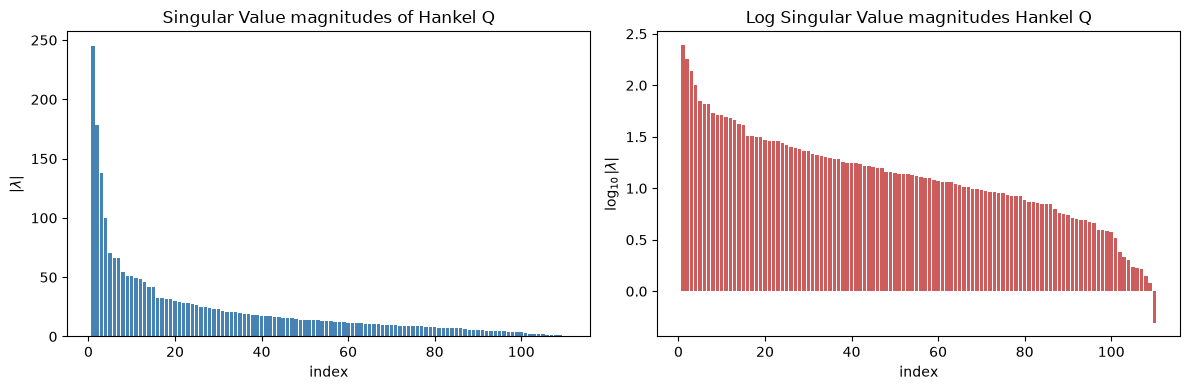

eff_rank: 20, stable_rank: 2.92, spikiness: 3.81, shape: (110, 110), non-zero rows :110, non-zero cols:110
top-r leverage spread: row min=0.001435 max=0.01645 (uniform 0.009091) | col min=0.001435 max=0.01645 (uniform 0.009091)
coherence score: row=1.809 col=1.809
****************************Hankel V****************************


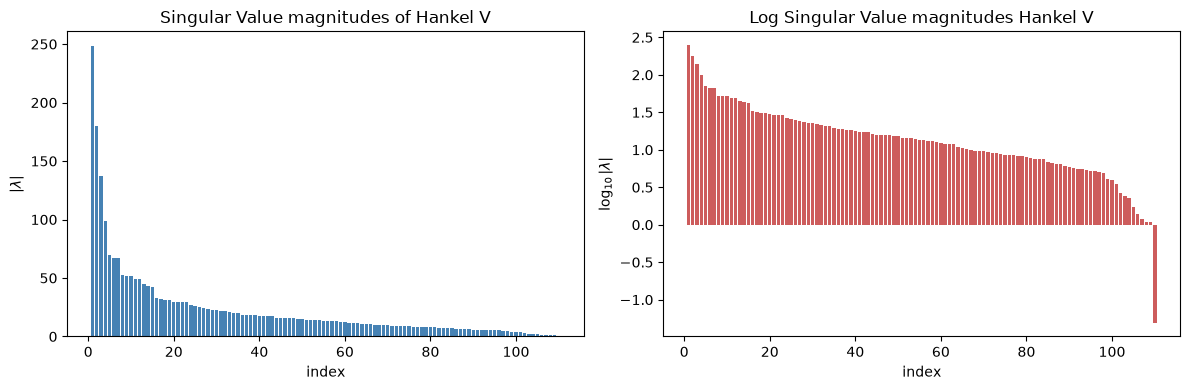

 13%|█▎        | 2001/15000 [16:09<4:56:45,  1.37s/it]

eff_rank: 20, stable_rank: 2.88, spikiness: 3.78, shape: (110, 110), non-zero rows :110, non-zero cols:110
top-r leverage spread: row min=0.00129 max=0.0168 (uniform 0.009091) | col min=0.00129 max=0.0168 (uniform 0.009091)
coherence score: row=1.848 col=1.848


 13%|█▎        | 2011/15000 [16:18<3:37:20,  1.00s/it]

episode 2010 avg_rewarg: 467.0


 13%|█▎        | 2021/15000 [16:26<3:07:08,  1.16it/s]

...

episode 2080 avg_rewarg: 487.0


 14%|█▍        | 2091/15000 [17:29<3:26:23,  1.04it/s]

episode 2090 avg_rewarg: 737.0


 14%|█▍        | 2100/15000 [17:36<3:02:38,  1.18it/s]

episode 2100 avg_rewarg: 341.0
****************************Hankel Q****************************


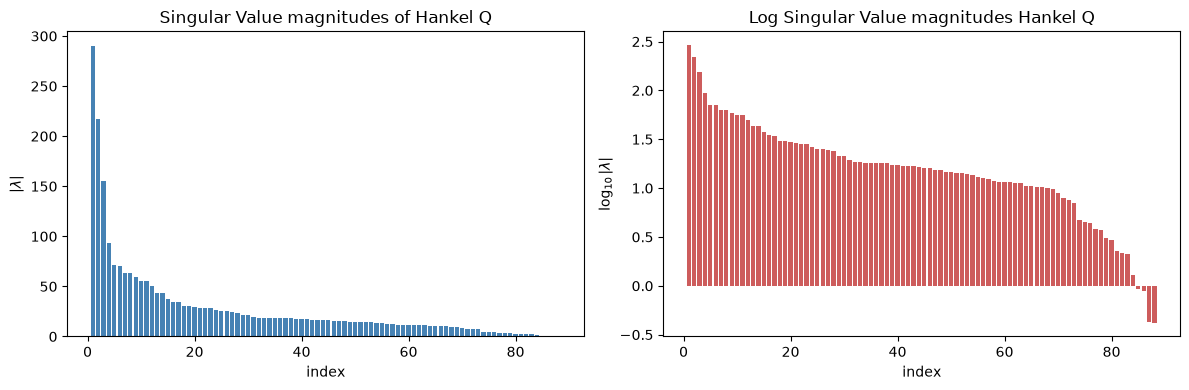

eff_rank: 14, stable_rank: 2.62, spikiness: 2.95, shape: (88, 88), non-zero rows :88, non-zero cols:88
top-r leverage spread: row min=0.004753 max=0.01409 (uniform 0.01136) | col min=0.004753 max=0.01409 (uniform 0.01136)
coherence score: row=1.24 col=1.24
****************************Hankel V****************************


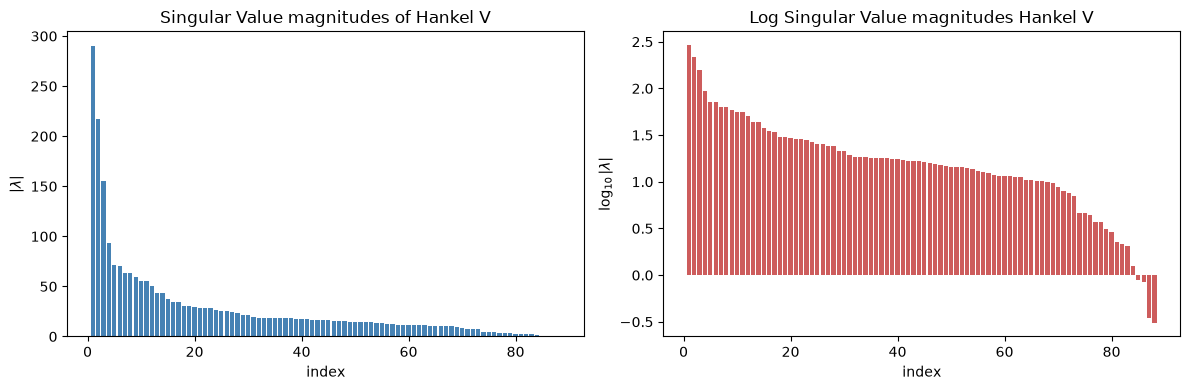

 14%|█▍        | 2101/15000 [17:37<3:47:15,  1.06s/it]

eff_rank: 14, stable_rank: 2.62, spikiness: 2.95, shape: (88, 88), non-zero rows :88, non-zero cols:88
top-r leverage spread: row min=0.004753 max=0.01409 (uniform 0.01136) | col min=0.004753 max=0.01409 (uniform 0.01136)
coherence score: row=1.24 col=1.24


 14%|█▍        | 2111/15000 [17:45<2:53:05,  1.24it/s]

episode 2110 avg_rewarg: 409.0


 14%|█▍        | 2121/15000 [17:53<2:19:53,  1.53it/s]

...

episode 2180 avg_rewarg: 892.0


 15%|█▍        | 2191/15000 [18:57<3:21:17,  1.06it/s]

episode 2190 avg_rewarg: 851.0


 15%|█▍        | 2200/15000 [19:06<3:10:26,  1.12it/s]

episode 2200 avg_rewarg: 647.0
****************************Hankel Q****************************


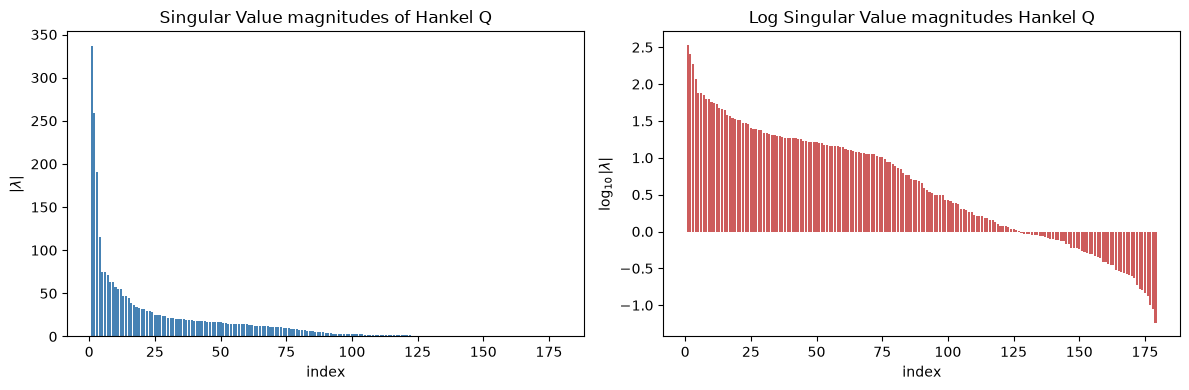

eff_rank: 13, stable_rank: 2.60, spikiness: 5.45, shape: (179, 179), non-zero rows :179, non-zero cols:179
top-r leverage spread: row min=1.661e-05 max=0.01842 (uniform 0.005587) | col min=1.661e-05 max=0.01842 (uniform 0.005587)
coherence score: row=3.297 col=3.297
****************************Hankel V****************************


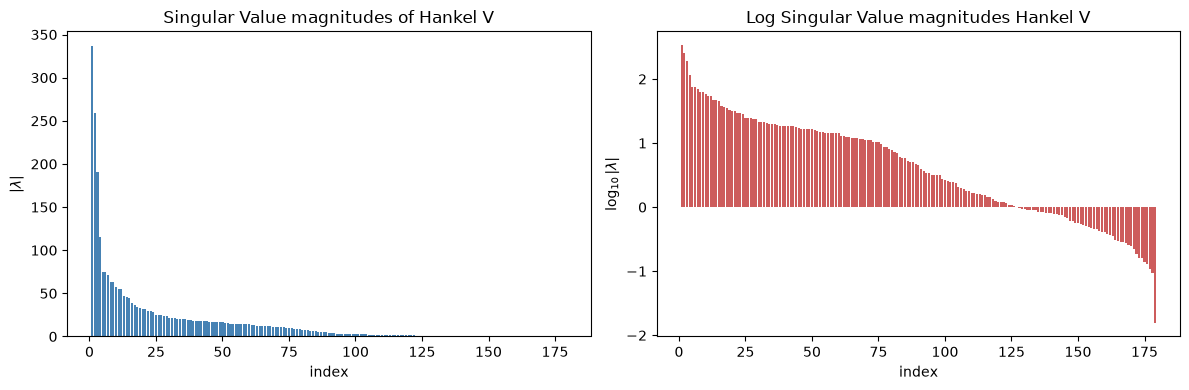

 15%|█▍        | 2201/15000 [19:09<5:12:25,  1.46s/it]

eff_rank: 13, stable_rank: 2.60, spikiness: 5.45, shape: (179, 179), non-zero rows :179, non-zero cols:179
top-r leverage spread: row min=1.737e-05 max=0.01848 (uniform 0.005587) | col min=1.737e-05 max=0.01848 (uniform 0.005587)
coherence score: row=3.308 col=3.308


 15%|█▍        | 2211/15000 [19:19<3:43:07,  1.05s/it]

episode 2210 avg_rewarg: 811.0


 15%|█▍        | 2222/15000 [19:29<2:21:30,  1.51it/s]

...

episode 2280 avg_rewarg: 413.0


 15%|█▌        | 2291/15000 [20:32<2:57:18,  1.19it/s]

episode 2290 avg_rewarg: 685.0


 15%|█▌        | 2300/15000 [20:40<2:30:33,  1.41it/s]

episode 2300 avg_rewarg: 538.0
****************************Hankel Q****************************


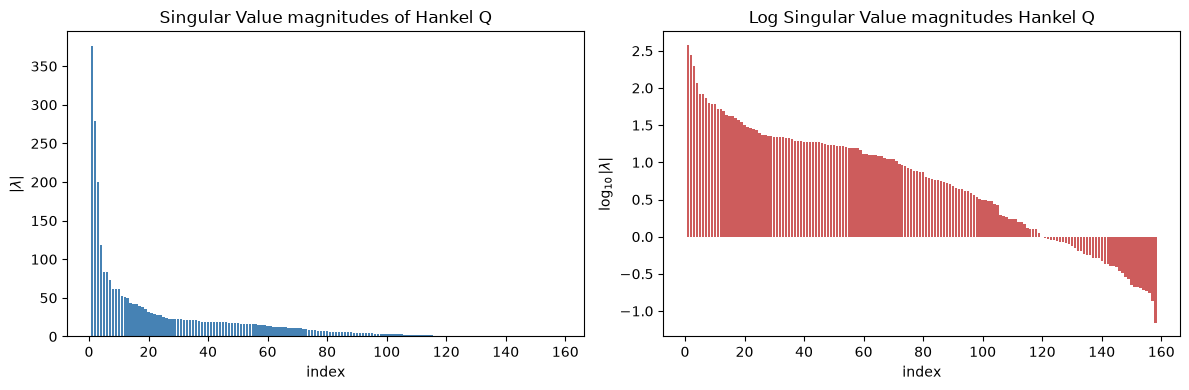

eff_rank: 12, stable_rank: 2.41, spikiness: 4.89, shape: (158, 158), non-zero rows :158, non-zero cols:158
top-r leverage spread: row min=5.346e-05 max=0.01714 (uniform 0.006329) | col min=5.346e-05 max=0.01714 (uniform 0.006329)
coherence score: row=2.707 col=2.707
****************************Hankel V****************************


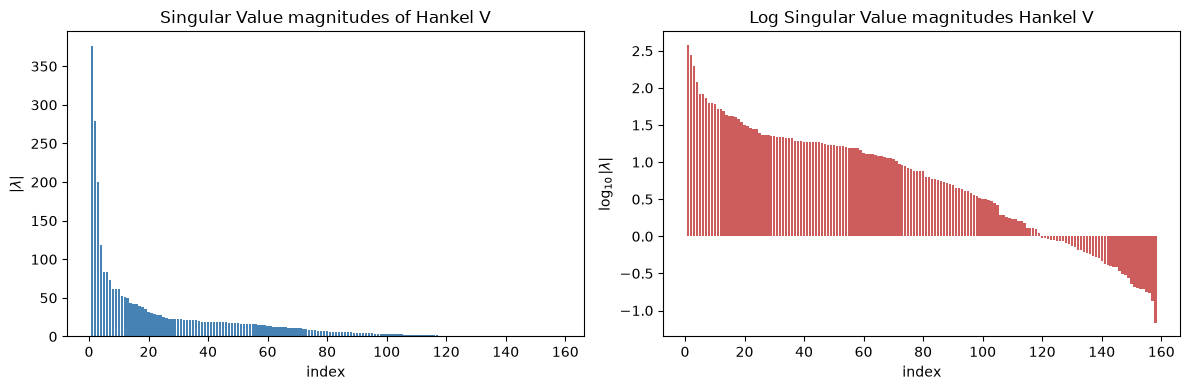

 15%|█▌        | 2302/15000 [20:43<3:28:32,  1.01it/s]

eff_rank: 12, stable_rank: 2.41, spikiness: 4.89, shape: (158, 158), non-zero rows :158, non-zero cols:158
top-r leverage spread: row min=5.35e-05 max=0.01715 (uniform 0.006329) | col min=5.35e-05 max=0.01715 (uniform 0.006329)
coherence score: row=2.709 col=2.709


 15%|█▌        | 2311/15000 [20:51<3:39:49,  1.04s/it]

episode 2310 avg_rewarg: 351.0


 15%|█▌        | 2321/15000 [21:01<3:48:34,  1.08s/it]

...

episode 2380 avg_rewarg: 617.0


 16%|█▌        | 2391/15000 [22:05<2:48:09,  1.25it/s]

episode 2390 avg_rewarg: 435.0


 16%|█▌        | 2400/15000 [22:13<3:53:35,  1.11s/it]

episode 2400 avg_rewarg: 586.0
****************************Hankel Q****************************


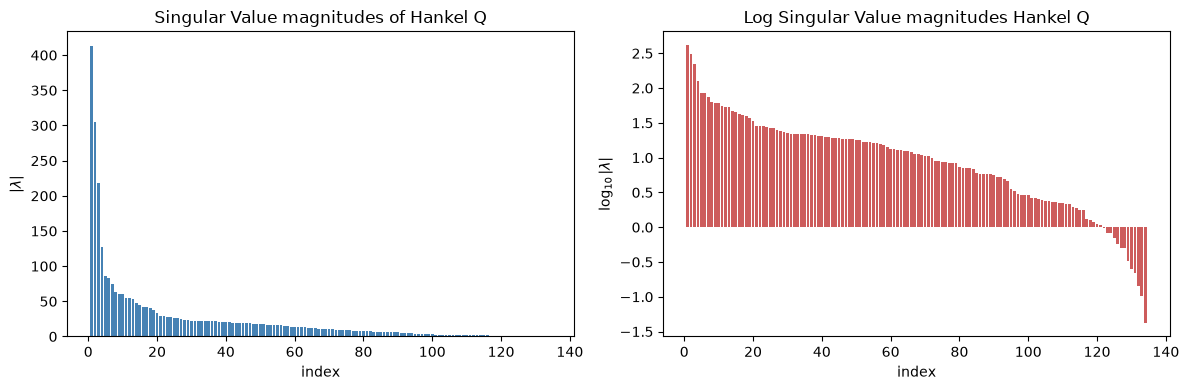

eff_rank: 11, stable_rank: 2.35, spikiness: 4.07, shape: (134, 134), non-zero rows :134, non-zero cols:134
top-r leverage spread: row min=5.807e-05 max=0.01984 (uniform 0.007463) | col min=5.807e-05 max=0.01984 (uniform 0.007463)
coherence score: row=2.659 col=2.659
****************************Hankel V****************************


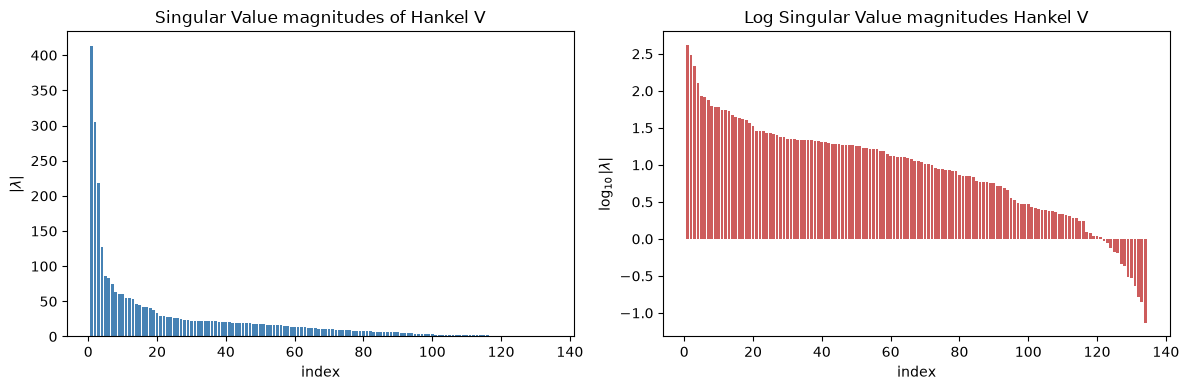

 16%|█▌        | 2401/15000 [22:17<6:49:00,  1.95s/it]

eff_rank: 11, stable_rank: 2.34, spikiness: 4.07, shape: (134, 134), non-zero rows :134, non-zero cols:134
top-r leverage spread: row min=5.782e-05 max=0.01987 (uniform 0.007463) | col min=5.782e-05 max=0.01987 (uniform 0.007463)
coherence score: row=2.662 col=2.662


 16%|█▌        | 2411/15000 [22:25<3:17:27,  1.06it/s]

episode 2410 avg_rewarg: 420.0


 16%|█▌        | 2421/15000 [22:35<3:02:38,  1.15it/s]

...

episode 2480 avg_rewarg: 813.0


 17%|█▋        | 2491/15000 [23:41<2:31:19,  1.38it/s]

episode 2490 avg_rewarg: 835.0


 17%|█▋        | 2500/15000 [23:50<3:08:57,  1.10it/s]

episode 2500 avg_rewarg: 872.0
****************************Hankel Q****************************


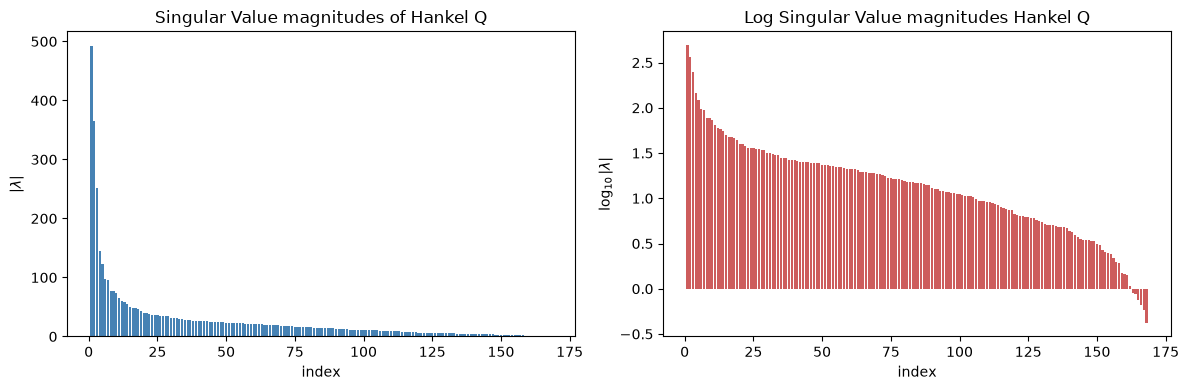

eff_rank: 14, stable_rank: 2.40, spikiness: 4.40, shape: (168, 168), non-zero rows :168, non-zero cols:168
top-r leverage spread: row min=0.001701 max=0.01529 (uniform 0.005952) | col min=0.001701 max=0.01529 (uniform 0.005952)
coherence score: row=2.568 col=2.568
****************************Hankel V****************************


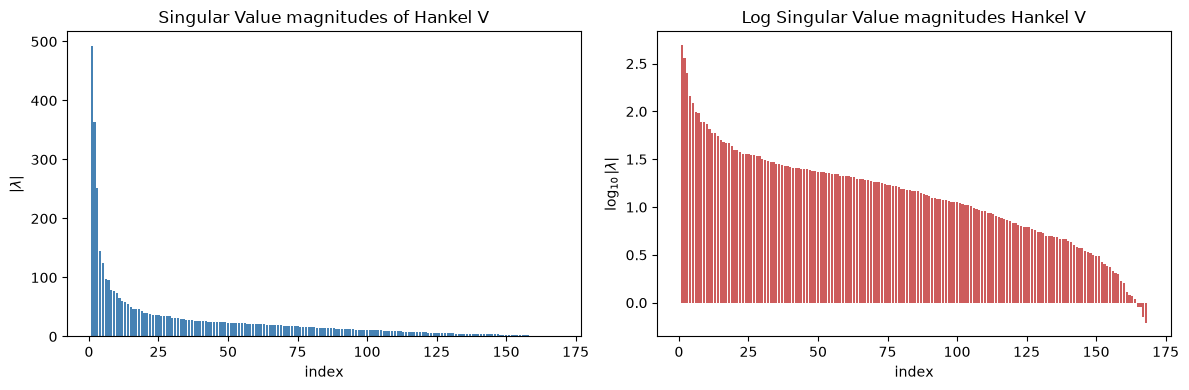

 17%|█▋        | 2501/15000 [23:53<5:08:13,  1.48s/it]

eff_rank: 14, stable_rank: 2.40, spikiness: 4.40, shape: (168, 168), non-zero rows :168, non-zero cols:168
top-r leverage spread: row min=0.001688 max=0.0153 (uniform 0.005952) | col min=0.001688 max=0.0153 (uniform 0.005952)
coherence score: row=2.57 col=2.57


 17%|█▋        | 2511/15000 [24:01<2:45:19,  1.26it/s]

episode 2510 avg_rewarg: 614.0


 17%|█▋        | 2521/15000 [24:11<3:41:06,  1.06s/it]

...

episode 2580 avg_rewarg: 621.0


 17%|█▋        | 2591/15000 [25:14<3:26:40,  1.00it/s]

episode 2590 avg_rewarg: 700.0


 17%|█▋        | 2600/15000 [25:23<3:35:43,  1.04s/it]

episode 2600 avg_rewarg: 581.0
****************************Hankel Q****************************


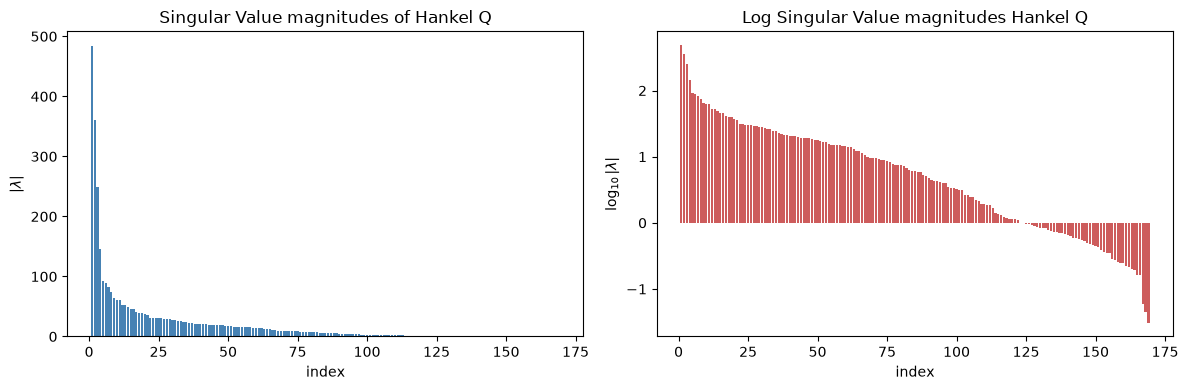

eff_rank: 9, stable_rank: 2.26, spikiness: 4.85, shape: (169, 169), non-zero rows :169, non-zero cols:169
top-r leverage spread: row min=4.913e-05 max=0.02346 (uniform 0.005917) | col min=4.913e-05 max=0.02346 (uniform 0.005917)
coherence score: row=3.965 col=3.965
****************************Hankel V****************************


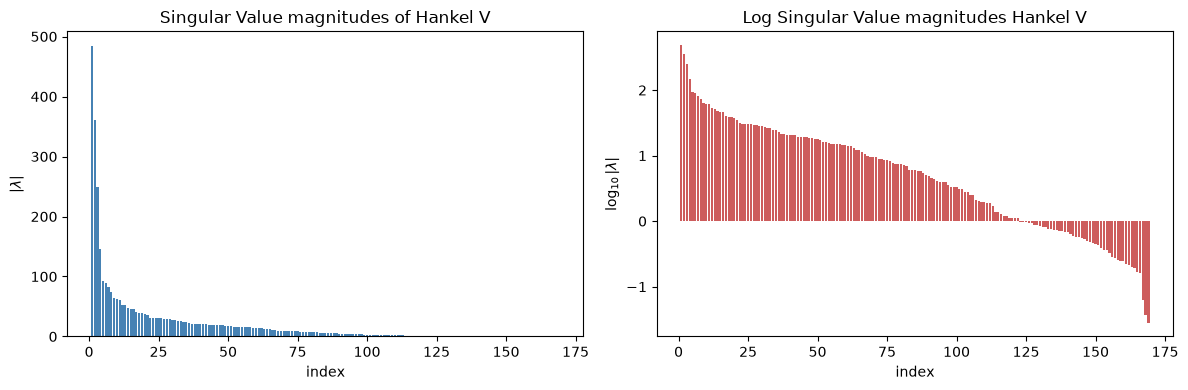

 17%|█▋        | 2601/15000 [25:26<5:27:51,  1.59s/it]

eff_rank: 9, stable_rank: 2.26, spikiness: 4.84, shape: (169, 169), non-zero rows :169, non-zero cols:169
top-r leverage spread: row min=4.92e-05 max=0.02341 (uniform 0.005917) | col min=4.92e-05 max=0.02341 (uniform 0.005917)
coherence score: row=3.957 col=3.957


 17%|█▋        | 2611/15000 [25:36<2:32:14,  1.36it/s]

episode 2610 avg_rewarg: 696.0


 17%|█▋        | 2621/15000 [25:45<4:02:41,  1.18s/it]

...

episode 2680 avg_rewarg: 482.0


 18%|█▊        | 2691/15000 [26:43<3:24:05,  1.01it/s]

episode 2690 avg_rewarg: 523.0


 18%|█▊        | 2700/15000 [26:50<2:41:37,  1.27it/s]

episode 2700 avg_rewarg: 527.0
****************************Hankel Q****************************


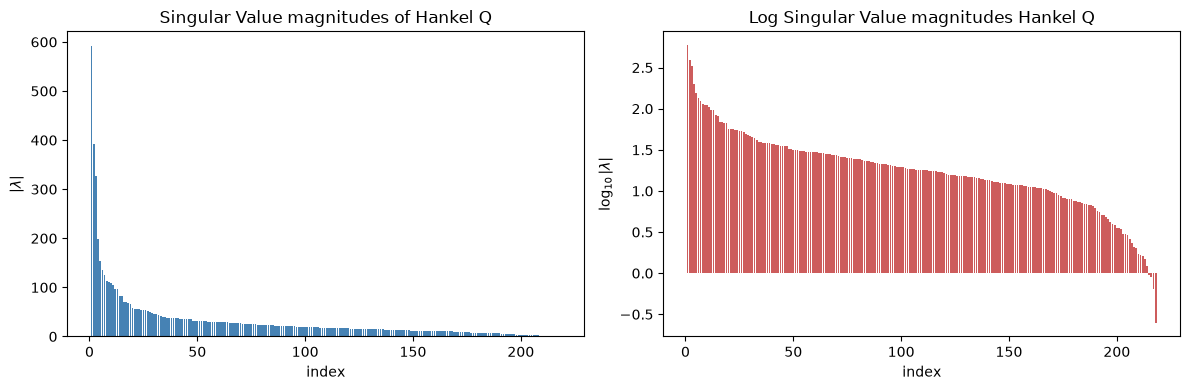

eff_rank: 25, stable_rank: 2.62, spikiness: 5.02, shape: (218, 218), non-zero rows :218, non-zero cols:218
top-r leverage spread: row min=0.00159 max=0.01034 (uniform 0.004587) | col min=0.00159 max=0.01034 (uniform 0.004587)
coherence score: row=2.254 col=2.254
****************************Hankel V****************************


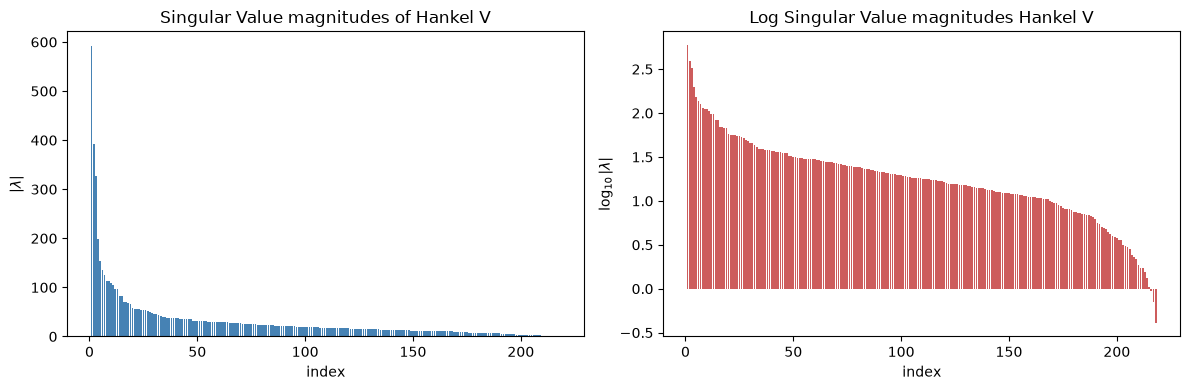

 18%|█▊        | 2701/15000 [26:53<4:40:00,  1.37s/it]

eff_rank: 25, stable_rank: 2.62, spikiness: 5.02, shape: (218, 218), non-zero rows :218, non-zero cols:218
top-r leverage spread: row min=0.001589 max=0.01035 (uniform 0.004587) | col min=0.001589 max=0.01035 (uniform 0.004587)
coherence score: row=2.256 col=2.256


 18%|█▊        | 2711/15000 [27:01<2:30:30,  1.36it/s]

episode 2710 avg_rewarg: 628.0


 18%|█▊        | 2721/15000 [27:08<2:25:13,  1.41it/s]

...

episode 2780 avg_rewarg: 967.0


 19%|█▊        | 2791/15000 [28:11<2:41:23,  1.26it/s]

episode 2790 avg_rewarg: 682.0


 19%|█▊        | 2800/15000 [28:21<3:43:10,  1.10s/it]

episode 2800 avg_rewarg: 965.0
****************************Hankel Q****************************


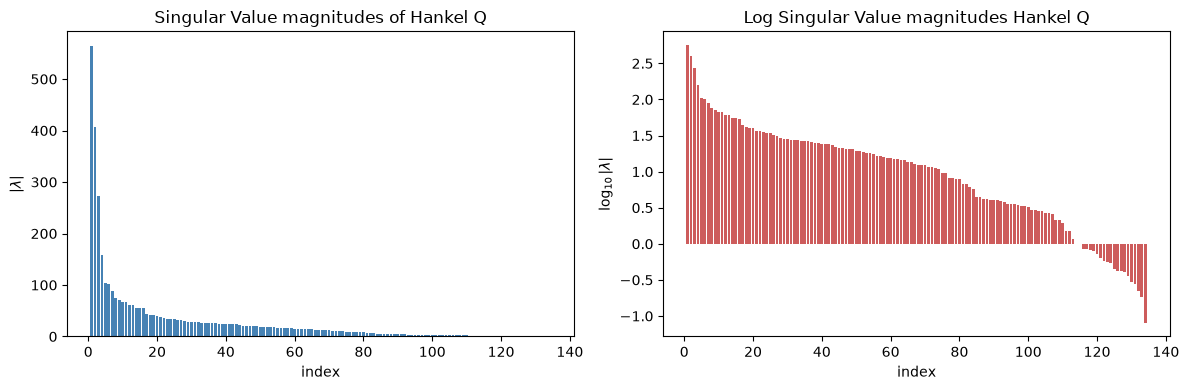

eff_rank: 8, stable_rank: 2.15, spikiness: 3.68, shape: (134, 134), non-zero rows :134, non-zero cols:134
top-r leverage spread: row min=8.176e-05 max=0.02076 (uniform 0.007463) | col min=8.176e-05 max=0.02076 (uniform 0.007463)
coherence score: row=2.782 col=2.782
****************************Hankel V****************************


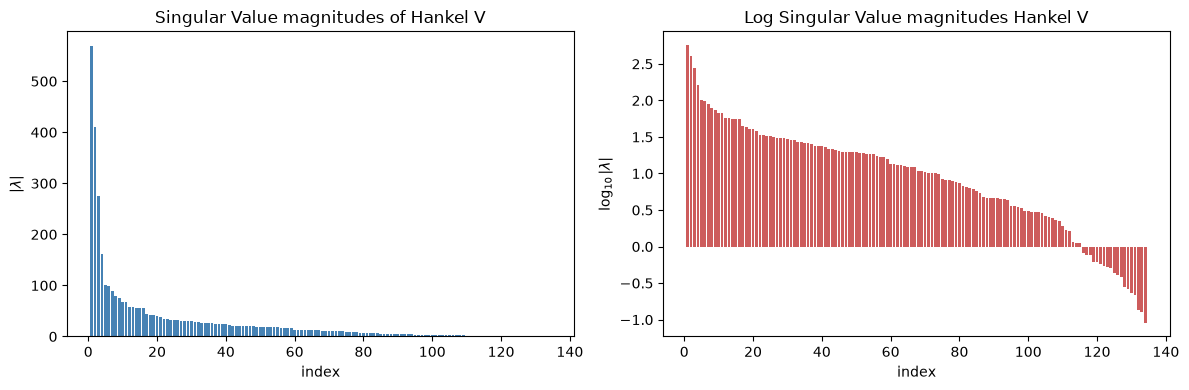

 19%|█▊        | 2801/15000 [28:26<7:19:25,  2.16s/it]

eff_rank: 8, stable_rank: 2.14, spikiness: 3.65, shape: (134, 134), non-zero rows :134, non-zero cols:134
top-r leverage spread: row min=8.303e-05 max=0.01985 (uniform 0.007463) | col min=8.303e-05 max=0.01985 (uniform 0.007463)
coherence score: row=2.66 col=2.66


 19%|█▊        | 2811/15000 [28:35<3:03:02,  1.11it/s]

episode 2810 avg_rewarg: 664.0


 19%|█▉        | 2821/15000 [28:44<3:06:42,  1.09it/s]

...

episode 2880 avg_rewarg: 607.0


 19%|█▉        | 2891/15000 [29:48<3:02:12,  1.11it/s]

episode 2890 avg_rewarg: 620.0


 19%|█▉        | 2900/15000 [29:55<2:51:35,  1.18it/s]

episode 2900 avg_rewarg: 659.0
****************************Hankel Q****************************


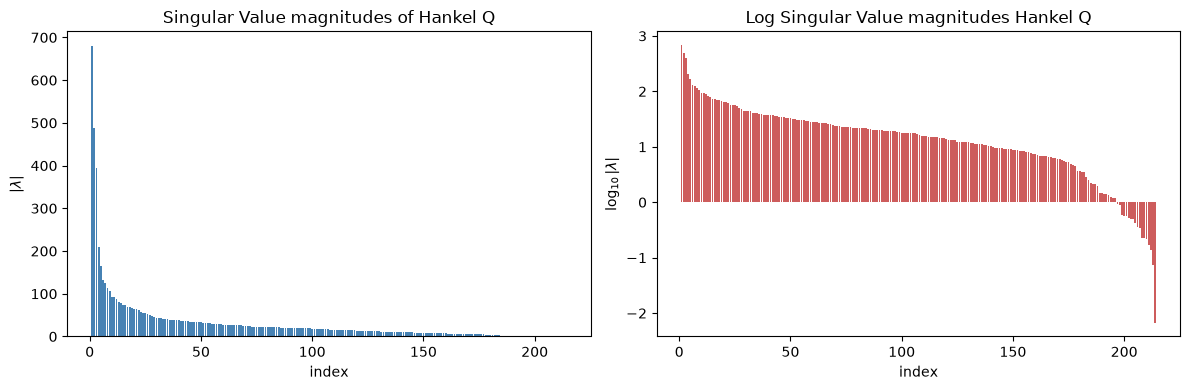

eff_rank: 17, stable_rank: 2.48, spikiness: 4.92, shape: (214, 214), non-zero rows :214, non-zero cols:214
top-r leverage spread: row min=3.367e-05 max=0.01231 (uniform 0.004673) | col min=3.367e-05 max=0.01231 (uniform 0.004673)
coherence score: row=2.634 col=2.634
****************************Hankel V****************************


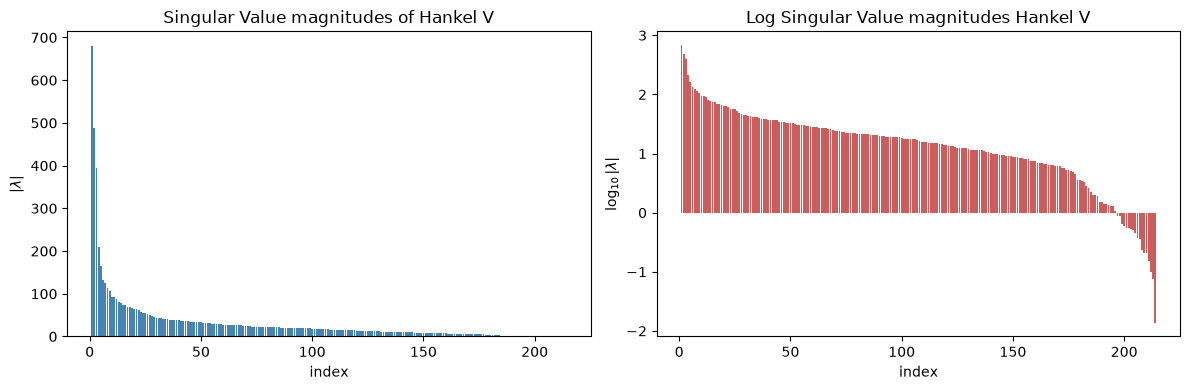

 19%|█▉        | 2901/15000 [29:58<4:47:09,  1.42s/it]

eff_rank: 17, stable_rank: 2.48, spikiness: 4.92, shape: (214, 214), non-zero rows :214, non-zero cols:214
top-r leverage spread: row min=3.349e-05 max=0.01232 (uniform 0.004673) | col min=3.349e-05 max=0.01232 (uniform 0.004673)
coherence score: row=2.636 col=2.636


 19%|█▉        | 2911/15000 [30:09<3:55:52,  1.17s/it]

episode 2910 avg_rewarg: 824.0


 19%|█▉        | 2921/15000 [30:18<3:05:51,  1.08it/s]

...

episode 2980 avg_rewarg: 774.0


 20%|█▉        | 2991/15000 [31:24<3:13:22,  1.04it/s]

episode 2990 avg_rewarg: 890.0


 20%|██        | 3000/15000 [31:32<2:48:52,  1.18it/s]

episode 3000 avg_rewarg: 748.0
****************************Hankel Q****************************


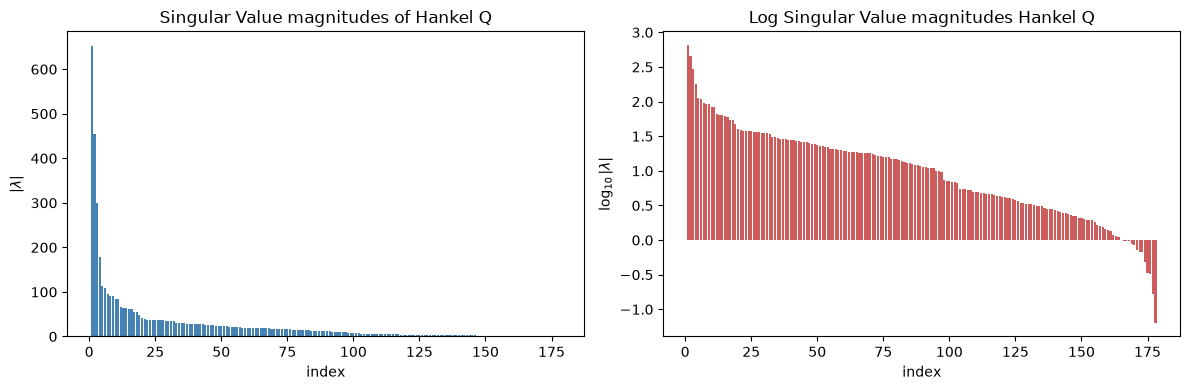

eff_rank: 9, stable_rank: 2.10, spikiness: 4.79, shape: (178, 178), non-zero rows :178, non-zero cols:178
top-r leverage spread: row min=1.885e-05 max=0.01941 (uniform 0.005618) | col min=1.885e-05 max=0.01941 (uniform 0.005618)
coherence score: row=3.454 col=3.454
****************************Hankel V****************************


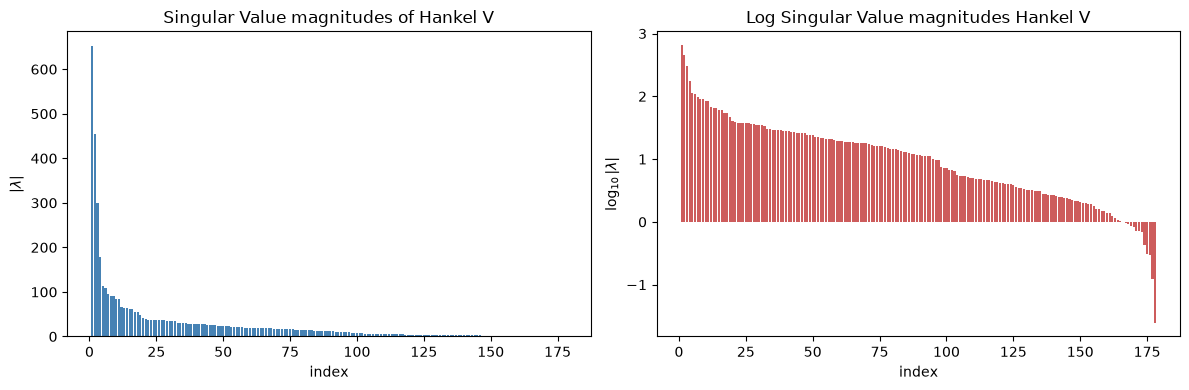

 20%|██        | 3001/15000 [31:35<5:34:33,  1.67s/it]

eff_rank: 9, stable_rank: 2.10, spikiness: 4.79, shape: (178, 178), non-zero rows :178, non-zero cols:178
top-r leverage spread: row min=1.911e-05 max=0.01941 (uniform 0.005618) | col min=1.911e-05 max=0.01941 (uniform 0.005618)
coherence score: row=3.454 col=3.454


 20%|██        | 3011/15000 [31:46<3:42:04,  1.11s/it]

episode 3010 avg_rewarg: 866.0


 20%|██        | 3021/15000 [31:56<3:02:52,  1.09it/s]

...

episode 3080 avg_rewarg: 691.0


 21%|██        | 3091/15000 [32:57<2:17:18,  1.45it/s]

episode 3090 avg_rewarg: 531.0


 21%|██        | 3100/15000 [33:05<2:34:08,  1.29it/s]

episode 3100 avg_rewarg: 706.0
****************************Hankel Q****************************


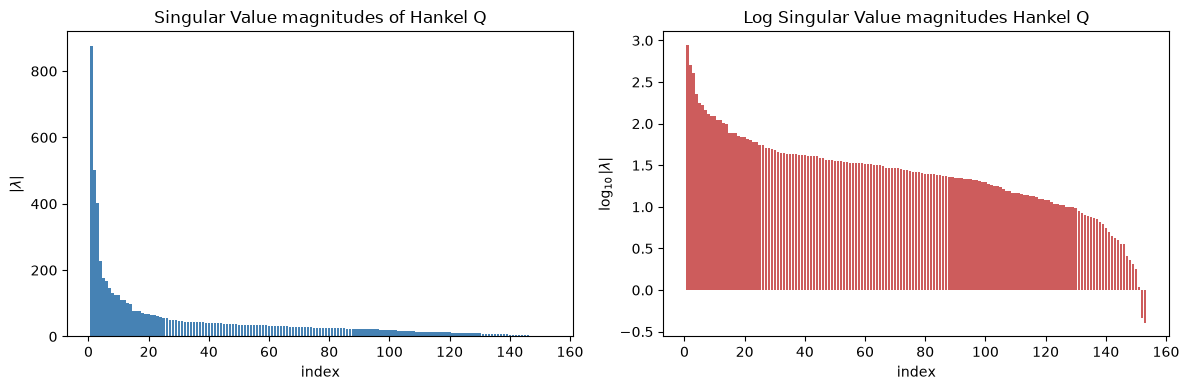

eff_rank: 13, stable_rank: 2.02, spikiness: 3.24, shape: (153, 153), non-zero rows :153, non-zero cols:153
top-r leverage spread: row min=0.002059 max=0.01219 (uniform 0.006536) | col min=0.002059 max=0.01219 (uniform 0.006536)
coherence score: row=1.866 col=1.866
****************************Hankel V****************************


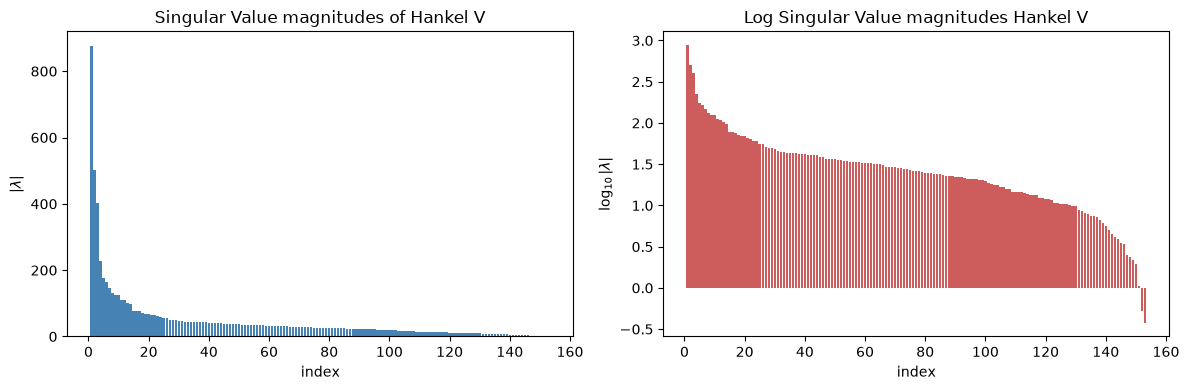

 21%|██        | 3101/15000 [33:07<4:14:24,  1.28s/it]

eff_rank: 13, stable_rank: 2.02, spikiness: 3.24, shape: (153, 153), non-zero rows :153, non-zero cols:153
top-r leverage spread: row min=0.002059 max=0.01219 (uniform 0.006536) | col min=0.002059 max=0.01219 (uniform 0.006536)
coherence score: row=1.865 col=1.865


 21%|██        | 3111/15000 [33:16<3:01:40,  1.09it/s]

episode 3110 avg_rewarg: 641.0


 21%|██        | 3121/15000 [33:27<2:40:55,  1.23it/s]

...

episode 3180 avg_rewarg: 842.0


 21%|██▏       | 3191/15000 [34:37<3:36:14,  1.10s/it]

episode 3190 avg_rewarg: 599.0


 21%|██▏       | 3200/15000 [34:46<3:10:59,  1.03it/s]

episode 3200 avg_rewarg: 774.0
****************************Hankel Q****************************


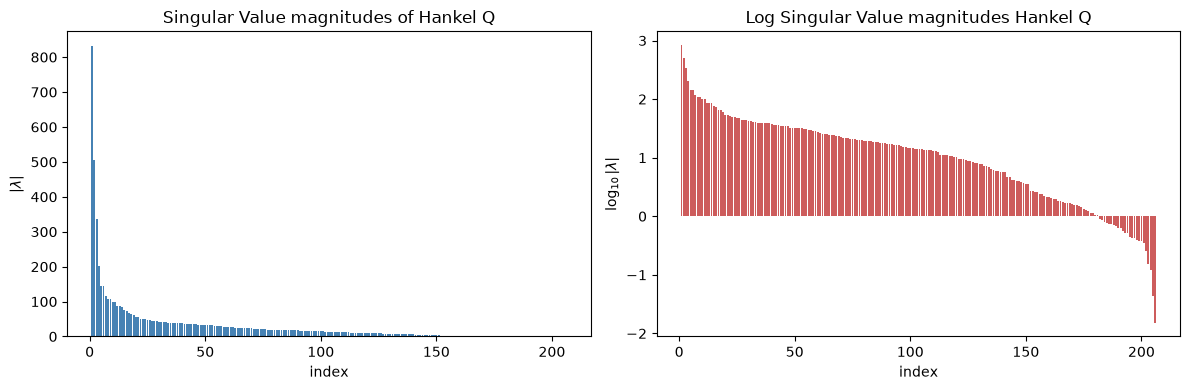

eff_rank: 11, stable_rank: 1.92, spikiness: 4.87, shape: (206, 206), non-zero rows :206, non-zero cols:206
top-r leverage spread: row min=1.882e-05 max=0.01506 (uniform 0.004854) | col min=1.882e-05 max=0.01506 (uniform 0.004854)
coherence score: row=3.103 col=3.103
****************************Hankel V****************************


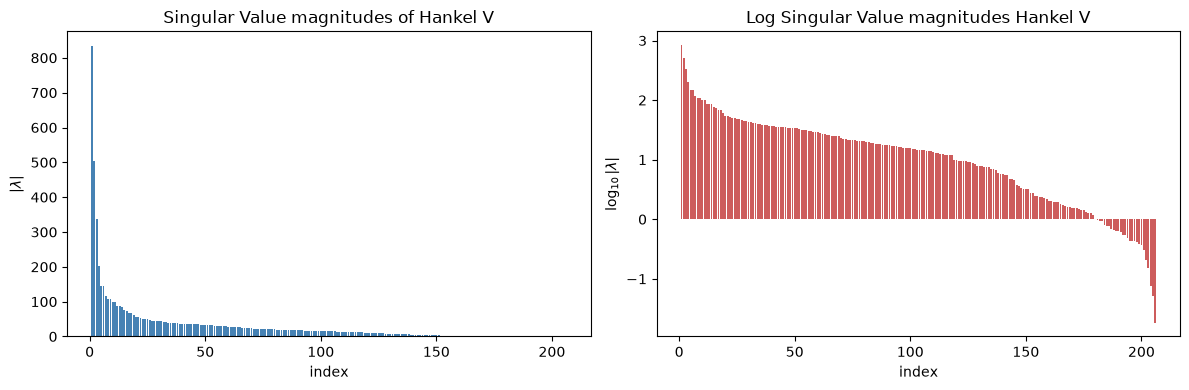

 21%|██▏       | 3202/15000 [34:51<5:10:22,  1.58s/it]

eff_rank: 11, stable_rank: 1.92, spikiness: 4.86, shape: (206, 206), non-zero rows :206, non-zero cols:206
top-r leverage spread: row min=1.899e-05 max=0.01514 (uniform 0.004854) | col min=1.899e-05 max=0.01514 (uniform 0.004854)
coherence score: row=3.119 col=3.119


 21%|██▏       | 3211/15000 [35:00<2:42:11,  1.21it/s]

episode 3210 avg_rewarg: 601.0


 21%|██▏       | 3221/15000 [35:09<3:03:35,  1.07it/s]

...

episode 3280 avg_rewarg: 585.0


 22%|██▏       | 3291/15000 [36:21<2:58:26,  1.09it/s]

episode 3290 avg_rewarg: 765.0


 22%|██▏       | 3300/15000 [36:31<2:51:35,  1.14it/s]

episode 3300 avg_rewarg: 947.0
****************************Hankel Q****************************


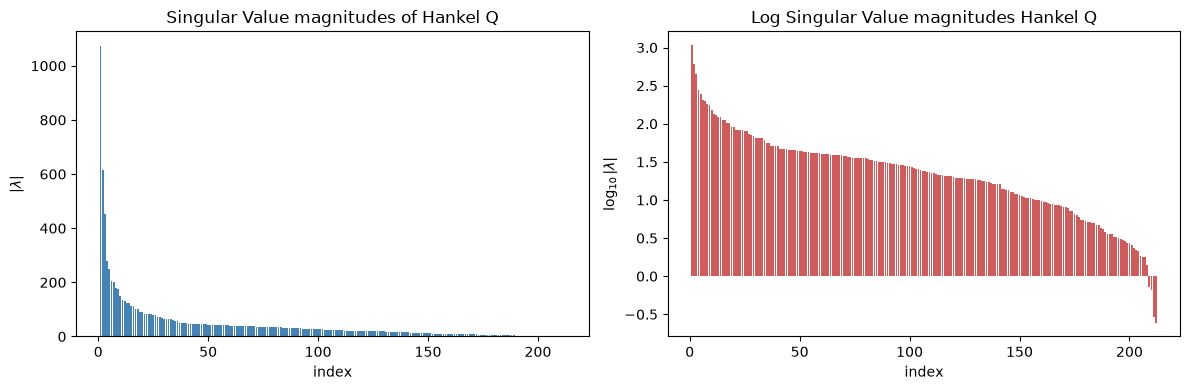

eff_rank: 17, stable_rank: 2.06, spikiness: 3.87, shape: (212, 212), non-zero rows :212, non-zero cols:212
top-r leverage spread: row min=0.001331 max=0.008021 (uniform 0.004717) | col min=0.001331 max=0.008021 (uniform 0.004717)
coherence score: row=1.701 col=1.701
****************************Hankel V****************************


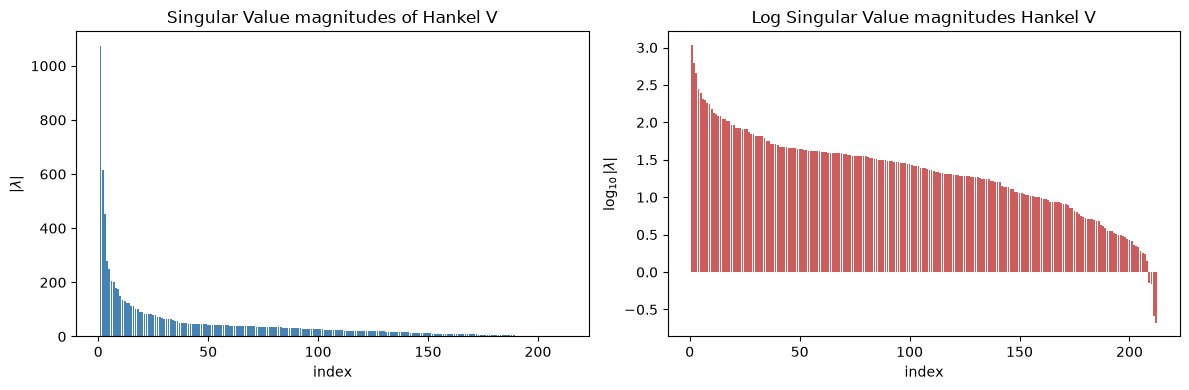

 22%|██▏       | 3301/15000 [36:34<4:28:26,  1.38s/it]

eff_rank: 17, stable_rank: 2.06, spikiness: 3.87, shape: (212, 212), non-zero rows :212, non-zero cols:212
top-r leverage spread: row min=0.00133 max=0.008022 (uniform 0.004717) | col min=0.00133 max=0.008022 (uniform 0.004717)
coherence score: row=1.701 col=1.701


 22%|██▏       | 3311/15000 [36:43<2:53:09,  1.13it/s]

episode 3310 avg_rewarg: 571.0


 22%|██▏       | 3321/15000 [36:53<3:33:27,  1.10s/it]

...

episode 3380 avg_rewarg: 708.0


 23%|██▎       | 3391/15000 [38:03<3:25:33,  1.06s/it]

episode 3390 avg_rewarg: 658.0


 23%|██▎       | 3400/15000 [38:12<2:53:13,  1.12it/s]

episode 3400 avg_rewarg: 749.0
****************************Hankel Q****************************


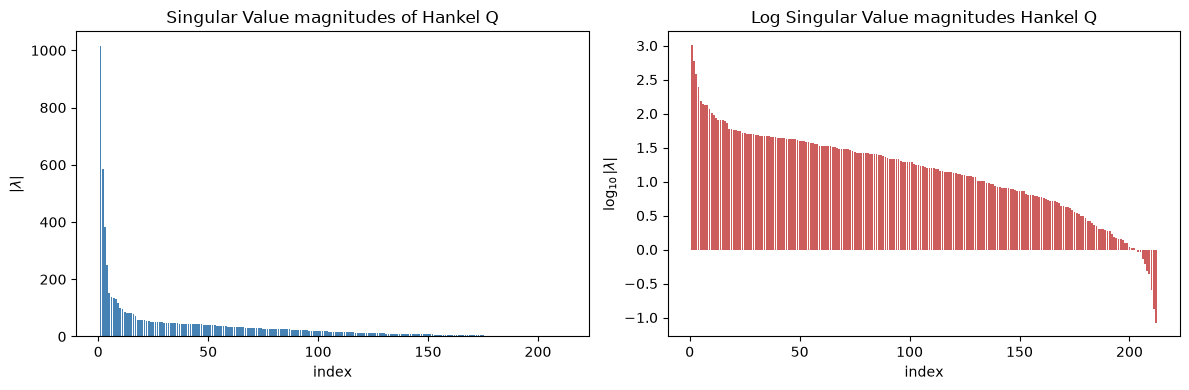

eff_rank: 9, stable_rank: 1.80, spikiness: 4.58, shape: (212, 212), non-zero rows :212, non-zero cols:212
top-r leverage spread: row min=6.382e-05 max=0.01902 (uniform 0.004717) | col min=6.382e-05 max=0.01902 (uniform 0.004717)
coherence score: row=4.032 col=4.032
****************************Hankel V****************************


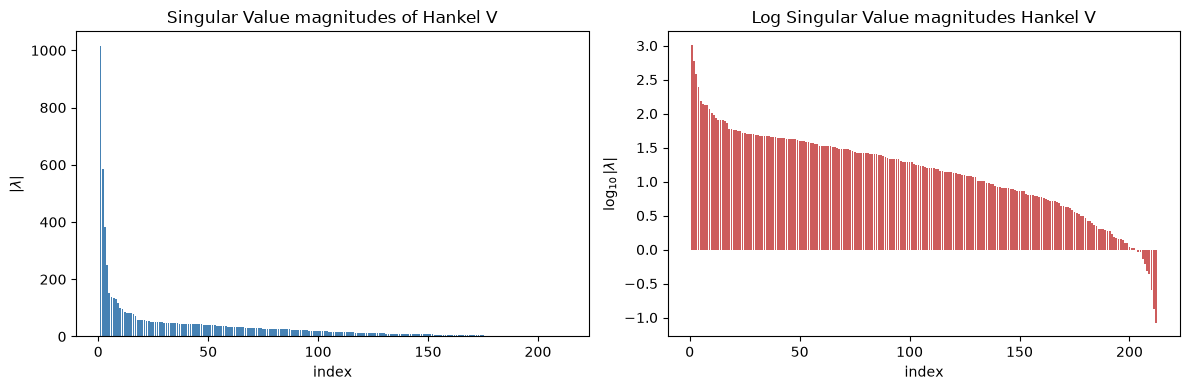

 23%|██▎       | 3401/15000 [38:15<5:06:02,  1.58s/it]

eff_rank: 9, stable_rank: 1.80, spikiness: 4.58, shape: (212, 212), non-zero rows :212, non-zero cols:212
top-r leverage spread: row min=6.382e-05 max=0.01902 (uniform 0.004717) | col min=6.382e-05 max=0.01902 (uniform 0.004717)
coherence score: row=4.032 col=4.032


 23%|██▎       | 3411/15000 [38:26<3:35:30,  1.12s/it]

episode 3410 avg_rewarg: 874.0


 23%|██▎       | 3421/15000 [38:37<3:30:54,  1.09s/it]

...

episode 3480 avg_rewarg: 717.0


 23%|██▎       | 3491/15000 [39:56<3:17:00,  1.03s/it]

episode 3490 avg_rewarg: 645.0


 23%|██▎       | 3500/15000 [40:05<2:59:03,  1.07it/s]

episode 3500 avg_rewarg: 730.0
****************************Hankel Q****************************


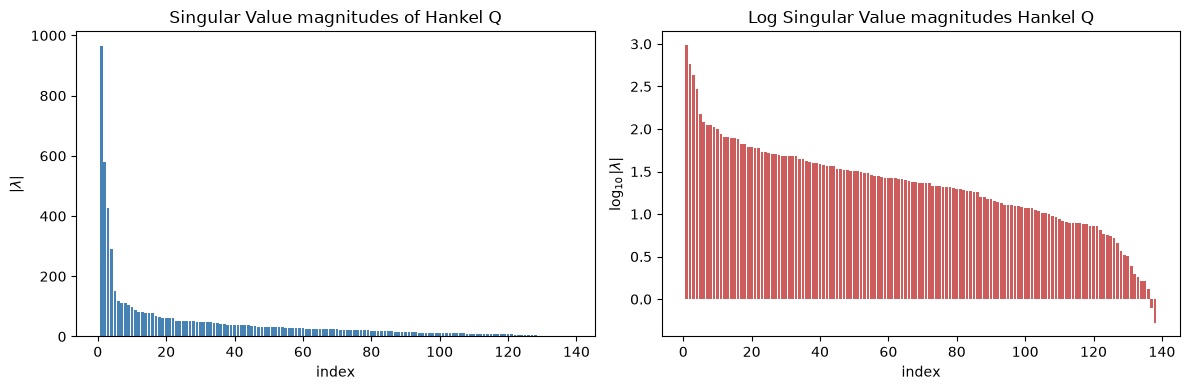

eff_rank: 7, stable_rank: 1.88, spikiness: 3.03, shape: (138, 138), non-zero rows :138, non-zero cols:138
top-r leverage spread: row min=0.0007916 max=0.02062 (uniform 0.007246) | col min=0.0007916 max=0.02062 (uniform 0.007246)
coherence score: row=2.845 col=2.845
****************************Hankel V****************************


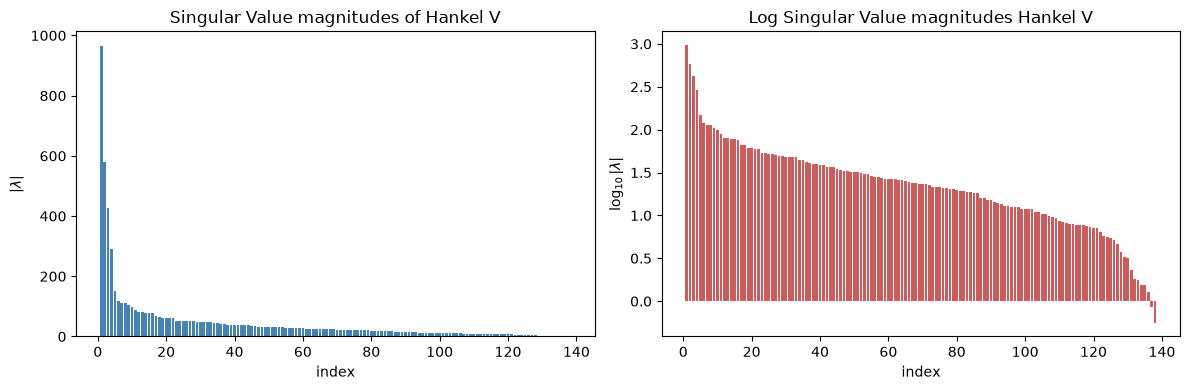

 23%|██▎       | 3501/15000 [40:07<4:14:30,  1.33s/it]

eff_rank: 7, stable_rank: 1.88, spikiness: 3.03, shape: (138, 138), non-zero rows :138, non-zero cols:138
top-r leverage spread: row min=0.0007922 max=0.02062 (uniform 0.007246) | col min=0.0007922 max=0.02062 (uniform 0.007246)
coherence score: row=2.845 col=2.845


 23%|██▎       | 3511/15000 [40:20<3:32:36,  1.11s/it]

episode 3510 avg_rewarg: 889.0


 23%|██▎       | 3521/15000 [40:33<4:07:59,  1.30s/it]

...

episode 3580 avg_rewarg: 859.0


 24%|██▍       | 3591/15000 [41:46<2:31:04,  1.26it/s]

episode 3590 avg_rewarg: 585.0


 24%|██▍       | 3600/15000 [41:55<2:33:28,  1.24it/s]

episode 3600 avg_rewarg: 893.0
****************************Hankel Q****************************


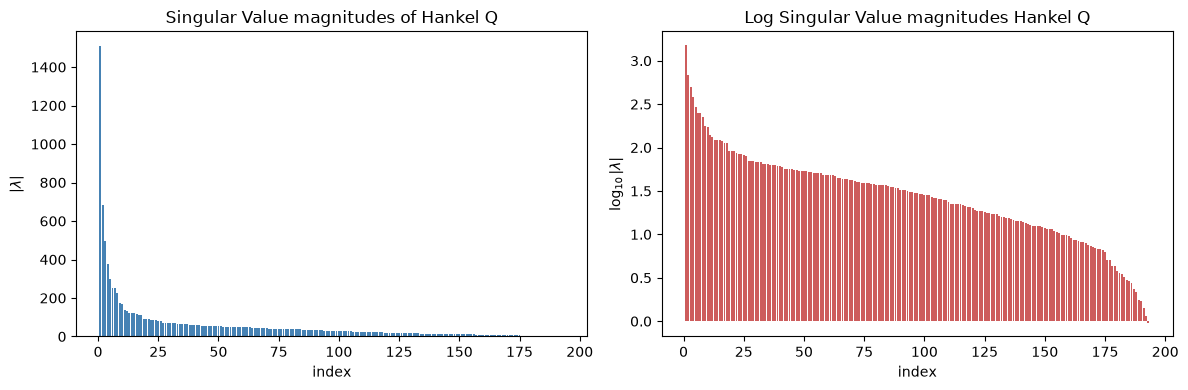

eff_rank: 10, stable_rank: 1.68, spikiness: 3.15, shape: (193, 193), non-zero rows :193, non-zero cols:193
top-r leverage spread: row min=0.0008348 max=0.01113 (uniform 0.005181) | col min=0.0008348 max=0.01113 (uniform 0.005181)
coherence score: row=2.148 col=2.148
****************************Hankel V****************************


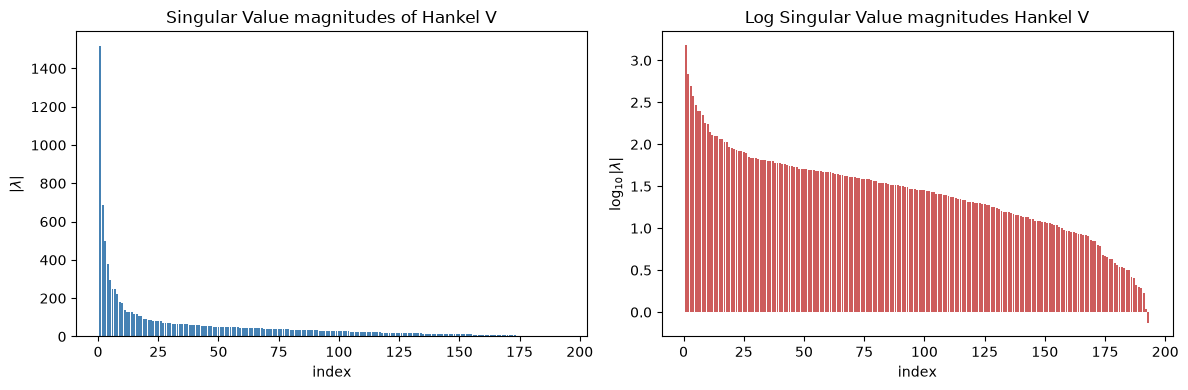

 24%|██▍       | 3601/15000 [42:00<6:46:16,  2.14s/it]

eff_rank: 10, stable_rank: 1.67, spikiness: 3.14, shape: (193, 193), non-zero rows :193, non-zero cols:193
top-r leverage spread: row min=0.0007981 max=0.0112 (uniform 0.005181) | col min=0.0007981 max=0.0112 (uniform 0.005181)
coherence score: row=2.162 col=2.162


 24%|██▍       | 3611/15000 [42:11<3:15:43,  1.03s/it]

episode 3610 avg_rewarg: 844.0


 24%|██▍       | 3621/15000 [42:19<2:36:58,  1.21it/s]

...

episode 3680 avg_rewarg: 940.0


 25%|██▍       | 3691/15000 [43:35<3:17:55,  1.05s/it]

episode 3690 avg_rewarg: 1055.0


 25%|██▍       | 3700/15000 [43:45<3:22:44,  1.08s/it]

episode 3700 avg_rewarg: 821.0
****************************Hankel Q****************************


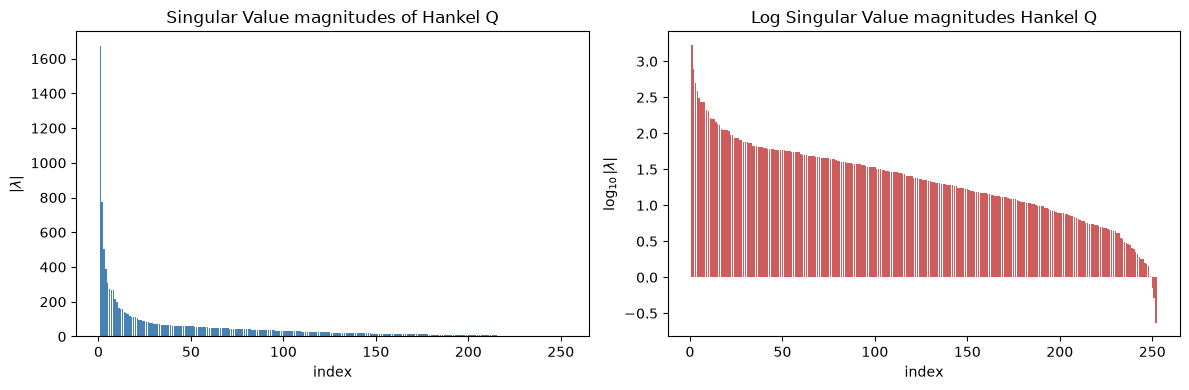

eff_rank: 11, stable_rank: 1.67, spikiness: 3.88, shape: (252, 252), non-zero rows :252, non-zero cols:252
top-r leverage spread: row min=6.426e-05 max=0.0112 (uniform 0.003968) | col min=6.426e-05 max=0.0112 (uniform 0.003968)
coherence score: row=2.823 col=2.823
****************************Hankel V****************************


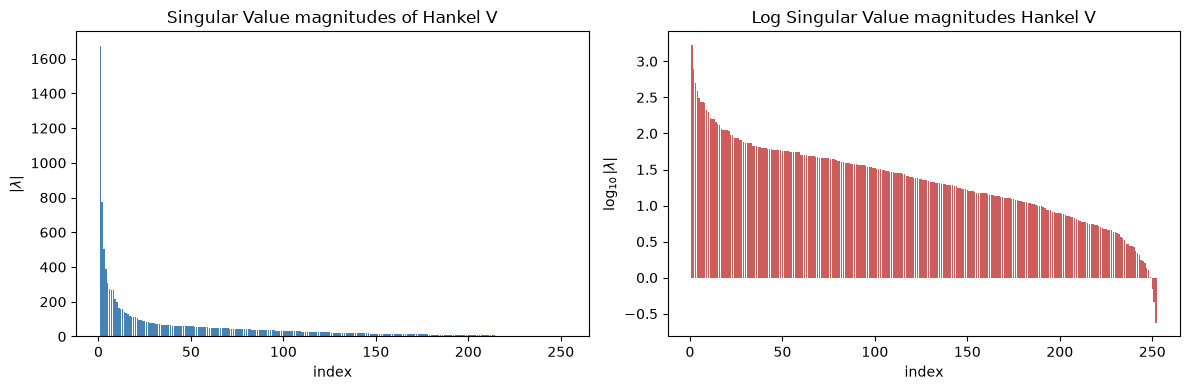

 25%|██▍       | 3701/15000 [43:48<6:01:09,  1.92s/it]

eff_rank: 11, stable_rank: 1.67, spikiness: 3.88, shape: (252, 252), non-zero rows :252, non-zero cols:252
top-r leverage spread: row min=6.432e-05 max=0.01121 (uniform 0.003968) | col min=6.432e-05 max=0.01121 (uniform 0.003968)
coherence score: row=2.824 col=2.824


 25%|██▍       | 3711/15000 [43:58<3:20:13,  1.06s/it]

episode 3710 avg_rewarg: 732.0


 25%|██▍       | 3721/15000 [44:09<3:02:21,  1.03it/s]

...

episode 3780 avg_rewarg: 941.0


 25%|██▌       | 3791/15000 [45:20<2:57:04,  1.05it/s]

episode 3790 avg_rewarg: 650.0


 25%|██▌       | 3800/15000 [45:29<2:39:35,  1.17it/s]

episode 3800 avg_rewarg: 903.0
****************************Hankel Q****************************


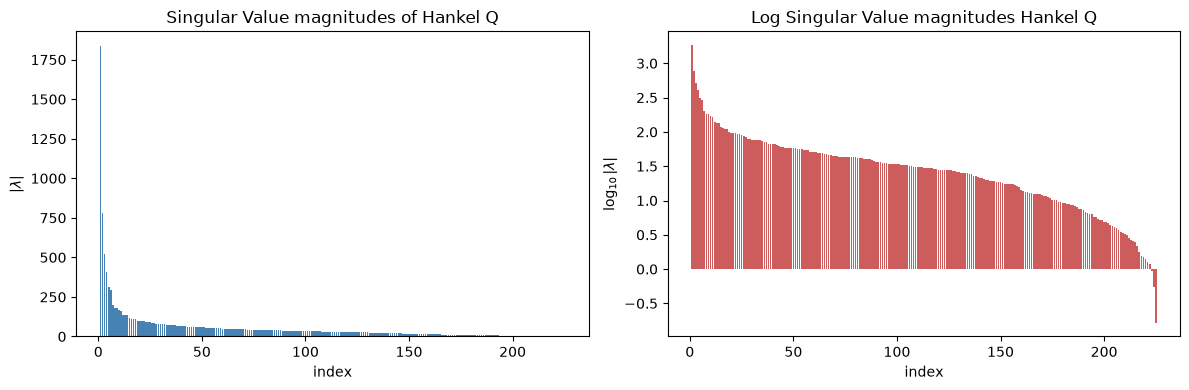

eff_rank: 9, stable_rank: 1.54, spikiness: 3.12, shape: (225, 225), non-zero rows :225, non-zero cols:225
top-r leverage spread: row min=0.000632 max=0.01033 (uniform 0.004444) | col min=0.000632 max=0.01033 (uniform 0.004444)
coherence score: row=2.325 col=2.325
****************************Hankel V****************************


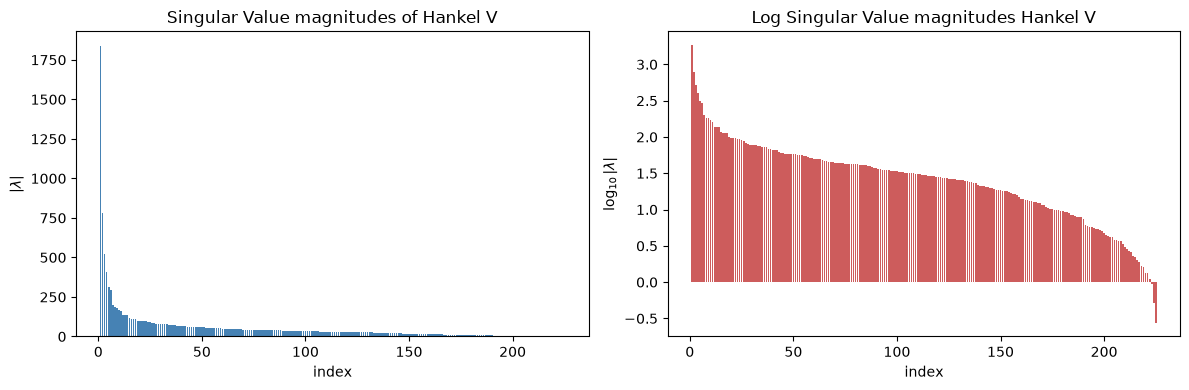

 25%|██▌       | 3801/15000 [45:32<4:54:24,  1.58s/it]

eff_rank: 9, stable_rank: 1.54, spikiness: 3.12, shape: (225, 225), non-zero rows :225, non-zero cols:225
top-r leverage spread: row min=0.000635 max=0.0103 (uniform 0.004444) | col min=0.000635 max=0.0103 (uniform 0.004444)
coherence score: row=2.317 col=2.317


 25%|██▌       | 3811/15000 [45:42<3:18:21,  1.06s/it]

episode 3810 avg_rewarg: 730.0


 25%|██▌       | 3821/15000 [45:52<2:48:09,  1.11it/s]

...

episode 3880 avg_rewarg: 937.0


 26%|██▌       | 3891/15000 [47:17<3:05:33,  1.00s/it]

episode 3890 avg_rewarg: 982.0


 26%|██▌       | 3900/15000 [47:28<3:36:16,  1.17s/it]

episode 3900 avg_rewarg: 915.0
****************************Hankel Q****************************


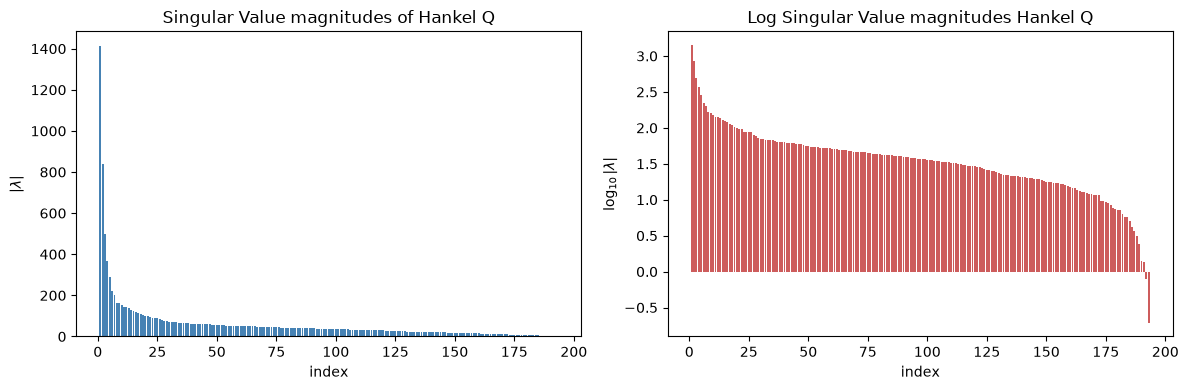

eff_rank: 14, stable_rank: 1.89, spikiness: 4.29, shape: (193, 193), non-zero rows :193, non-zero cols:193
top-r leverage spread: row min=0.0009008 max=0.014 (uniform 0.005181) | col min=0.0009008 max=0.014 (uniform 0.005181)
coherence score: row=2.702 col=2.702
****************************Hankel V****************************


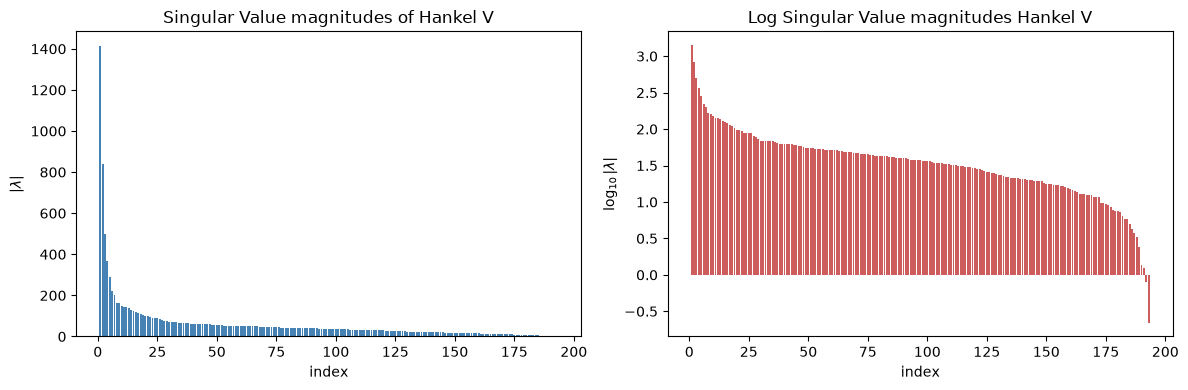

 26%|██▌       | 3901/15000 [47:33<7:26:54,  2.42s/it]

eff_rank: 14, stable_rank: 1.89, spikiness: 4.29, shape: (193, 193), non-zero rows :193, non-zero cols:193
top-r leverage spread: row min=0.0008983 max=0.01399 (uniform 0.005181) | col min=0.0008983 max=0.01399 (uniform 0.005181)
coherence score: row=2.7 col=2.7


 26%|██▌       | 3911/15000 [47:46<3:51:45,  1.25s/it]

episode 3910 avg_rewarg: 882.0


 26%|██▌       | 3921/15000 [47:56<3:35:06,  1.16s/it]

...

episode 3980 avg_rewarg: 1045.0


 27%|██▋       | 3991/15000 [49:13<3:33:18,  1.16s/it]

episode 3990 avg_rewarg: 1066.0


 27%|██▋       | 4000/15000 [49:24<3:28:56,  1.14s/it]

episode 4000 avg_rewarg: 1005.0
****************************Hankel Q****************************


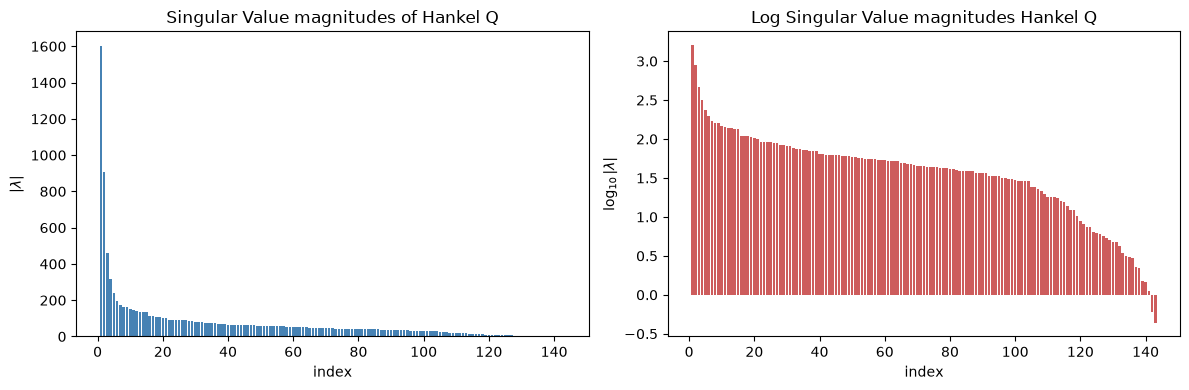

eff_rank: 10, stable_rank: 1.69, spikiness: 4.18, shape: (143, 143), non-zero rows :143, non-zero cols:143
top-r leverage spread: row min=0.001649 max=0.01752 (uniform 0.006993) | col min=0.001649 max=0.01752 (uniform 0.006993)
coherence score: row=2.506 col=2.506
****************************Hankel V****************************


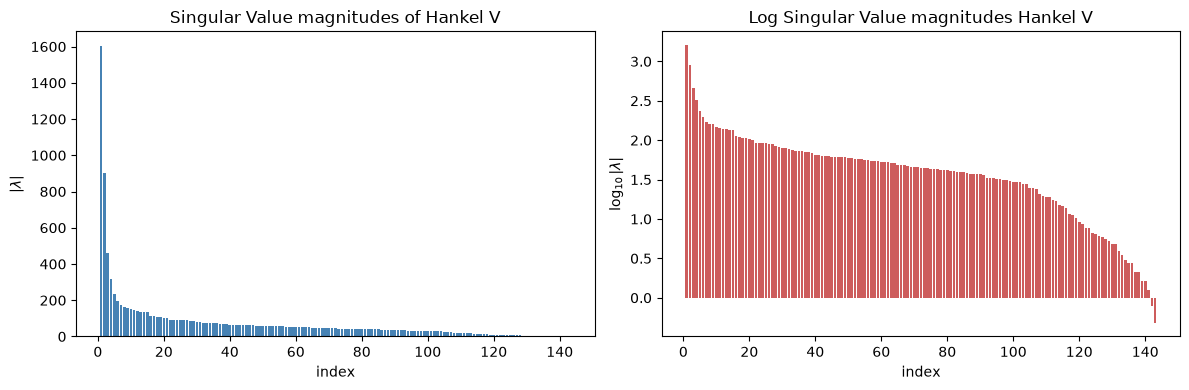

 27%|██▋       | 4001/15000 [49:27<5:29:21,  1.80s/it]

eff_rank: 10, stable_rank: 1.69, spikiness: 4.18, shape: (143, 143), non-zero rows :143, non-zero cols:143
top-r leverage spread: row min=0.001653 max=0.01744 (uniform 0.006993) | col min=0.001653 max=0.01744 (uniform 0.006993)
coherence score: row=2.494 col=2.494


 27%|██▋       | 4011/15000 [49:37<3:07:46,  1.03s/it]

episode 4010 avg_rewarg: 883.0


 27%|██▋       | 4021/15000 [49:48<2:47:57,  1.09it/s]

...

episode 4080 avg_rewarg: 1016.0


 27%|██▋       | 4091/15000 [51:09<4:12:48,  1.39s/it]

episode 4090 avg_rewarg: 1080.0


 27%|██▋       | 4100/15000 [51:22<4:01:57,  1.33s/it]

episode 4100 avg_rewarg: 1299.0
****************************Hankel Q****************************


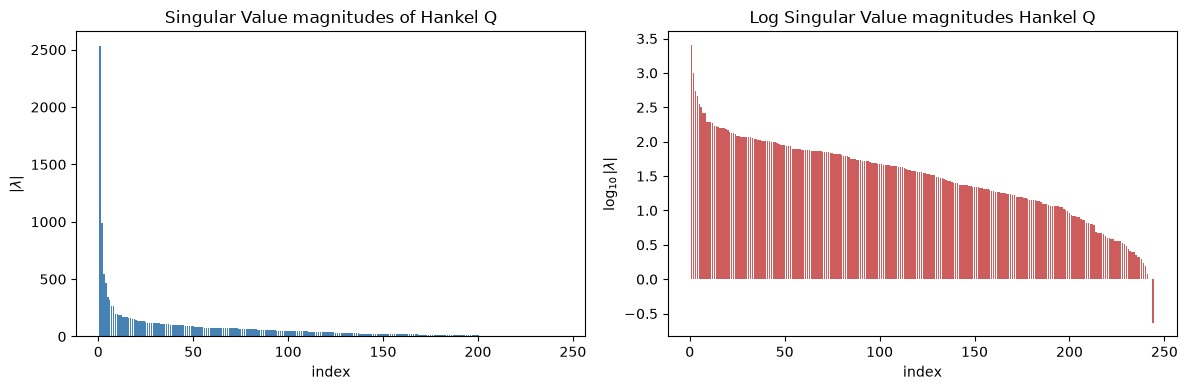

eff_rank: 11, stable_rank: 1.45, spikiness: 5.12, shape: (244, 244), non-zero rows :244, non-zero cols:244
top-r leverage spread: row min=0.0003025 max=0.01109 (uniform 0.004098) | col min=0.0003025 max=0.01109 (uniform 0.004098)
coherence score: row=2.706 col=2.706
****************************Hankel V****************************


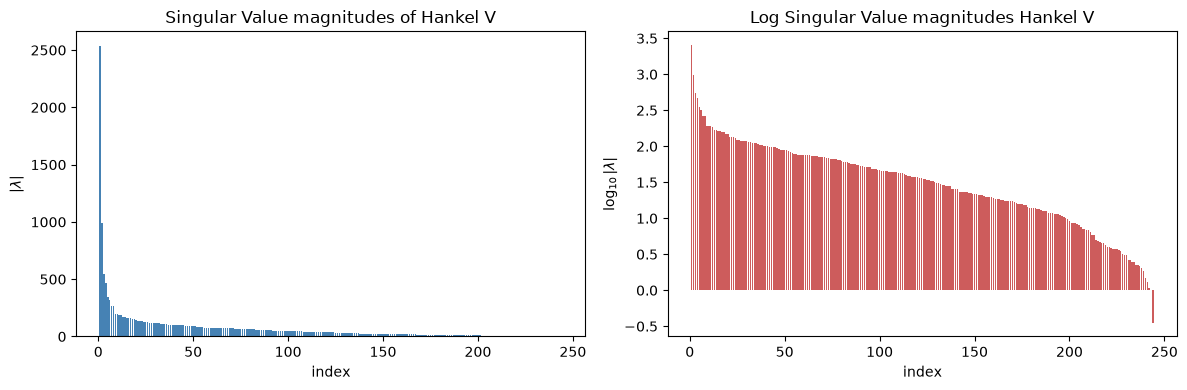

 27%|██▋       | 4101/15000 [51:26<6:31:59,  2.16s/it]

eff_rank: 11, stable_rank: 1.45, spikiness: 5.11, shape: (244, 244), non-zero rows :244, non-zero cols:244
top-r leverage spread: row min=0.0003023 max=0.01104 (uniform 0.004098) | col min=0.0003023 max=0.01104 (uniform 0.004098)
coherence score: row=2.693 col=2.693


 27%|██▋       | 4111/15000 [51:36<3:31:08,  1.16s/it]

episode 4110 avg_rewarg: 1065.0


 27%|██▋       | 4121/15000 [51:48<3:21:38,  1.11s/it]

...

episode 4180 avg_rewarg: 928.0


 28%|██▊       | 4191/15000 [53:10<3:04:13,  1.02s/it]

episode 4190 avg_rewarg: 1030.0


 28%|██▊       | 4200/15000 [53:22<4:06:20,  1.37s/it]

episode 4200 avg_rewarg: 1259.0
****************************Hankel Q****************************


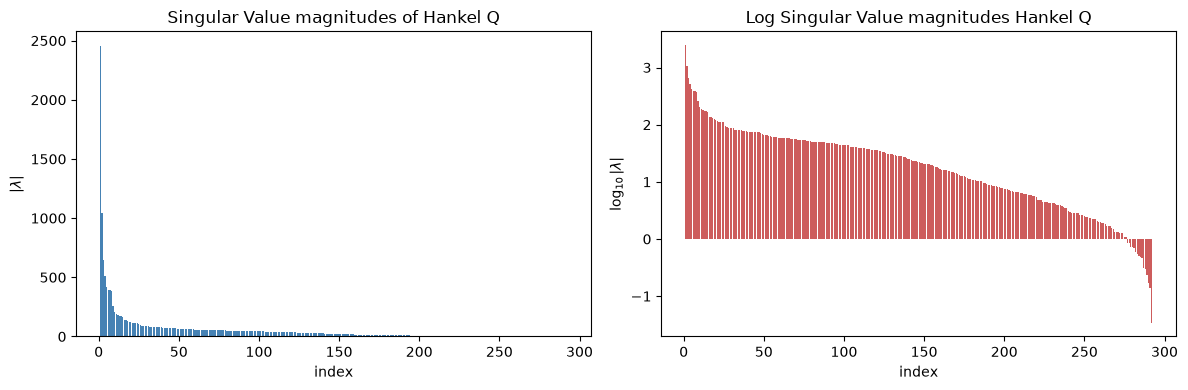

eff_rank: 8, stable_rank: 1.53, spikiness: 4.37, shape: (292, 292), non-zero rows :292, non-zero cols:292
top-r leverage spread: row min=6.38e-06 max=0.007908 (uniform 0.003425) | col min=6.38e-06 max=0.007908 (uniform 0.003425)
coherence score: row=2.309 col=2.309
****************************Hankel V****************************


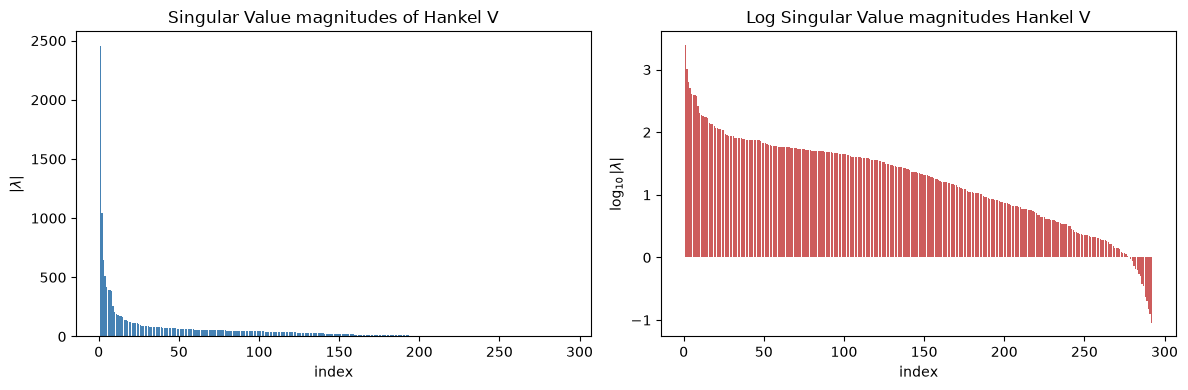

 28%|██▊       | 4201/15000 [53:28<8:24:33,  2.80s/it]

eff_rank: 8, stable_rank: 1.53, spikiness: 4.37, shape: (292, 292), non-zero rows :292, non-zero cols:292
top-r leverage spread: row min=6.543e-06 max=0.007906 (uniform 0.003425) | col min=6.543e-06 max=0.007906 (uniform 0.003425)
coherence score: row=2.309 col=2.309


 28%|██▊       | 4211/15000 [53:40<3:27:45,  1.16s/it]

episode 4210 avg_rewarg: 982.0


 28%|██▊       | 4221/15000 [53:51<2:50:51,  1.05it/s]

...

episode 4280 avg_rewarg: 1193.0


 29%|██▊       | 4291/15000 [55:08<2:39:14,  1.12it/s]

episode 4290 avg_rewarg: 871.0


 29%|██▊       | 4300/15000 [55:19<3:34:37,  1.20s/it]

episode 4300 avg_rewarg: 1030.0
****************************Hankel Q****************************


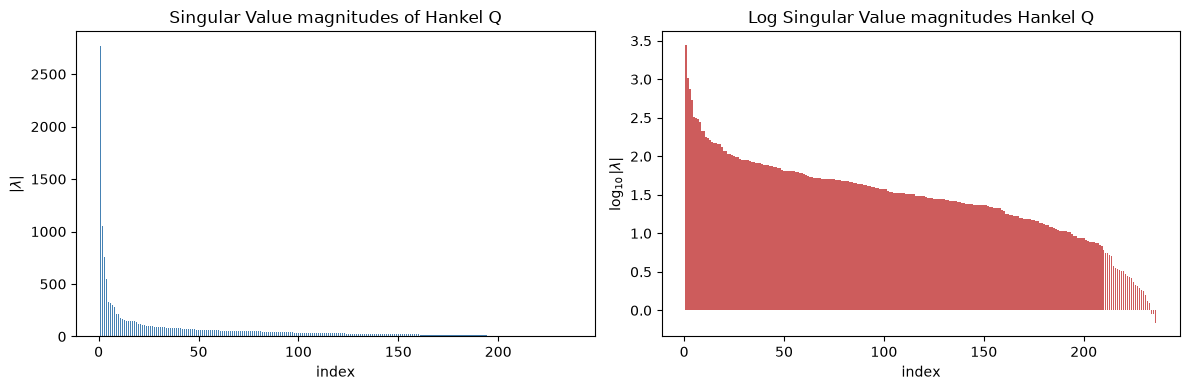

eff_rank: 5, stable_rank: 1.40, spikiness: 3.01, shape: (236, 236), non-zero rows :236, non-zero cols:236
top-r leverage spread: row min=0.0004482 max=0.01217 (uniform 0.004237) | col min=0.0004482 max=0.01217 (uniform 0.004237)
coherence score: row=2.873 col=2.873
****************************Hankel V****************************


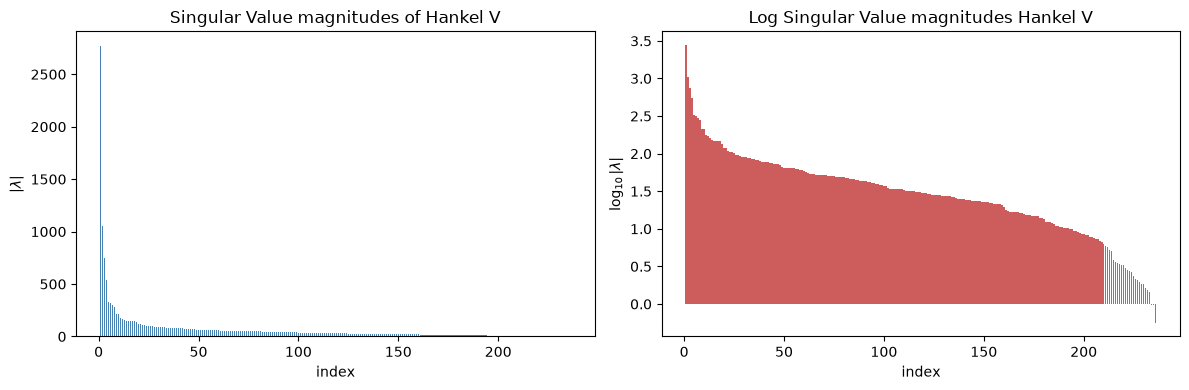

 29%|██▊       | 4301/15000 [55:22<5:30:30,  1.85s/it]

eff_rank: 5, stable_rank: 1.40, spikiness: 3.01, shape: (236, 236), non-zero rows :236, non-zero cols:236
top-r leverage spread: row min=0.0004493 max=0.01216 (uniform 0.004237) | col min=0.0004493 max=0.01216 (uniform 0.004237)
coherence score: row=2.87 col=2.87


 29%|██▊       | 4311/15000 [55:34<3:09:24,  1.06s/it]

episode 4310 avg_rewarg: 842.0


 29%|██▉       | 4321/15000 [55:45<2:41:52,  1.10it/s]

...

episode 4380 avg_rewarg: 1036.0


 29%|██▉       | 4391/15000 [57:04<3:27:15,  1.17s/it]

episode 4390 avg_rewarg: 1073.0


 29%|██▉       | 4400/15000 [57:15<3:46:51,  1.28s/it]

episode 4400 avg_rewarg: 1128.0
****************************Hankel Q****************************


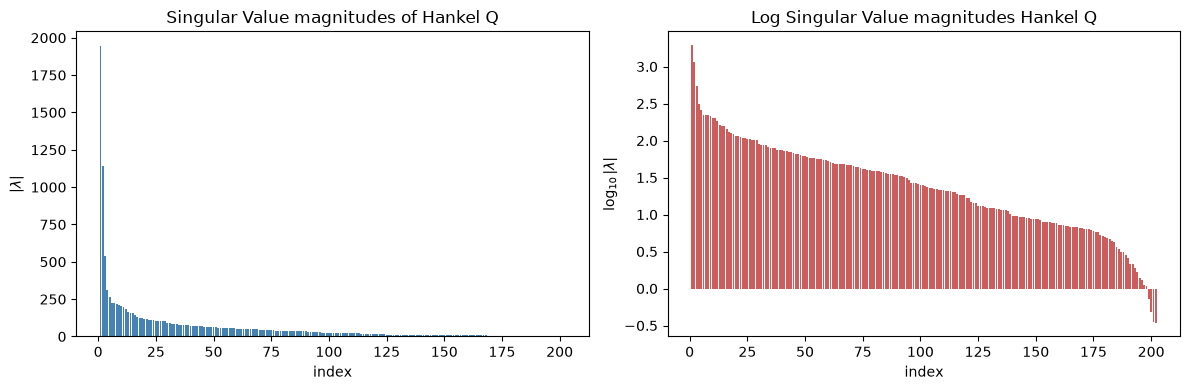

eff_rank: 9, stable_rank: 1.67, spikiness: 5.22, shape: (202, 202), non-zero rows :202, non-zero cols:202
top-r leverage spread: row min=9.579e-05 max=0.01547 (uniform 0.00495) | col min=9.579e-05 max=0.01547 (uniform 0.00495)
coherence score: row=3.125 col=3.125
****************************Hankel V****************************


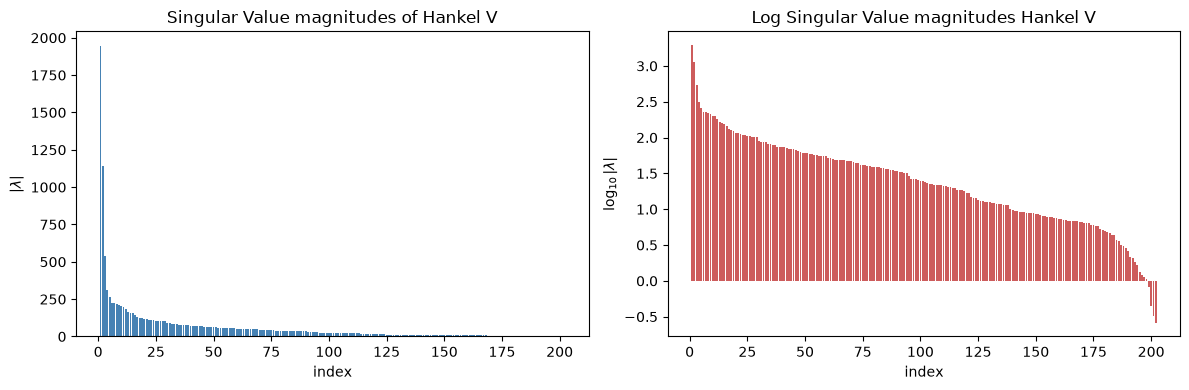

 29%|██▉       | 4401/15000 [57:18<5:32:50,  1.88s/it]

eff_rank: 9, stable_rank: 1.67, spikiness: 5.22, shape: (202, 202), non-zero rows :202, non-zero cols:202
top-r leverage spread: row min=9.574e-05 max=0.01547 (uniform 0.00495) | col min=9.574e-05 max=0.01547 (uniform 0.00495)
coherence score: row=3.124 col=3.124


 29%|██▉       | 4411/15000 [57:28<3:20:06,  1.13s/it]

episode 4410 avg_rewarg: 814.0


 29%|██▉       | 4421/15000 [57:42<4:13:41,  1.44s/it]

...

episode 4480 avg_rewarg: 773.0


 30%|██▉       | 4491/15000 [58:55<2:58:31,  1.02s/it]

episode 4490 avg_rewarg: 897.0


 30%|███       | 4500/15000 [59:04<3:23:51,  1.16s/it]

episode 4500 avg_rewarg: 905.0
****************************Hankel Q****************************


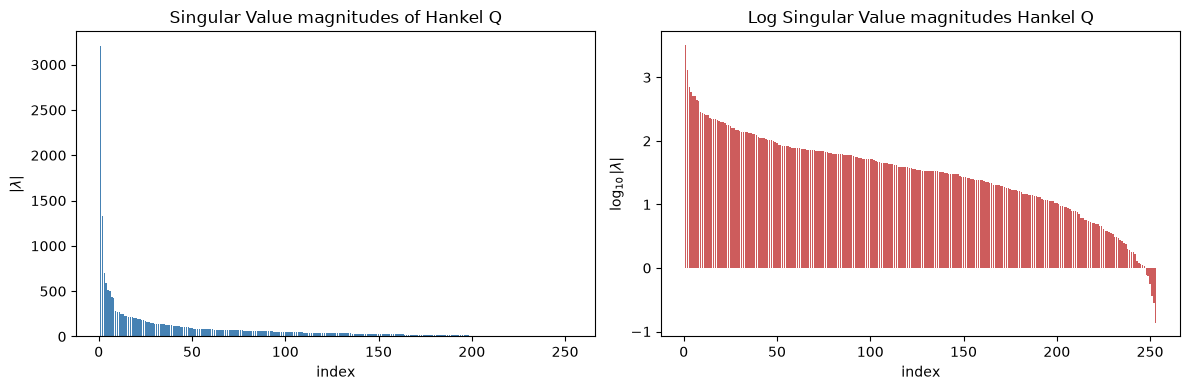

eff_rank: 9, stable_rank: 1.49, spikiness: 4.39, shape: (253, 253), non-zero rows :253, non-zero cols:253
top-r leverage spread: row min=0.0001464 max=0.012 (uniform 0.003953) | col min=0.0001464 max=0.012 (uniform 0.003953)
coherence score: row=3.037 col=3.037
****************************Hankel V****************************


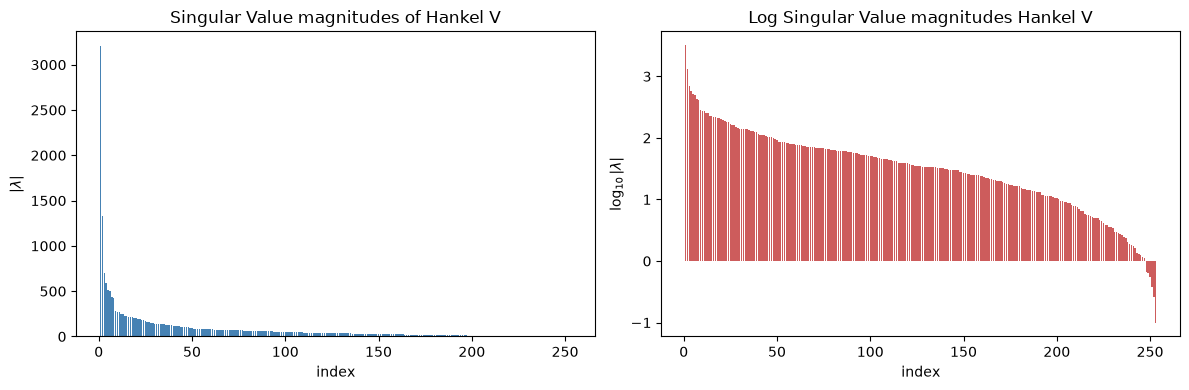

 30%|███       | 4501/15000 [59:10<7:27:25,  2.56s/it]

eff_rank: 9, stable_rank: 1.49, spikiness: 4.39, shape: (253, 253), non-zero rows :253, non-zero cols:253
top-r leverage spread: row min=0.0001448 max=0.012 (uniform 0.003953) | col min=0.0001448 max=0.012 (uniform 0.003953)
coherence score: row=3.036 col=3.036


 30%|███       | 4511/15000 [59:21<3:20:00,  1.14s/it]

episode 4510 avg_rewarg: 895.0


 30%|███       | 4521/15000 [59:32<2:49:34,  1.03it/s]

...

episode 4580 avg_rewarg: 845.0


 31%|███       | 4591/15000 [1:00:48<4:16:31,  1.48s/it]

episode 4590 avg_rewarg: 973.0


 31%|███       | 4600/15000 [1:00:58<3:25:18,  1.18s/it]

episode 4600 avg_rewarg: 1221.0
****************************Hankel Q****************************


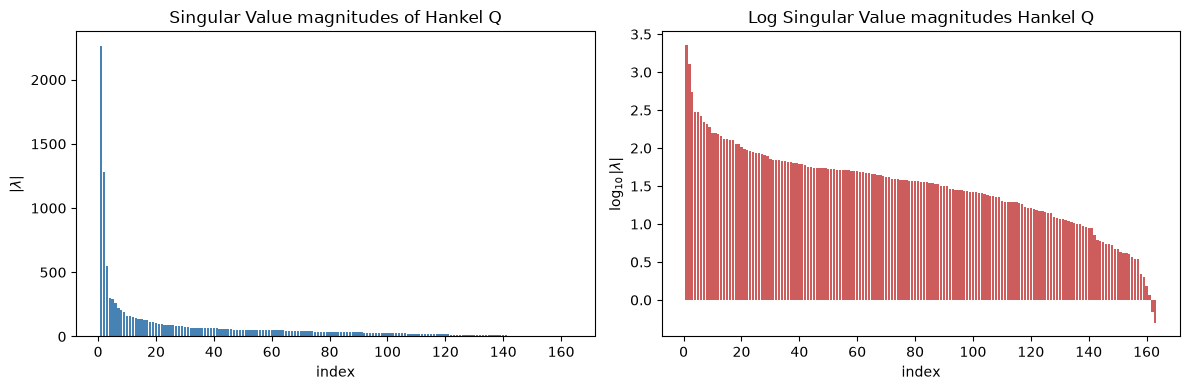

eff_rank: 4, stable_rank: 1.54, spikiness: 3.20, shape: (163, 163), non-zero rows :163, non-zero cols:163
top-r leverage spread: row min=0.000441 max=0.01865 (uniform 0.006135) | col min=0.000441 max=0.01865 (uniform 0.006135)
coherence score: row=3.04 col=3.04
****************************Hankel V****************************


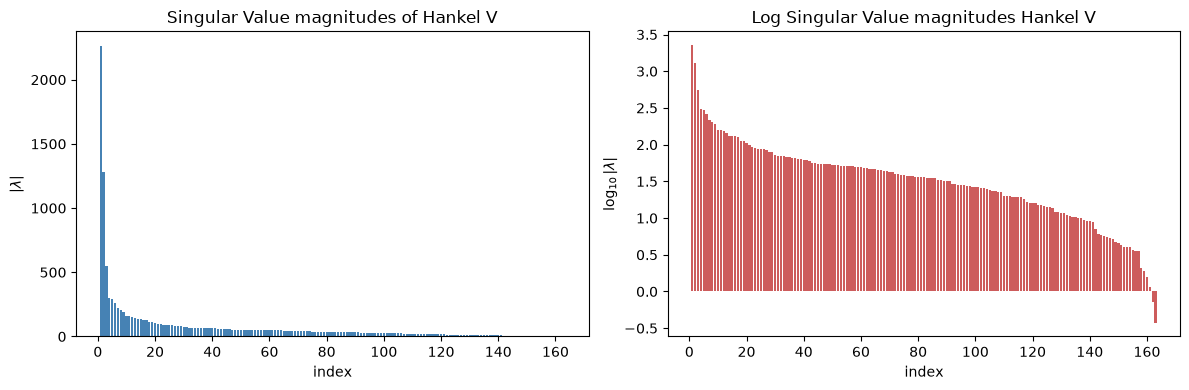

 31%|███       | 4601/15000 [1:01:01<5:18:46,  1.84s/it]

eff_rank: 4, stable_rank: 1.54, spikiness: 3.20, shape: (163, 163), non-zero rows :163, non-zero cols:163
top-r leverage spread: row min=0.0004422 max=0.01865 (uniform 0.006135) | col min=0.0004422 max=0.01865 (uniform 0.006135)
coherence score: row=3.04 col=3.04


 31%|███       | 4611/15000 [1:01:12<3:18:35,  1.15s/it]

episode 4610 avg_rewarg: 957.0


 31%|███       | 4621/15000 [1:01:23<3:12:44,  1.11s/it]

...

episode 4680 avg_rewarg: 1155.0


 31%|███▏      | 4691/15000 [1:02:42<3:57:20,  1.38s/it]

episode 4690 avg_rewarg: 1076.0


 31%|███▏      | 4700/15000 [1:02:50<2:54:30,  1.02s/it]

episode 4700 avg_rewarg: 849.0
****************************Hankel Q****************************


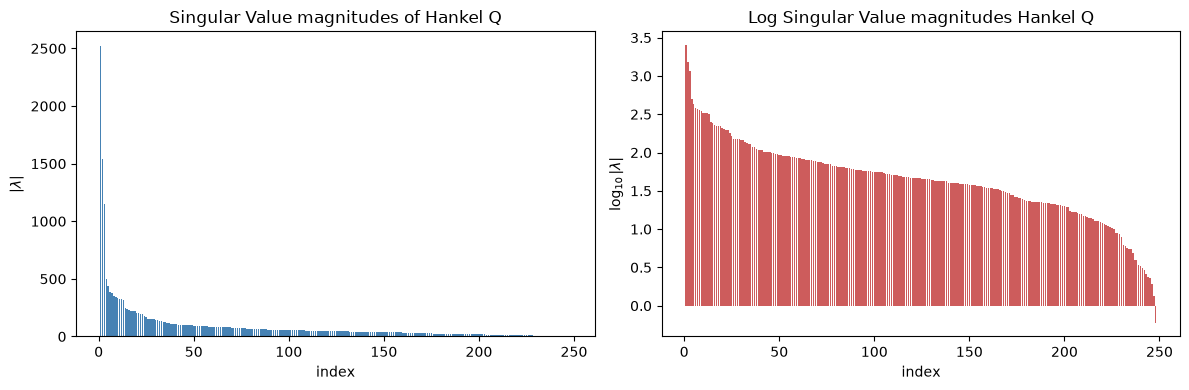

eff_rank: 14, stable_rank: 2.01, spikiness: 4.63, shape: (248, 248), non-zero rows :248, non-zero cols:248
top-r leverage spread: row min=0.002101 max=0.006563 (uniform 0.004032) | col min=0.002101 max=0.006563 (uniform 0.004032)
coherence score: row=1.628 col=1.628
****************************Hankel V****************************


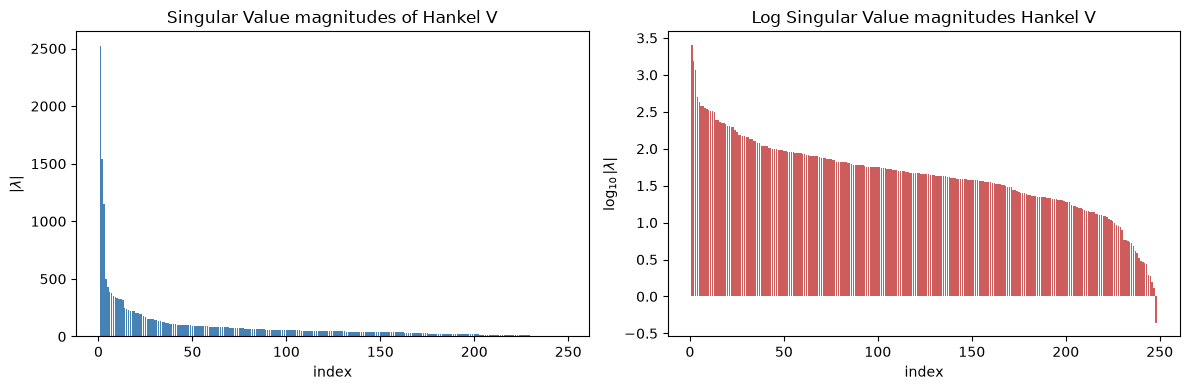

 31%|███▏      | 4701/15000 [1:02:54<4:40:51,  1.64s/it]

eff_rank: 14, stable_rank: 2.01, spikiness: 4.63, shape: (248, 248), non-zero rows :248, non-zero cols:248
top-r leverage spread: row min=0.002095 max=0.006548 (uniform 0.004032) | col min=0.002095 max=0.006548 (uniform 0.004032)
coherence score: row=1.624 col=1.624


 31%|███▏      | 4711/15000 [1:03:04<2:21:27,  1.21it/s]

episode 4710 avg_rewarg: 805.0


 31%|███▏      | 4721/15000 [1:03:15<3:39:57,  1.28s/it]

...

episode 4780 avg_rewarg: 895.0


 32%|███▏      | 4791/15000 [1:04:29<2:31:47,  1.12it/s]

episode 4790 avg_rewarg: 770.0


 32%|███▏      | 4800/15000 [1:04:38<2:58:40,  1.05s/it]

episode 4800 avg_rewarg: 781.0
****************************Hankel Q****************************


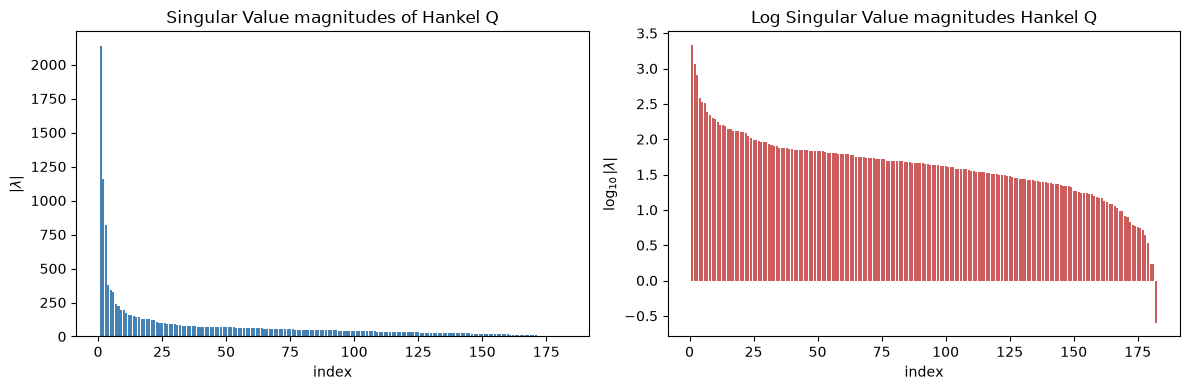

eff_rank: 7, stable_rank: 1.70, spikiness: 3.07, shape: (182, 182), non-zero rows :182, non-zero cols:182
top-r leverage spread: row min=0.001382 max=0.01682 (uniform 0.005495) | col min=0.001382 max=0.01682 (uniform 0.005495)
coherence score: row=3.062 col=3.062
****************************Hankel V****************************


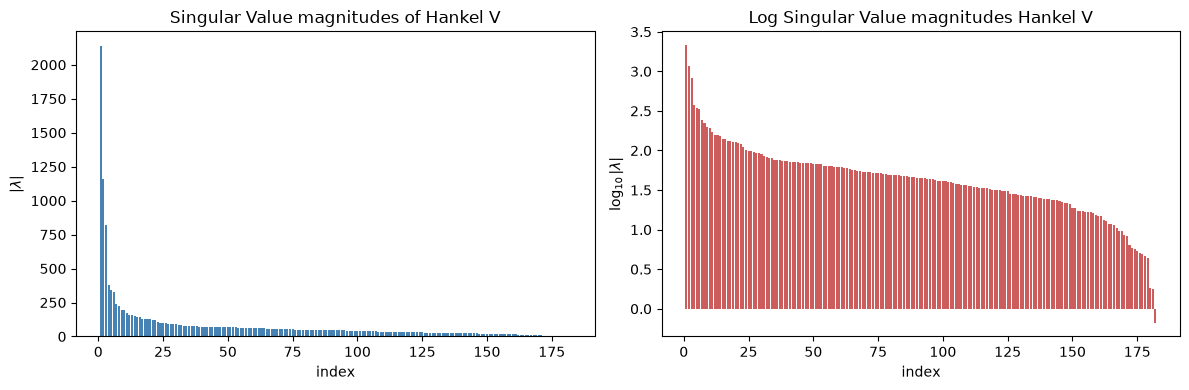

 32%|███▏      | 4801/15000 [1:04:44<6:37:12,  2.34s/it]

eff_rank: 7, stable_rank: 1.70, spikiness: 3.07, shape: (182, 182), non-zero rows :182, non-zero cols:182
top-r leverage spread: row min=0.001376 max=0.01683 (uniform 0.005495) | col min=0.001376 max=0.01683 (uniform 0.005495)
coherence score: row=3.063 col=3.063


 32%|███▏      | 4811/15000 [1:04:53<2:31:12,  1.12it/s]

episode 4810 avg_rewarg: 817.0


 32%|███▏      | 4821/15000 [1:05:04<3:11:37,  1.13s/it]

...

episode 4880 avg_rewarg: 1013.0


 33%|███▎      | 4891/15000 [1:06:21<3:25:55,  1.22s/it]

episode 4890 avg_rewarg: 1180.0


 33%|███▎      | 4900/15000 [1:06:31<2:52:25,  1.02s/it]

episode 4900 avg_rewarg: 1122.0
****************************Hankel Q****************************


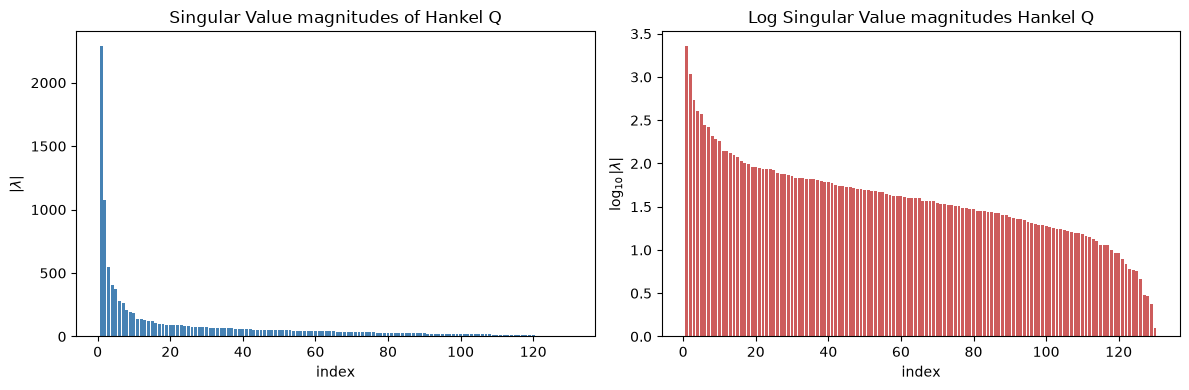

eff_rank: 4, stable_rank: 1.45, spikiness: 2.10, shape: (130, 130), non-zero rows :130, non-zero cols:130
top-r leverage spread: row min=0.003252 max=0.01555 (uniform 0.007692) | col min=0.003252 max=0.01555 (uniform 0.007692)
coherence score: row=2.021 col=2.021
****************************Hankel V****************************


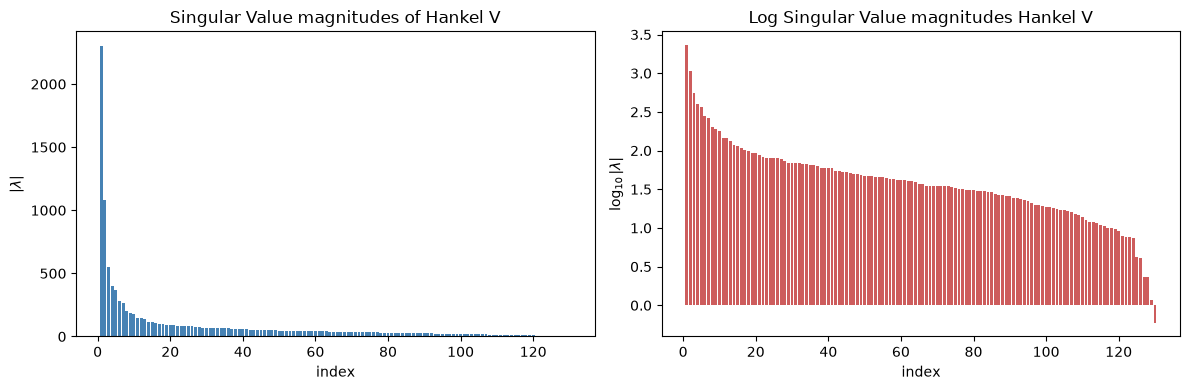

 33%|███▎      | 4901/15000 [1:06:34<4:06:56,  1.47s/it]

eff_rank: 4, stable_rank: 1.44, spikiness: 2.09, shape: (130, 130), non-zero rows :130, non-zero cols:130
top-r leverage spread: row min=0.003314 max=0.01556 (uniform 0.007692) | col min=0.003314 max=0.01556 (uniform 0.007692)
coherence score: row=2.023 col=2.023


 33%|███▎      | 4911/15000 [1:06:47<3:01:32,  1.08s/it]

episode 4910 avg_rewarg: 1150.0


 33%|███▎      | 4921/15000 [1:06:59<3:42:51,  1.33s/it]

...

 33%|███▎      | 4951/15000 [1:07:31<3:07:43,  1.12s/it]

episode 4950 avg_rewarg: 897.0


 33%|███▎      | 4959/15000 [1:07:39<3:01:31,  1.08s/it]

: 

: 

In [7]:
t = cfg["training"]
rewards = dqn_training_loop(
    agent, env,
    no_episodes=t["no_episodes"],
    target_network_update_steps=t["target_network_update_steps"],
    train_frequency_steps=t["train_frequency_steps"],
    use_episode_training=t["use_episode_training"],
    solved_reward=t["solved_reward"],
    warmup_steps=t["warmup_steps"],
    early_stopping_patience_eps=t["early_stopping_patience_eps"],
    no_eps_to_avg=t["no_eps_to_avg"],
    np_seed=seed,
    analysis_config=analysis,
    DEBUG=False, atari=True
)

## Training and Analysis Plots

In [ ]:
rewards = np.asarray(rewards, dtype=float)
plt.figure(figsize=(8, 4))
plt.plot(rewards, alpha=0.35, label="episode reward")
if len(rewards) >= 10:
    k = 10
    ma = np.convolve(rewards, np.ones(k) / k, mode="valid")
    plt.plot(range(k - 1, len(rewards)), ma, label=f"{k}-ep moving avg")
plt.xlabel("episode"); plt.ylabel("total reward"); plt.title("DQN on ALE/MsPacman-v5")
plt.legend(); plt.show()

In [ ]:
for method, names in analysis["methods"]:
    results = method(agent=agent, env=env)
    if not isinstance(results, tuple):
        results = (results,)
    for matrix, name in zip(results, names):
        print(name)
        plot_matrix_heatmap(matrix, name)
        r, sr, spk, shape, irs, ics, rc, cc, nzr, nzc = row_rank_property_check(matrix, name)
        print(f"eff_rank: {r}, stable_rank: {sr:.2f}, spikiness: {spk:.2f}, shape: {shape}, non-zero rows :{nzr}, non-zero cols:{nzc}")
        print(f"top-r leverage spread: row min={irs.min():.4g} max={irs.max():.4g} (uniform {1.0/shape[0]:.4g}) | col min={ics.min():.4g} max={ics.max():.4g} (uniform {1.0/shape[1]:.4g})")
        print(f"coherence score: row={rc:.4g} col={cc:.4g}")

## Greedy rollout video

Record one greedy (`act_greedy`) episode of the trained agent and display it inline.

In [ ]:
from analysis.visualisations.rollout_video import record_greedy_episode
from IPython.display import Video
import glob

video_dir = "videos"
eval_env = make_environment(
    env_cfg["name"],
    render_mode="rgb_array",
    discrete_config=env_cfg["discrete_config"],
    normalise=env_cfg["normalise"],
    clip=env_cfg["clip"],
    atari=env_cfg["atari"],
)
prefix = record_greedy_episode(agent, eval_env, video_dir, episode=0, seed=seed)
mp4 = sorted(glob.glob(f"{video_dir}/{prefix}-*.mp4"))[-1]
print("saved:", mp4)
Video(mp4, embed=True)